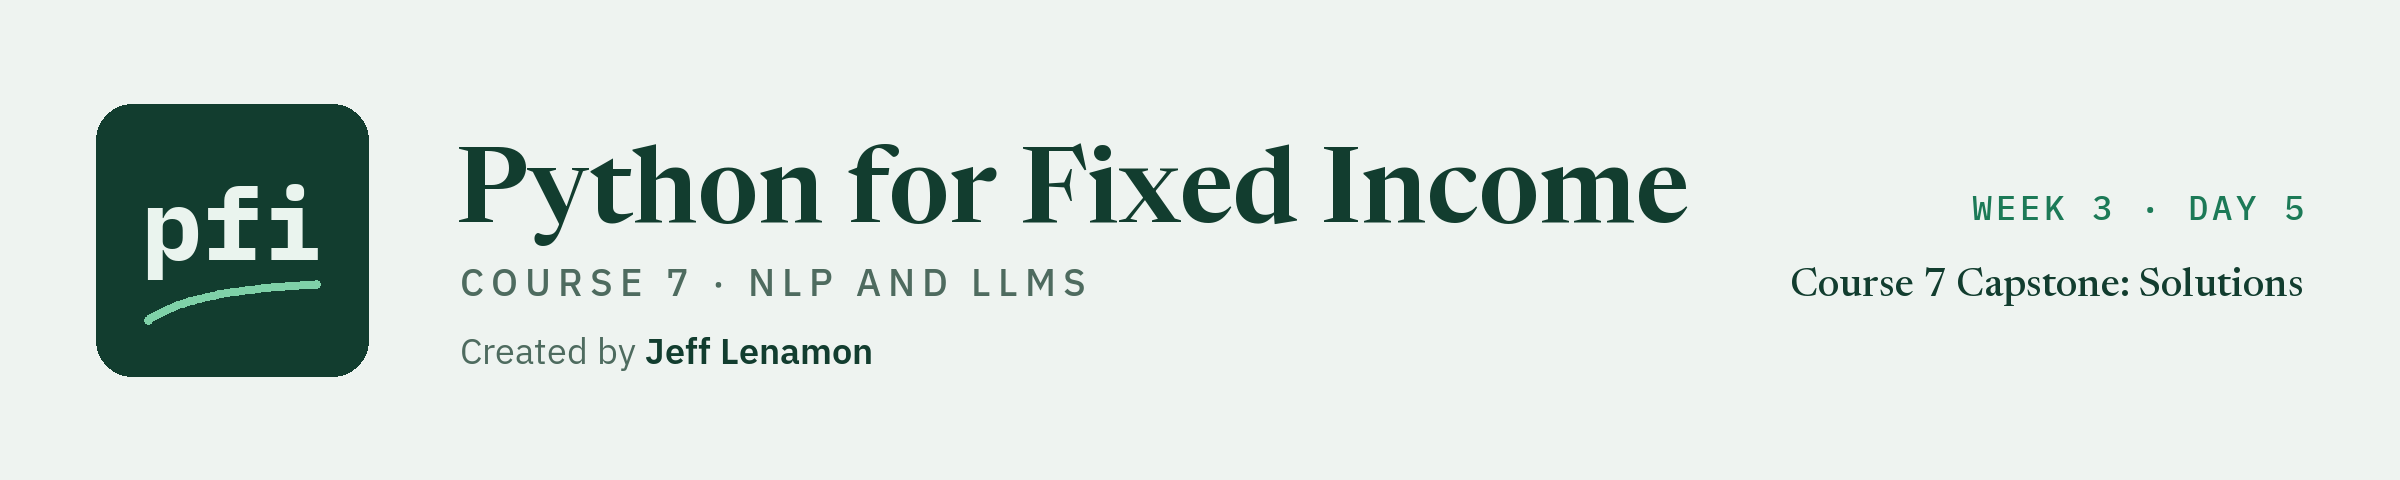

# Course 7 Capstone: Solutions

Week 3, Day 5. The worked version of the capstone: every question answered with code, its output, and what the output shows. Write your own answers and your own description first.

**Data:** `course7_indentures/lamar_2007.txt`: Lamar Media Corp., Indenture dated as of October 11, 2007, 6-5/8% Senior Subordinated Notes due 2015, Series C, Exhibit 4.1 to the 8-K filed 2007-10-16, accession 0000950134-07-021393: **real**, a public record on sec.gov, quoted for descriptive extraction only.

**Data:** `course7_indentures/boyd_2021.txt`: Boyd Gaming Corporation, Indenture dated as of June 8, 2021, 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495: **real**, a public record on sec.gov, quoted for descriptive extraction only.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course7_nlp_and_llms/week3/day5/course7_capstone_solutions.ipynb)

## The Brief

### The scenario

A colleague on the desk: **"We get indentures as HTML from EDGAR and as PDFs from everywhere else. Build me a tool that takes one in and gives back the covenant terms in a table I can check: every number with the section and the sentence it came from, and a flag on anything the checks could not confirm. Run it on an indenture you have not seen."**

Fourteen days built the pieces: `textkit.py`, from `normalize_text` and `find_sections` on day 1 to `html_to_text` (day 9), `ask` and the key cell (day 11), the schema, `definitions_dict`, `terms_used`, `parse_json`, and `check_extraction` (day 12), `basket_amounts` (day 13), and the habit of checking an answer against a key decided before any request (day 14). Today you put them together in a module of your own, `covenant_tool.py`, and run it on the Lamar Media Corp. indenture of 2007, which the course has never opened, then on the Boyd indenture of days 12 to 14, whose checked table day 12 already made.

The output describes what two public documents say. It is not a credit view on either issuer or its notes, and the tool refuses to give one.

**The rules for real documents, as on every day of this course.**

* **The documents are real.** Both indentures are public records on sec.gov, filed by their issuers. A source line sits under every excerpt, with the section and the cut stated.
* **Every prompt asks what the document says.** Each request asks for the terms of one section as JSON, with a quote beside every number, or "NOT IN TEXT". The system prompt that goes first in every request refuses anything else. Two cells, marked adversarial, ask for a ranking on purpose, to show what comes back.
* **An extracted value is what a response returned.** It is "the extracted value", with "its quote"; a value whose checks pass is "confirmed". Every number about a response is read from the saved file, and every number about an indenture from the text, through `textkit`.
* **The issuers' names appear only as the authors of the documents being read**: in the data lines and the source lines. No sentence in this notebook compares the two documents' terms in quality.

### What makes it hard

Nothing is planted. The new indenture is a real filing of another year, another issuer, and another kind of note, and the tool meets it with a prompt chosen on another document. A tool that assumed day 12's shape fails here, visibly, and finding where is the work. Watch for: something before the table of contents that is not a section; housekeeping sections at the start of Article 4; a debt test that is not day 12's ratio and is not written in day 12's forms; a covenant that the schema has no kind for; baskets sized against a measure day 12 never saw; and a covenant kind that may not be in the text at all. Each one has a check in the questions, and each one asks you to decide what the tool reports.

### What to hand in

This notebook, completed and run from top to bottom, with thirteen deliverables:

| # | Deliverable | Where |
| --- | --- | --- |
| 1 | `textkit.py` complete, and `pytest -q` passing with its output saved | Section 1 |
| 2 | `load_indenture(path)` in `covenant_tool.py`: the text, the sections, the definitions, with hashed checks on the counts | Section 2 |
| 3 | The indenture described in hashed checks: words, Article 4, defined terms, the terms Section 4.10 uses at depth 2 | Section 3 |
| 4 | `extract_covenant(...)`: one request per covenant kind, the section and its definitions at depth 2, the schema, `parse_json`; an absent kind reported, never guessed | Sections 4 and 5 |
| 5 | `check_table(package, text, sections)`: `check_extraction` plus the `basket_amounts` cross-check, and a status for every value | Section 6 |
| 6 | `run_tool(path, client, mode)`: an indenture in, a checked table out; run on Boyd too, with day 12's table as the reference | Section 7 |
| 7 | The checked table for Lamar, with its counts, and every value not confirmed beside its quote and its source sentence | Section 8 |
| 8 | The guardrail: an adversarial request returns REFUSED, asserted; `assert_extraction_only` on every prompt the tool sends | Section 9 |
| 9 | Cost and requests: the number of requests, the tokens, and the cost on the free model and at the paid fallback's list price | Section 10 |
| 10 | A workbook, `course7_capstone_covenants.xlsx`, with the checks written as Excel formulas, read back and checked | Section 11 |
| 11 | A written description, "What the tool shows, and where it fails", that passes `assert_extraction_only` | Section 12 |
| 12 | One Git commit for each deliverable that writes a file, then the tag `course7` | Every section, then Save the Day with Git |
| 13 | An AI-use log | Section 12 |

### How long

The course map gives the capstone one day. It is more work than one sitting. Plan on two or three.

| Sitting | Sections |
| --- | --- |
| First | 1 the module, 2 loading an indenture, 3 the indenture described, 4 Article 4 mapped |
| Second | 5 one covenant extracted, 6 the checked table, 7 the whole tool, 8 the Lamar table |
| Third | 9 the guardrail, 10 cost, 11 the workbook, 12 the description and the log, then Git and Bring It Home |

In replay mode the notebook runs in well under a minute on the course's build machine: no request goes out, and most of the time is reading two HTML files and running the tests.

### The rules

1. **Describe, never judge.** Every prompt asks what the document says; every sentence you write says what the table shows. `textkit.assert_extraction_only` checks your prompts and your description; it is a reminder, not a proof.
2. **The prompt is chosen on Boyd, never on Lamar.** The instruction is days 12 and 13's, sentence for sentence. A prompt tuned on the document it is tested on would make the test meaningless. The checks may change when the new document shows them a form they did not know; the prompt does not.
3. **`textkit.py` is frozen.** The capstone adds nothing to it. Everything new goes in `covenant_tool.py`.
4. **Every number has a home.** A number about an indenture comes from `textkit` on the text; a number about a response comes from the saved response, and a sentence about it says so.
5. **Every excerpt carries its source line,** with the section and the cut stated: never print a whole indenture or a whole section of more than a paragraph.
6. **The key stays in the key cell.** No other cell prints anything about it, and no key goes into a prompt, a file, or a commit.
7. **Git only in the work folder.** Every Git command is written `!git -C "{work}" ...`.
8. **The notebook runs from top to bottom** with Restart and Run All before you hand it in.

### What help is allowed

Every earlier notebook of Course 7 and your notes; the documentation of pandas, pydantic, the `openai` package, BeautifulSoup, and openpyxl; and an AI assistant, used the way the course taught: the docstring is the prompt, read the code that comes back, test it before you trust it, and keep a log as you go (question 12.2). No indenture text from your work, and nothing from an employer, goes into an AI tool or into Colab.

### How to check your work

Most questions ask you to store an answer in a variable such as `answer_2_1`. The cell after it runs `check()`, which prints `correct`, `not yet` with what you have, or `not attempted yet`. The right answers are not written anywhere in this notebook: each check holds a short code made from the right answer, and `check()` makes a code from yours in the same way and compares the two. A whole number can be given as `7` or `7.0`. A decimal is rounded to the places the question states before it is compared, so store the full number and let `check()` round it. Text is compared without capitals and spaces at the ends. Several values go in a tuple, in the order the question asks.

The checks about a response assume the course's saved responses: in replay mode you get the same responses, and with your own key the text can differ, and so can those checks. Your decisions change the numbers that follow, so the checks after a decision assume the decision the course made. Under some questions a closed block that starts "Stuck after trying?" holds the decision the capstone expects for one kind of choice: not a count and not an answer. Leave it closed until you have made your own.

Worked answers are in `course7_capstone_solutions.ipynb` in this folder. Open it after you have written your own description.

## The Data

**The new indenture** is Lamar Media Corp.'s indenture of October 11, 2007, for its 6-5/8% Senior Subordinated Notes due 2015, Series C, with The Bank of New York Trust Company, N.A., as trustee: Exhibit 4.1 to the 8-K filed 2007-10-16, as filed on EDGAR (the data line at the top). The course has never opened it. The tool reads the HTML as filed, through day 9's `html_to_text`; the course's `.txt` copy of the same text is not used.

**The second run** is the Boyd Gaming Corporation indenture of days 12 to 14, again from the HTML as filed. Day 12 checked five of its covenants by hand, one prompt change at a time; its table is the reference the tool's Boyd run is set beside.

**What the tool does not read.** Schedules, exhibits other than the indenture itself, supplemental indentures, amendments, and the credit agreement an indenture refers to. A PDF needs day 13's text layer first; the tool reads HTML.

**Rows.** No model is fitted or scored in this capstone: every number about an indenture describes the document as filed, and every number about a response describes a **saved response**, the text a model returned to a request the course sent, stored in `data/course7_llm_responses/day15/` and replayed here. With your own key a run sends the requests again, and its text can differ.

## Setup

Run the setup cells first. They are complete: do not change them. The first sets the thread and quiet-loading settings, makes today's work folder, and copies the two indentures' HTML into it. The next cells write the complete `mlkit.py`, `marketdata.py`, `bondmath.py`, `textkit.py`, and `test_textkit.py` as day 14 left them. **If you kept your own `my_bondmath` up to date, paste your own files into those cells instead.** Then the modules are imported, the helpers are defined (`lamar_source()`, `boyd_source()`, `reload_tool()`, `show_table()`, `llm_lines()`, `answer_text()`, and `check()`), and the key cell and the route cell decide the mode.

Q. Set up the work folder and copy the two indentures into it.

In [1]:
# today's setup: thread settings, quiet model loading, the modules, the seed, the course data, a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, or PyTorch is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# the model libraries print download bars and notices; these lines must run before they are imported
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("torch", "torch"), ("transformers", "transformers"), ("sentence_transformers", "sentence-transformers"), ("openai", "openai"), ("pydantic", "pydantic"), ("bs4", "beautifulsoup4"), ("pypdf", "pypdf"), ("pypdfium2", "pypdfium2"), ("dotenv", "python-dotenv"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course7_nlp_and_llms/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "torch": "2.14.1", "transformers": "5.19.0", "sentence-transformers": "6.1.0", "openai": "3.26.0", "pydantic": "2.13.5", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name].split("+")[0] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "course7_fomc_statements.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course7_15_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["course7_indentures/lamar_2007.htm", "course7_indentures/boyd_2021.htm"]
for name in DATA_FILES:
    (work / name).parent.mkdir(parents=True, exist_ok=True)
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, torch 2.14.1, transformers 5.19.0, sentence-transformers 6.1.0, openai 3.26.0, pydantic 2.13.5, pytest 9.1.1
Work folder: pfi_course7_15_25enxlbx, in your temp folder
Data files from the data folder of the course repo: course7_indentures/lamar_2007.htm, course7_indentures/boyd_2021.htm
SEED = 42


Q. Write the earlier courses' modules today needs, unchanged: `mlkit.py`, `marketdata.py`, `bondmath.py`.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


In [3]:
%%writefile marketdata.py
"""marketdata: dated market series for fixed income, checked against Excel.

Written day by day in Python for Fixed Income, Course 3: Market Data and Time Series.

Conventions, the same in every function:
- A series has a DatetimeIndex named date: naive calendar dates (no time, no time zone), unique and ascending.
- Yields are in percent (5.29 means 5.29 percent), as Treasury and FRED publish them. Spreads are in basis points.
- Changes of yields and spreads are in basis points. Price changes are simple returns in percent.
- Windows are counted in observations (rows of the market calendar), trailing, and include the current row.
- A missing observation is NaN. It is dropped before any change or window is computed, never filled.
- A secret (an API key) is never printed, written to a file, or put in an error message.
"""
import os  # environment variables
from pathlib import Path  # file paths


def get_secret(name: str, env_file: str | Path) -> str:
    """Return a secret such as an API key, looked up in three places in a fixed order.

    Units: none; the secret is text. Convention: the first place that holds a non-empty value wins:
    1. the environment variable `name`;
    2. Colab's Secrets panel (google.colab.userdata), only when running in Colab;
    3. the .env file at `env_file`, read with dotenv.dotenv_values, which does not change os.environ.
    The value is returned and never printed. Raises RuntimeError naming the secret and the three places
    looked, never a value and never the full path of the file.
    """
    # 1. the environment: a variable set in PowerShell, or by the program that started Python
    value = os.environ.get(name)
    if value:
        return value

    # 2. Colab's Secrets panel: the import works only inside Colab
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None
    if userdata is not None:
        try:
            value = userdata.get(name)
        # a secret that is not there, or one the notebook has not been given access to
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
            value = None
        if value:
            return value

    # 3. the .env file, imported here so Colab never needs python-dotenv
    env_path = Path(env_file)
    if env_path.is_file():
        from dotenv import dotenv_values
        value = dotenv_values(env_path).get(name)
        if value:
            return value

    # nothing found: say where we looked, with the file's name only (a full path shows a user name)
    raise RuntimeError(
        f"Secret {name} not found. Looked in: the environment variable {name}, "
        f"Colab's Secrets panel, and the file {env_path.name} given as env_file."
    )


import pandas as pd  # dated series, from day 2
import requests  # HTTP, from day 2

# FRED's endpoint for the observations of one series
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"


def fred_params(series_id: str, api_key: str, start: str | None = None, end: str | None = None) -> dict:
    """The query parameters for one request to FRED's series/observations endpoint.

    Units: start and end are dates as text, YYYY-MM-DD. Convention: JSON is asked for (file_type json);
    a start or end left as None is not sent, so FRED returns the series from its first or to its last date.
    Pure: builds a dict and sends nothing. The dict holds the key, so it is never printed.
    """
    # the three parameters every request needs
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    # the optional date range
    if start is not None:
        params["observation_start"] = start
    if end is not None:
        params["observation_end"] = end
    return params


def parse_fred_observations(payload: dict, name: str) -> pd.Series:
    """Turn a FRED series/observations JSON answer into a float series.

    Units: as FRED publishes the series (percent for the Treasury and spread series).
    Convention: one value per observation, indexed by its date (a DatetimeIndex named date). FRED's
    missing marker "." becomes NaN and is kept: dropping it is a separate, visible step.
    Raises ValueError if the answer has no "observations" list.
    """
    # stop on an answer that is not a series/observations answer
    if "observations" not in payload:
        raise ValueError(f"the answer for {name} has no 'observations'; keys are {sorted(payload)}")
    observations = payload["observations"]
    # each date as a calendar date
    dates = pd.to_datetime([obs["date"] for obs in observations], format="%Y-%m-%d")
    # each value as a float; "." is FRED's mark for a day with no value, so it becomes NaN, never 0
    values = [float("nan") if obs["value"] == "." else float(obs["value"]) for obs in observations]
    series = pd.Series(values, index=dates, name=name, dtype="float64")
    series.index.name = "date"
    return series


def fred_series(series_id: str, api_key: str, start: str | None = None, end: str | None = None,
                timeout: float = 30) -> pd.Series:
    """Download one series from the FRED API: one GET with requests, then parse_fred_observations.

    Units: as FRED publishes the series. Convention: "." rows are kept as NaN, as parse_fred_observations.
    The only function in this module that uses the network.
    Errors never show the key or the URL (which holds the key):
    - it never calls response.raise_for_status(), whose message holds the full URL;
    - an answer other than HTTP 200 raises RuntimeError with the status and FRED's own error message;
    - a connection problem (requests.RequestException) raises RuntimeError naming only the exception class;
    - both are raised `from None`, so no chained traceback shows the original error and its URL.
    Raises RuntimeError if FRED answers with zero observations (FRED returns HTTP 200 with count 0 for a
    range the series does not cover).
    """
    # the request, sent once; the parameters (and the key) stay inside requests
    try:
        response = requests.get(FRED_URL, params=fred_params(series_id, api_key, start, end), timeout=timeout)
    except requests.RequestException as error:
        # the original message holds the URL with the key, so only the class name is kept
        raise RuntimeError(f"Request for {series_id} failed: {type(error).__name__}") from None

    # an answer other than 200: FRED puts its reason in "error_message"
    status = response.status_code
    if status != 200:
        try:
            error_message = response.json().get("error_message", "no error message")
        except ValueError:
            error_message = "the answer was not JSON"
        # FRED's messages do not echo the key; replace it anyway in case one ever does
        error_message = error_message.replace(api_key, "***")
        raise RuntimeError(f"FRED returned HTTP {status} for {series_id}: {error_message}") from None

    # parse, and stop on an empty answer
    series = parse_fred_observations(response.json(), series_id)
    if series.empty:
        raise RuntimeError(f"FRED returned no observations for {series_id} (start {start}, end {end})")
    return series


def _check_index(index: pd.Index, what: str) -> None:
    """Stop unless `index` is a DatetimeIndex with unique dates in ascending order.

    A helper for the functions below (the leading underscore marks it as not part of the module's API).
    """
    if not isinstance(index, pd.DatetimeIndex):
        raise ValueError(f"{what} must have a DatetimeIndex, not {type(index).__name__}")
    if not index.is_unique:
        raise ValueError(f"{what} has repeated dates, for example {index[index.duplicated()][0].date()}")
    if not index.is_monotonic_increasing:
        raise ValueError(f"{what} dates are not in ascending order")


def missing_weekdays(index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """The weekdays from the first date to the last that have no row.

    Units: dates. Convention: a weekday is Monday to Friday; no holiday calendar is used, so the result is
    every weekday the data skipped (holidays and any other closure). Weekends are never counted.
    Raises ValueError on an index that is not unique and ascending dates.
    """
    _check_index(index, "index")
    # every Monday to Friday in the span
    weekdays = pd.bdate_range(index[0], index[-1])
    # the ones with no row
    missing = weekdays.difference(index)
    missing.name = "date"
    return missing


def align(series: dict[str, pd.Series], how: str = "inner") -> pd.DataFrame:
    """Put several dated series side by side, one column each, joined on date.

    Units: each column keeps its own units. Convention: how="inner" keeps the dates every series has;
    how="outer" keeps every date any series has and leaves NaN where a series has no row. Nothing is filled.
    Raises ValueError for any other `how`, or for a series whose index is not unique ascending dates.
    """
    # stop on a join the course does not use
    if how not in ("inner", "outer"):
        raise ValueError(f"how must be 'inner' or 'outer', not {how!r}")
    for name, values in series.items():
        _check_index(values.index, name)
    # one column per series, named by its key
    frame = pd.concat(series, axis=1, join=how)
    # an outer join can mix the order of dates, so sort them
    frame = frame.sort_index()
    frame.index.name = "date"
    return frame


def stale_runs(series: pd.Series, min_length: int = 3) -> pd.DataFrame:
    """Runs of the same value repeated on consecutive observations: a sign of a value that stopped updating.

    Units: `value` has the series' units, `length` counts observations. Convention: consecutive means
    consecutive rows, whatever the calendar gap. One row per run of at least `min_length` identical values,
    with columns start, end, length, value.
    Raises ValueError if min_length is below 2, the series has missing values (drop them first), or its index
    is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if min_length < 2:
        raise ValueError(f"min_length must be at least 2, not {min_length}")
    if series.isna().any():
        raise ValueError(f"series has {series.isna().sum()} missing values; drop them first with .dropna()")
    # a new run starts wherever the value differs from the row before
    run_id = (series != series.shift()).cumsum()
    runs = []
    for _, run in series.groupby(run_id):
        # keep runs long enough to report
        if len(run) >= min_length:
            runs.append({"start": run.index[0], "end": run.index[-1], "length": len(run), "value": run.iloc[0]})
    return pd.DataFrame(runs, columns=["start", "end", "length", "value"])


def _check_series(series: pd.Series, what: str) -> None:
    """Stop unless `series` has unique ascending dates and no missing values (a helper, not part of the API)."""
    _check_index(series.index, what)
    if series.isna().any():
        raise ValueError(f"{what} has {series.isna().sum()} missing values; drop them first with .dropna()")


def last_per_period(data: pd.Series | pd.DataFrame, freq: str) -> pd.Series | pd.DataFrame:
    """The last observation in each week or month, labelled by the date of that observation.

    Units: unchanged. Convention: freq "W-FRI" is the week ending Friday, "ME" the calendar month. Each
    period's row is the last row the data has in it, kept with its own date: September 2026 is labelled
    2026-09-30, and the week of Good Friday 2025 (no row on Friday 2025-04-18) is labelled Thursday 2025-04-17.
    pandas' resample(freq).last() labels by the period end instead. A Series must have no missing values;
    a DataFrame's rows are taken as they are, so a tenor with no value that day stays NaN.
    Raises ValueError for any other freq, or for an index that is not unique ascending dates.
    """
    # the two periods the course uses, with pandas' name for each period
    periods = {"W-FRI": "W-FRI", "ME": "M"}
    if freq not in periods:
        raise ValueError(f"freq must be 'W-FRI' or 'ME', not {freq!r}")
    if isinstance(data, pd.Series):
        _check_series(data, "data")
    else:
        _check_index(data.index, "data")
    # the period each row belongs to
    period_of_row = data.index.to_period(periods[freq])
    # the position of the last row in each period
    positions = pd.Series(range(len(data)), index=data.index).groupby(period_of_row).max()
    # those rows, with their own dates
    return data.iloc[positions.to_numpy()]


def value_as_of(series: pd.Series, as_of) -> tuple[pd.Timestamp, float]:
    """The date and value of the last observation on or before `as_of`.

    Units: the value has the series' units. Convention: the as-of value; on a holiday or weekend it is
    the previous market day's value. Excel: =XLOOKUP(as_of, dates, values, , -1).
    Raises ValueError if as_of is before the first observation, the series has missing values, or its
    index is not unique ascending dates.
    """
    _check_series(series, "series")
    as_of = pd.Timestamp(as_of)
    # stop before the start: there is no value to carry
    if as_of < series.index[0]:
        raise ValueError(f"{as_of.date()} is before the first observation, {series.index[0].date()}")
    # the position of the last date on or before as_of
    position = series.index.searchsorted(as_of, side="right") - 1
    return series.index[position], float(series.iloc[position])


from datetime import date, datetime  # the cache file's date, from day 5

# FRED's Treasury constant maturity series and the Treasury file's column for each
FRED_TREASURY = {
    "DGS1MO": "1 Mo", "DGS3MO": "3 Mo", "DGS6MO": "6 Mo", "DGS1": "1 Yr", "DGS2": "2 Yr", "DGS3": "3 Yr",
    "DGS5": "5 Yr", "DGS7": "7 Yr", "DGS10": "10 Yr", "DGS20": "20 Yr", "DGS30": "30 Yr",
}

# series IDs whose data the provider licenses: never cached, never written to a file
LICENSED_PREFIXES = ("BAML", "BAA", "AAA", "DBAA", "DAAA")


def write_cache(series: pd.Series, cache_dir: Path) -> Path:
    """Write a series to cache_dir / "<series name>.csv" and return the path.

    Units: unchanged. Convention: one row per date, the dates as YYYY-MM-DD and every float at full
    precision (no float_format), so read_cache gives back exactly the same numbers. NaN rows are kept, empty.
    Raises ValueError if the series has no name or its index is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if series.name is None:
        raise ValueError("series must have a name: it becomes the file name")
    # the folder is created the first time
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / f"{series.name}.csv"
    # LF line endings, so the file is the same on Windows and in Colab
    series.to_csv(path, index_label="date", lineterminator="\n")
    return path


def read_cache(series_id: str, cache_dir: Path) -> pd.Series:
    """Read a series written by write_cache.

    Units: as written. Convention: a float series named series_id with a DatetimeIndex named date. The file
    is read with float_precision="round_trip": pandas' default number parser is fast but can miss the last
    digit (1.5666666666666667 comes back as 1.5666666666666669), and a cache must give back what it was given.
    Raises FileNotFoundError if the cache has no file for series_id.
    """
    path = Path(cache_dir) / f"{series_id}.csv"
    if not path.is_file():
        raise FileNotFoundError(f"no cache file {path.name} in the folder {Path(cache_dir).name}")
    frame = pd.read_csv(path, parse_dates=["date"], index_col="date", float_precision="round_trip")
    return frame[series_id].astype("float64")


def cached_fred_series(series_id: str, api_key: str, cache_dir: Path, start: str | None = None) -> pd.Series:
    """A FRED series from today's cache file if there is one, otherwise from FRED, then cached.

    Units: as FRED publishes the series. Convention: the cache file counts as fresh if it was written today
    (the computer's local date); otherwise fred_series downloads the series from `start` and write_cache
    saves it. A fresh file is returned as it is, whatever `start` it was downloaded with.
    Raises ValueError for a series ID that starts with one of LICENSED_PREFIXES: those providers' terms do
    not allow storing their data. The list covers this course's licensed series; it is not a general
    licence check, and any other series' terms are yours to read.
    """
    # refuse a licensed series before anything is downloaded or written
    if series_id.startswith(LICENSED_PREFIXES):
        raise ValueError(f"{series_id} is licensed data (prefix in LICENSED_PREFIXES): its terms do not allow "
                         f"storing it, so it is never cached. Use fred_series and keep it in memory.")
    path = Path(cache_dir) / f"{series_id}.csv"
    # today's file is fresh: no request at all
    if path.is_file() and datetime.fromtimestamp(path.stat().st_mtime).date() == date.today():
        return read_cache(series_id, cache_dir)
    # otherwise one request, then save it for the rest of the day
    series = fred_series(series_id, api_key, start=start)
    write_cache(series, cache_dir)
    return series


def change_bp(series: pd.Series, periods: int = 1, percent_units: bool = True) -> pd.Series:
    """Change over `periods` observations, in basis points.

    Units: the result is in bp. percent_units=True for a series in percent (a yield): (x_t - x_{t-k}) x 100.
    percent_units=False for a series already in bp (a spread): x_t - x_{t-k}.
    Convention: k rows back, whatever the calendar gap (the Tuesday after a Monday holiday is a change from
    Friday). The first `periods` values are NaN. Never a percent change of a yield or spread level.
    Excel: =(B3-B2)*100 for a yield in percent.
    Raises ValueError if periods is below 1, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if periods < 1:
        raise ValueError(f"periods must be at least 1, not {periods}")
    # the difference from k rows back
    difference = series - series.shift(periods)
    # percent to basis points: 1 percent is 100 bp
    return difference * 100 if percent_units else difference


def return_pct(series: pd.Series, periods: int = 1) -> pd.Series:
    """Simple return over `periods` observations, in percent, for a price series.

    Units: prices in, percent out. Convention: (P_t / P_{t-k} - 1) x 100, k rows back; no log returns.
    The first `periods` values are NaN. Excel: =(C3/C2-1)*100
    Raises ValueError if periods is below 1, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if periods < 1:
        raise ValueError(f"periods must be at least 1, not {periods}")
    # price now over price k rows back, less one, in percent
    return (series / series.shift(periods) - 1) * 100


def change_since_bp(series: pd.Series, as_of, since, percent_units: bool = True) -> float:
    """Change from the as-of value at `since` to the as-of value at `as_of`, in basis points.

    Units: the result is in bp; percent_units as change_bp. Convention: each end is the last observation
    on or before its date (value_as_of), so a `since` on a holiday or weekend uses the market day before it.
    One week back is as_of - 7 days; one month back is as_of - pd.DateOffset(months=1).
    Excel: =(XLOOKUP(as_of,A:A,B:B,,-1)-XLOOKUP(since,A:A,B:B,,-1))*100
    Raises ValueError if since is after as_of or before the first observation.
    """
    if pd.Timestamp(since) > pd.Timestamp(as_of):
        raise ValueError(f"since ({pd.Timestamp(since).date()}) must not be after as_of ({pd.Timestamp(as_of).date()})")
    # the as-of value at each end
    _, value_now = value_as_of(series, as_of)
    _, value_then = value_as_of(series, since)
    difference = value_now - value_then
    return difference * 100 if percent_units else difference


import math  # the annualising factor, from day 7

# the course's annualising convention for daily figures; other desks use other factors
TRADING_DAYS_PER_YEAR = 252


def rolling_vol_bp(changes_bp: pd.Series, window: int = 63, annualise: bool = False) -> pd.Series:
    """Rolling volatility of daily changes in bp: the sample standard deviation over a trailing window.

    Units: changes in bp in, bp out (per day; per year when annualise=True).
    Convention: the window ending on date t holds t and the window - 1 rows before it (rows, not calendar
    days); min_periods = window, so the first window - 1 values are NaN; sample standard deviation (ddof=1,
    Excel STDEV.S). annualise=True multiplies by sqrt(252), a convention.
    Excel: =STDEV.S(F2:F64) filled down, and =STDEV.S(F2:F64)*SQRT(252)
    Raises ValueError if window is below 2, the changes have missing values (the first change is NaN, so pass
    change_bp(...).dropna()), or the index is not unique ascending dates.
    """
    _check_series(changes_bp, "changes_bp")
    if window < 2:
        raise ValueError(f"window must be at least 2 rows, not {window}")
    # trailing window of `window` rows, full windows only, sample standard deviation
    vol = changes_bp.rolling(window, min_periods=window).std(ddof=1)
    # per year only when asked for
    if annualise:
        vol = vol * math.sqrt(TRADING_DAYS_PER_YEAR)
    return vol


def rolling_zscore(series: pd.Series, window: int = 252) -> pd.Series:
    """Where each value sits in its own trailing window, in standard deviations from the window's mean.

    Units: none (a number of standard deviations). Convention: z_t = (x_t - mean) / sample standard deviation,
    both over the trailing window that includes x_t (window rows, min_periods = window, ddof=1). NaN where the
    window's standard deviation is 0 (a flat, stale stretch). Describes position only; it is not a signal.
    Excel: =STANDARDIZE(B253,AVERAGE(B2:B253),STDEV.S(B2:B253)) filled down
    Raises ValueError if window is below 2, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if window < 2:
        raise ValueError(f"window must be at least 2 rows, not {window}")
    # the trailing window's mean and sample standard deviation, today included
    mean = series.rolling(window, min_periods=window).mean()
    std = series.rolling(window, min_periods=window).std(ddof=1)
    # a flat window has no spread to measure against
    std = std.where(std != 0)
    return (series - mean) / std


def rolling_percentile_rank(series: pd.Series, window: int = 252) -> pd.Series:
    """The share of the trailing window at or below each value, in percent.

    Units: percent, above 0 up to 100. Convention: 100 x (number of window values at or below x_t) / window,
    over the trailing window that includes x_t (min_periods = window). Ties count as at or below.
    Values are compared at 15 significant digits, as Excel's COUNTIF compares them: in binary arithmetic
    (4.13 - 3.81) x 100 is 31.999999999999986 and (4.12 - 3.80) x 100 is 32.00000000000003, and the two count
    as a tie at 32 bp.
    Excel: =COUNTIF(B2:B253,"<="&B253)/COUNT(B2:B253)*100 filled down. Excel's PERCENTRANK.INC is a
    different measure (values strictly below over n - 1, cut to 3 digits).
    Raises ValueError if window is below 2, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if window < 2:
        raise ValueError(f"window must be at least 2 rows, not {window}")
    # 15 significant digits, so arithmetic noise in the last binary digit does not break a tie
    rounded = series.map(lambda value: float(f"{value:.15g}"))
    # method="max" gives each value the count of window values at or below it; pct=True divides by the count
    return rounded.rolling(window, min_periods=window).rank(pct=True, method="max") * 100


def slope_bp(curve: pd.DataFrame, short: str, long: str) -> pd.Series:
    """A curve slope in basis points: the long tenor's yield less the short tenor's.

    Units: yields in percent in, bp out. Convention: (curve[long] - curve[short]) x 100, named short then
    long: 2s10s is slope_bp(curve, "2 Yr", "10 Yr"). Positive when the longer yield is higher.
    Excel: =(M2-I2)*100 on the Treasury file opened in Excel, with the 10 Yr in M and the 2 Yr in I.
    Raises ValueError if a tenor is not a column of curve, or the index is not unique ascending dates.
    """
    _check_index(curve.index, "curve")
    for tenor in (short, long):
        if tenor not in curve.columns:
            raise ValueError(f"{tenor!r} is not a column of curve")
    # long less short, percent to bp
    return ((curve[long] - curve[short]) * 100).rename(f"{short} to {long} slope, bp")


def butterfly_bp(curve: pd.DataFrame, short: str, belly: str, long: str) -> pd.Series:
    """A butterfly in basis points: twice the belly's yield less both wings.

    Units: yields in percent in, bp out. Convention: (2 x belly - short - long) x 100, named short, belly,
    long: 2s5s10s is butterfly_bp(curve, "2 Yr", "5 Yr", "10 Yr"). Positive when the belly yields more than
    the average of the wings. Some desks quote the opposite sign.
    Excel: =(2*K2-I2-M2)*100 on the Treasury file, with the 5 Yr in K.
    Raises ValueError if a tenor is not a column of curve, or the index is not unique ascending dates.
    """
    _check_index(curve.index, "curve")
    for tenor in (short, belly, long):
        if tenor not in curve.columns:
            raise ValueError(f"{tenor!r} is not a column of curve")
    # twice the belly, less each wing, percent to bp
    return ((2 * curve[belly] - curve[short] - curve[long]) * 100).rename(f"{short} {belly} {long} fly, bp")


def fly_weights(dv01_short: float, dv01_belly: float, dv01_long: float) -> tuple[float, float, float]:
    """Face amounts for a DV01-neutral butterfly, per 1 of belly face.

    Units: DV01s in any one unit (price points per 100 of face per bp from bondmath.dv01); weights are face
    per 1 of belly face. Convention: the belly's face is 1; each wing's face is set so its DV01 is half the
    belly's: w_short = 0.5 x dv01_belly / dv01_short and w_long = 0.5 x dv01_belly / dv01_long. With the
    belly on one side and both wings on the other, the DV01s net to zero. Arithmetic, not a position.
    Returns (w_short, 1.0, w_long). Raises ValueError if a DV01 is not positive.
    """
    # a DV01 of zero or less cannot be balanced
    for label, dv01 in (("dv01_short", dv01_short), ("dv01_belly", dv01_belly), ("dv01_long", dv01_long)):
        if dv01 <= 0:
            raise ValueError(f"{label} must be positive, not {dv01}")
    # half the belly's DV01 on each wing
    w_short = 0.5 * dv01_belly / dv01_short
    w_long = 0.5 * dv01_belly / dv01_long
    return w_short, 1.0, w_long


def summary_table(data: pd.DataFrame, as_of, units: dict[str, str], window: int = 252) -> pd.DataFrame:
    """One row per column of `data`: the level and every measure as of one date, from rows on or before it.

    Units: units[column] is "pct" for a series in percent (a yield) or "bp" for a series in bp (a spread,
    slope, or fly). level is in that unit; chg_1d_bp, chg_1w_bp, chg_1m_bp are in bp; zscore has no unit;
    pct_rank is in percent.
    Convention: each column's missing values are dropped and only rows on or before as_of are used, so a later
    row can never change the table. level is the as-of value; chg_1d_bp is the change from the previous
    observation; chg_1w_bp and chg_1m_bp are change_since_bp from as_of - 7 days and as_of - 1 month;
    zscore and pct_rank are rolling_zscore and rolling_percentile_rank over `window` rows, today included.
    Raises ValueError if a column has no unit or a unit other than "pct" or "bp", or the index is not unique
    ascending dates.
    """
    _check_index(data.index, "data")
    as_of = pd.Timestamp(as_of)
    rows = {}
    for column in data.columns:
        # the unit decides whether changes are multiplied by 100
        unit = units.get(column)
        if unit not in ("pct", "bp"):
            raise ValueError(f"units[{column!r}] must be 'pct' or 'bp', not {unit!r}")
        percent_units = unit == "pct"
        # only what was known on the as-of date, missing values dropped
        series = data[column].loc[:as_of].dropna()
        _, level = value_as_of(series, as_of)
        rows[column] = {
            "unit": unit,
            "level": level,
            "chg_1d_bp": change_bp(series, 1, percent_units).iloc[-1],
            "chg_1w_bp": change_since_bp(series, as_of, as_of - pd.Timedelta(days=7), percent_units),
            "chg_1m_bp": change_since_bp(series, as_of, as_of - pd.DateOffset(months=1), percent_units),
            "zscore": rolling_zscore(series, window).iloc[-1],
            "pct_rank": rolling_percentile_rank(series, window).iloc[-1],
        }
    # one row per series
    table = pd.DataFrame.from_dict(rows, orient="index")
    table.index.name = "series"
    return table


import sqlite3  # a database in one file, from day 11
from contextlib import closing  # closes a connection at the end of a with block, from day 11


def load_tables(db_path: Path, tables: dict[str, Path]) -> dict[str, int]:
    """Write each CSV file to a table of the SQLite database at db_path, and return each table's row count.

    Units: unchanged; dates stay ISO text (YYYY-MM-DD), which SQLite sorts and compares in date order.
    Convention: tables maps a table name to a CSV path; an existing table of that name is replaced. Each
    count is read back from the database with SELECT COUNT(*) and checked against the CSV's rows.
    Raises ValueError for a table name that is not a plain identifier (letters, digits, underscore), and
    RuntimeError if a table's count differs from its CSV's.
    """
    counts = {}
    # sqlite3's own `with` commits but does not close, so closing() closes the file at the end
    with closing(sqlite3.connect(db_path)) as connection:
        for name, csv_path in tables.items():
            # a table name cannot be a ? parameter, so only plain names are allowed
            if not name.isidentifier():
                raise ValueError(f"table name {name!r} must be letters, digits, and underscores")
            frame = pd.read_csv(csv_path)
            frame.to_sql(name, connection, if_exists="replace", index=False)
            connection.commit()
            # read the count back from the database and check it
            count = connection.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
            if count != len(frame):
                raise RuntimeError(f"table {name} has {count} rows but {Path(csv_path).name} has {len(frame)}")
            counts[name] = count
    return counts


def run_query(db_path: Path, sql: str, params: tuple = ()) -> pd.DataFrame:
    """Run one SQL query against the SQLite database at db_path and return the result.

    Units: as stored. Convention: values go in through ? parameters (`params`), never pasted into the SQL
    text with an f-string. The connection is closed when the query is done.
    Raises FileNotFoundError if db_path does not exist (sqlite3 would otherwise create an empty database).
    """
    if not Path(db_path).is_file():
        raise FileNotFoundError(f"no database file {Path(db_path).name}")
    with closing(sqlite3.connect(db_path)) as connection:
        return pd.read_sql_query(sql, connection, params=params)


def assert_same_rows(left: pd.DataFrame, right: pd.DataFrame, sort_by: list[str]) -> None:
    """Check that two tables hold the same rows, in any order: a SQL result against its pandas equivalent.

    Units: unchanged. Convention: the same column names; both sorted by `sort_by`, index reset, columns in
    left's order; text and whole numbers equal exactly, floats within rtol=1e-12 and atol=1e-9 (SQLite and
    pandas may add in a different order). An integer column on one side may be a float column on the other.
    Raises AssertionError with pandas' message on the first difference.
    """
    # the same columns, whatever their order
    if set(left.columns) != set(right.columns):
        raise AssertionError(f"columns differ: left only {sorted(set(left.columns) - set(right.columns))}, "
                             f"right only {sorted(set(right.columns) - set(left.columns))}")
    # the same order of rows and columns on both sides
    left_sorted = left.sort_values(sort_by).reset_index(drop=True)
    right_sorted = right[list(left.columns)].sort_values(sort_by).reset_index(drop=True)
    pd.testing.assert_frame_equal(left_sorted, right_sorted, check_dtype=False, rtol=1e-12, atol=1e-9)


import json  # an assistant's JSON reply, from day 13


def parse_json_reply(text: str, required: list[str]) -> dict:
    """Read an AI assistant's reply that was asked to answer in JSON, and check it has the fields asked for.

    Units: none. Convention: the whole reply must be one JSON object (json.loads); extra fields are kept.
    Raises ValueError if the text is not JSON, is JSON but not an object, or lacks any field in `required`
    (the message names every missing field).
    """
    # parse the reply; a reply with prose around the JSON fails here
    try:
        reply = json.loads(text)
    except json.JSONDecodeError as error:
        raise ValueError(f"the reply is not valid JSON: {error.msg} at line {error.lineno}, column {error.colno}") from error
    # an object, not a list or a bare number
    if not isinstance(reply, dict):
        raise ValueError(f"the reply is JSON but not an object: it is a {type(reply).__name__}")
    # every field asked for
    missing = [field for field in required if field not in reply]
    if missing:
        raise ValueError(f"the reply is missing {', '.join(missing)}")
    return reply


import base64  # charts embedded in the HTML, from day 14
import html  # safe text in the HTML, from day 14
import io  # a chart written to memory, from day 14

from matplotlib.figure import Figure  # the type of a chart, from day 14

import bondmath  # the book section, from day 14

# the Treasury file's tenor labels and their years
TENOR_YEARS = {"1 Mo": 1 / 12, "1.5 Month": 1.5 / 12, "2 Mo": 2 / 12, "3 Mo": 0.25, "4 Mo": 4 / 12, "6 Mo": 0.5,
               "1 Yr": 1.0, "2 Yr": 2.0, "3 Yr": 3.0, "5 Yr": 5.0, "7 Yr": 7.0, "10 Yr": 10.0, "20 Yr": 20.0,
               "30 Yr": 30.0}
# the slopes (short, long) and flies (short, belly, long) on the snapshot
SLOPES = {"2s10s": ("2 Yr", "10 Yr"), "5s30s": ("5 Yr", "30 Yr"), "3m10y": ("3 Mo", "10 Yr")}
FLIES = {"2s5s10s": ("2 Yr", "5 Yr", "10 Yr"), "5s10s30s": ("5 Yr", "10 Yr", "30 Yr")}
DISCLAIMER = ("This course is educational content created in a personal capacity. Nothing here is investment "
              "advice or a recommendation to buy or sell any security. All portfolio data is synthetic.")
SOURCES = ("Treasury yields: U.S. Department of the Treasury, Daily Treasury Par Yield Curve Rates (public domain). "
           "Credit spreads: course3_synthetic_spreads.csv, synthetic, invented for this course, not ICE, Moody's, "
           "or any index. Book: holdings.csv, a synthetic book of invented issuers.")


def _book_section(book: pd.DataFrame, curve: pd.DataFrame) -> pd.DataFrame:
    """The book's position DV01 and the mechanical change in market value from the day's curve change, by
    sector and by rating bucket, then the total (a helper for snapshot_tables, not part of the API)."""
    settlement_dates = book["as_of_date"].unique()
    if len(settlement_dates) != 1:
        raise ValueError(f"the book must have one as_of_date, not {len(settlement_dates)}")
    settlement = date.fromisoformat(settlement_dates[0])
    # the day's curve change in bp, by tenor in years, for interpolation
    tenors_years = curve["years"].tolist()
    changes_bp = curve["chg_bp"].tolist()
    rows = []
    for bond in book.itertuples():
        maturity = date.fromisoformat(bond.maturity)
        # position DV01 in dollars per bp: DV01 per 100 of face times face / 100
        dv01_usd = bondmath.dv01(settlement, maturity, bond.coupon, bond.yield_pct) * bond.par_held / 100
        # the day's curve change at the bond's maturity, applied to its yield: a what-if, not a forecast
        shift_bp = bondmath.interpolate_yield(bondmath.years_to_maturity(settlement, maturity), tenors_years, changes_bp)
        before = bondmath.dirty_price(settlement, maturity, bond.coupon, bond.yield_pct)
        after = bondmath.dirty_price(settlement, maturity, bond.coupon, bond.yield_pct + shift_bp / 100)
        rows.append({"sector": bond.sector, "bucket": bond.rating.rstrip("+-"), "face_usd": bond.par_held,
                     "market_value_usd": bond.market_value, "dv01_usd": dv01_usd,
                     "mv_change_usd": (after - before) * bond.par_held / 100})
    positions = pd.DataFrame(rows)
    sums = {"bonds": ("face_usd", "size"), "face_usd": ("face_usd", "sum"),
            "market_value_usd": ("market_value_usd", "sum"), "dv01_usd": ("dv01_usd", "sum"),
            "mv_change_usd": ("mv_change_usd", "sum")}
    # by sector, then by rating bucket, then the whole book
    by_sector = positions.groupby("sector").agg(**sums).reset_index(names="group").assign(by="sector")
    by_bucket = positions.groupby("bucket").agg(**sums).reset_index(names="group").assign(by="rating bucket")
    total = pd.DataFrame([{"by": "total", "group": "book"} | {k: positions[c].agg(f) for k, (c, f) in sums.items()}])
    table = pd.concat([by_sector, by_bucket, total], ignore_index=True)
    return table[["by", "group", "bonds", "face_usd", "market_value_usd", "dv01_usd", "mv_change_usd"]]


def snapshot_tables(market: pd.DataFrame, book: pd.DataFrame, as_of, units: dict[str, str],
                    window: int = 252) -> dict[str, pd.DataFrame]:
    """The tables of a one-page daily market snapshot for `as_of`, from rows on or before it only.

    Units: yields in percent, spreads, slopes, flies, and changes in bp, dollars in the book table.
    Convention:
    - levels: summary_table of the columns named in `units`;
    - curve: each tenor's yield on as_of and on the previous observation, and the change in bp;
    - slopes_flies: summary_table of 2s10s, 5s30s, 3m10y, 2s5s10s, and 5s10s30s (all in bp);
    - book: the book's position DV01 (bondmath.dv01 at the book's own as_of_date) and the mechanical change
      in market value if each bond's yield moved by the day's change in the par curve, interpolated at its
      maturity with bondmath.interpolate_yield; by sector, by rating bucket, and in total. A what-if.
    Each table's attrs["as_of"] holds the date as YYYY-MM-DD, for the writers.
    Raises ValueError if as_of is not a market date (a date with a row in `market`).
    """
    _check_index(market.index, "market")
    as_of = pd.Timestamp(as_of)
    if as_of not in market.index:
        raise ValueError(f"{as_of.date()} is not a market date: market has no row for it")
    # only what was known on the as-of date
    known = market.loc[:as_of]
    levels = summary_table(known[list(units)], as_of, units, window)

    # the curve on as_of and on the previous observation
    tenors = [column for column in known.columns if column in TENOR_YEARS]
    previous_date = known.index[-2]
    curve = pd.DataFrame({"years": [TENOR_YEARS[t] for t in tenors],
                          "previous_pct": known.loc[previous_date, tenors].to_numpy(),
                          "as_of_pct": known.loc[as_of, tenors].to_numpy()}, index=pd.Index(tenors, name="tenor"))
    curve["chg_bp"] = (curve["as_of_pct"] - curve["previous_pct"]) * 100
    # a tenor with no value on either day is left out; the rest in order of years
    curve = curve.dropna().sort_values("years")

    # slopes and flies, then their summary
    shapes = pd.DataFrame({name: slope_bp(known, short, long) for name, (short, long) in SLOPES.items()}
                          | {name: butterfly_bp(known, *legs) for name, legs in FLIES.items()})
    slopes_flies = summary_table(shapes, as_of, {name: "bp" for name in shapes.columns}, window)

    tables = {"levels": levels, "curve": curve, "slopes_flies": slopes_flies, "book": _book_section(book, curve)}
    for table in tables.values():
        table.attrs["as_of"] = as_of.strftime("%Y-%m-%d")
    return tables


def write_snapshot_html(tables: dict[str, pd.DataFrame], figures: dict[str, Figure], path: Path, title: str) -> Path:
    """Write the snapshot as one self-contained HTML file and return its path.

    Units: as in the tables (numbers shown to 2 decimals). Convention: the title, the as-of date (from the
    tables' attrs, set by snapshot_tables), the disclaimer, each table as DataFrame.to_html, each chart as a
    PNG embedded in base64 (no separate image files), the data sources, and the synthetic label. Describes the
    data; it contains no forecast and no recommendation. Uses no template library.
    Raises ValueError if the tables carry no as-of date.
    """
    as_of = tables["levels"].attrs.get("as_of")
    if as_of is None:
        raise ValueError("the tables carry no as-of date; build them with snapshot_tables")
    parts = [f"<h1>{html.escape(title)}</h1>", f"<p>As of {as_of}.</p>",
             f"<p><em>{html.escape(DISCLAIMER)}</em></p>"]
    # each table, numbers to 2 decimals with thousands separators
    for name, table in tables.items():
        parts.append(f"<h2>{html.escape(name)}</h2>")
        parts.append(table.to_html(float_format="{:,.2f}".format))
    # each chart as a PNG held inside the file
    for name, figure in figures.items():
        buffer = io.BytesIO()
        figure.savefig(buffer, format="png", dpi=100)
        encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
        parts.append(f"<h2>{html.escape(name)}</h2>")
        parts.append(f'<img alt="{html.escape(name)}" src="data:image/png;base64,{encoded}">')
    parts.append(f"<p>{html.escape(SOURCES)}</p>")
    parts.append("<p>The credit spreads and the book are synthetic.</p>")
    page = ("<!DOCTYPE html>\n<html lang=\"en\">\n<head>\n<meta charset=\"utf-8\">\n"
            f"<title>{html.escape(title)}</title>\n</head>\n<body>\n" + "\n".join(parts) + "\n</body>\n</html>\n")
    path = Path(path)
    path.write_text(page, encoding="utf-8", newline="\n")
    return path


def write_snapshot_excel(tables: dict[str, pd.DataFrame], path: Path) -> Path:
    """Write the snapshot tables to one Excel workbook and return its path.

    Units: as in the tables. Convention: pd.ExcelWriter with openpyxl. The first sheet, about, holds the as-of
    date (from the tables' attrs, set by snapshot_tables), the data sources, the synthetic label, and the
    disclaimer, so the workbook describes itself as the HTML page does. Then one sheet per table, named by its
    key, holding the table with its index.
    Raises ValueError if the tables carry no as-of date.
    """
    as_of = tables["levels"].attrs.get("as_of")
    if as_of is None:
        raise ValueError("the tables carry no as-of date; build them with snapshot_tables")
    # what the workbook is, on its first sheet
    about = pd.DataFrame({"value": [as_of, SOURCES, "The credit spreads and the book are synthetic.", DISCLAIMER]},
                         index=pd.Index(["as_of", "sources", "synthetic", "disclaimer"], name="item"))
    path = Path(path)
    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        about.to_excel(writer, sheet_name="about")
        for name, table in tables.items():
            table.to_excel(writer, sheet_name=name)
    return path

Writing marketdata.py


In [4]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


Q. Write `textkit.py` and `test_textkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [5]:
%%writefile textkit.py
"""textkit: text as data for fixed income, from a regular expression to a checked LLM extraction.

Written day by day in Python for Fixed Income, Course 7: NLP and LLMs.

Conventions, the same in every function:
- Text is normalized by normalize_text before it is counted, searched, or compared: Unicode NFC, a fixed map of
  look-alike characters (no-break space, non-breaking hyphen, curly quotes, dashes), one space for every run of
  white space, and one newline between paragraphs. Source files keep the text exactly as published.
- A token is a run of lower-case letters and digits, joined by single hyphens, apostrophes, or full stops
  (TOKEN_PATTERN): "mortgage-backed" and "4.750" are one token each, "1/4" is two. No stemming.
- Section numbers and 8-K item codes are text ("4.12", "2.04"), so "4.10" never becomes 4.1.
- Money is in US dollars as whole numbers of dollars (855_000_000); percentages are as the source writes them
  (15.0 means 15.0 percent); ratios are floats with the unit "x" (2.0 means 2.00 to 1.00).
- The seed is 42 wherever a function takes one.
- Every output describes what a document says. Nothing here is a forecast, a rating, or a credit view.
- Empty inputs, or inputs of the wrong shape, raise ValueError with a message that says what was wrong.
"""
import re  # regular expressions
import unicodedata  # Unicode normalization

import pandas as pd  # tables with labels

import mlkit  # Course 4's module, unchanged: the split checks and the description check

# one token: letters and digits, joined by single hyphens, apostrophes, or full stops
TOKEN_PATTERN = r"[a-z0-9]+(?:[-'.][a-z0-9]+)*"
# a section heading at the start of a line: "Section 4.12. Limitation on Indebtedness" or "SECTION 4.12"; the
# title, if any, starts with a capital letter or "[", so a cross-reference that starts a line ("Section 4.12(b)",
# "Section 4.13 or Section 4.19 of the Indenture") is not a heading
SECTION_PATTERN = (r"^[ \t]*(?:SECTION|Section)[ \t]+(?P<number>\d{1,2}\.\d{1,2})(?![\d(])\.?"
                   r"(?:[ \t]+(?P<title>[A-Z\[][^\n]*?))?[ \t]*(?:\.(?=[ \t]|$)|$)")
# look-alike characters and the plain character each becomes (COURSE7_SPEC.md, "Conventions")
CHARACTER_MAP = {
    "\u00a0": " ",  # no-break space
    "\u2010": "-",  # hyphen
    "\u2011": "-",  # non-breaking hyphen
    "\u2013": "-",  # en dash
    "\u2014": "-",  # em dash
    "\u2018": "'",  # left single quote
    "\u2019": "'",  # right single quote
    "\u201c": '"',  # left double quote
    "\u201d": '"',  # right double quote
}


def normalize_text(text: str) -> str:
    """Return text with look-alike characters made plain and white space tidied.

    Input: text, any string.
    Output: the text after three steps: Unicode NFC; each character of CHARACTER_MAP replaced by its plain form;
    every run of white space that holds a line break becomes one newline (a paragraph break), and every other run
    of white space becomes one space; no space or newline at either end.
    Convention: idempotent, so normalize_text(normalize_text(t)) == normalize_text(t). Run it on both sides of any
    comparison of text.
    Raises ValueError if text is not a string.
    """
    if not isinstance(text, str):
        raise ValueError(f"text must be a string, not {type(text).__name__}")
    # one code point per accented letter, then the fixed map
    text = unicodedata.normalize("NFC", text).translate(str.maketrans(CHARACTER_MAP))
    # a run of white space with a line break in it is a paragraph break; any other run is one space
    text = re.sub(r"[^\S\n]*\n\s*", "\n", text)
    text = re.sub(r"[^\S\n]+", " ", text)
    return text.strip()


def tokenize(text: str, lower: bool = True) -> list[str]:
    """Split text into tokens with TOKEN_PATTERN, after normalize_text.

    Inputs: text; lower, True to lower-case first (the course's default; GloVe and TF-IDF are lower case).
    Output: the tokens in the order they appear. With lower=False the pattern runs ignoring case and each token
    keeps its case. A text with no letter or digit gives an empty list.
    Convention: "mortgage-backed", "longer-term", "4.750", and "company's" are one token each; "1/4" is two
    ("1", "4"), because a slash is not a joiner. No stop words are removed and no word is stemmed.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    if lower:
        return re.findall(TOKEN_PATTERN, text.lower())
    return re.findall(TOKEN_PATTERN, text, flags=re.IGNORECASE)


def find_sections(text: str, pattern: str = SECTION_PATTERN) -> pd.DataFrame:
    """Find the section headings of an indenture and where each section starts and ends.

    Inputs: text, the indenture after normalize_text (one paragraph per line); pattern, a regular expression run
    with re.MULTILINE that has the named groups number and title (title may be empty).
    Output: a DataFrame with one row per section, in the order of the text: number (text, "4.12"), title, start
    (the heading's first character), end (the next kept heading's start, or the end of the text).
    Convention: an indenture lists every section twice, once in the table of contents and once in the body, so for
    each number only the last heading is kept: the body's. A heading must start a line.
    Raises ValueError if no heading is found.
    """
    found = {}
    for match in re.finditer(pattern, text, flags=re.MULTILINE):
        # a later heading with the same number replaces an earlier one: the table of contents comes first
        found[match.group("number")] = (match.start(), (match.group("title") or "").strip())
    if not found:
        raise ValueError("no section heading found; check the pattern against one heading of the text")
    rows = sorted(((start, number, title) for number, (start, title) in found.items()))
    starts = [start for start, _, _ in rows] + [len(text)]
    return pd.DataFrame({"number": [number for _, number, _ in rows], "title": [title for _, _, title in rows],
                         "start": starts[:-1], "end": starts[1:]})


def defined_terms(text: str) -> pd.DataFrame:
    """Find every definition of the form "Term" means ... or "Term" has the meaning ...

    Input: text, for example Section 1.01 of an indenture; curly quotes are made straight by normalize_text first,
    so start values count characters of the normalized text.
    Output: a DataFrame with one row per definition, in the order of the text: term (without its quotes), start
    (the opening quote's position in the normalized text), kind ("means" or "has the meaning").
    Convention: a term starts with a capital letter or a digit. Duplicates are kept, so a term defined twice shows
    twice; count them with value_counts.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    pattern = r'"(?P<term>[A-Z0-9][^"\n]{0,100}?)"\s+(?P<kind>means|has the meaning)\b'
    rows = [{"term": m.group("term"), "start": m.start(), "kind": m.group("kind")}
            for m in re.finditer(pattern, text)]
    return pd.DataFrame(rows, columns=["term", "start", "kind"])


import numpy as np  # arrays, from day 2


def term_counts(docs: list[str], vocabulary: list[str] | None = None) -> pd.DataFrame:
    """Count each term in each document: the bag of words.

    Inputs: docs, a list of texts; vocabulary, the terms to count, in the order wanted (None counts every token
    found, with the columns sorted alphabetically).
    Output: a DataFrame of whole numbers, one row per document (in input order) and one column per term; a term
    missing from a document counts 0.
    Convention: tokens come from tokenize (lower case, TOKEN_PATTERN), so on plain ASCII text the table equals
    CountVectorizer(token_pattern=TOKEN_PATTERN) on the same vocabulary.
    Raises ValueError if docs is empty.
    """
    if len(docs) == 0:
        raise ValueError("docs is empty")
    tokens = [tokenize(doc) for doc in docs]
    columns = list(vocabulary) if vocabulary is not None else sorted({t for doc in tokens for t in doc})
    position = {term: j for j, term in enumerate(columns)}
    counts = np.zeros((len(docs), len(columns)), dtype=np.int64)
    for i, doc in enumerate(tokens):
        for token in doc:
            if token in position:
                counts[i, position[token]] += 1
    return pd.DataFrame(counts, columns=columns)


def idf(doc_freq, n_docs: int) -> np.ndarray:
    """Inverse document frequency with scikit-learn's smoothing: ln((1 + n) / (1 + df)) + 1.

    Inputs: doc_freq, the number of documents each term appears in (an array of whole numbers); n_docs, the number
    of documents.
    Output: a float64 array, one weight per term. A term in every document gets 1.0, never 0; a rarer term gets
    more.
    Convention: equal to TfidfVectorizer(smooth_idf=True).idf_ (the default). The log is natural.
    Raises ValueError if doc_freq is empty, any df is below 0 or above n_docs, or n_docs is below 1.
    """
    df = np.asarray(doc_freq, dtype=np.float64)
    if df.size == 0 or n_docs < 1:
        raise ValueError("doc_freq must hold at least one term and n_docs must be at least 1")
    if (df < 0).any() or (df > n_docs).any():
        raise ValueError(f"every document frequency must be between 0 and n_docs ({n_docs})")
    return np.log((1.0 + n_docs) / (1.0 + df)) + 1.0


def tfidf_by_hand(counts, sublinear: bool = False) -> np.ndarray:
    """TF-IDF from a table of raw counts, each row scaled to length 1.

    Inputs: counts, documents by terms (an array or a DataFrame from term_counts); sublinear, True to use
    1 + ln(tf) in place of tf for every count above 0 (scikit-learn's sublinear_tf).
    Output: a float64 array of the same shape: term frequency times idf, then each row divided by its Euclidean
    length. A document with no counted term stays a row of zeros.
    Convention: equal to TfidfVectorizer on the same vocabulary within 1e-12 (smooth idf, l2 norm).
    Raises ValueError if counts is not two-dimensional or holds a negative count.
    """
    tf = np.asarray(counts, dtype=np.float64)
    if tf.ndim != 2 or tf.size == 0:
        raise ValueError("counts must be a non-empty table of documents by terms")
    if (tf < 0).any():
        raise ValueError("counts must not be negative")
    weights = idf((tf > 0).sum(axis=0), tf.shape[0])
    if sublinear:
        tf = np.where(tf > 0, 1.0 + np.log(np.where(tf > 0, tf, 1.0)), 0.0)
    matrix = tf * weights
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    # a zero row has length 0: divide by 1 instead, so it stays zero rather than becoming NaN
    return matrix / np.where(norms == 0, 1.0, norms)


def cosine_similarity_matrix(A, B=None) -> np.ndarray:
    """Cosine similarity of every row of A with every row of B (or of A with itself).

    Inputs: A and B, arrays of rows by features (B None means B = A).
    Output: a float64 array, rows of A by rows of B: the dot product of two rows divided by the product of their
    lengths, between -1 and 1. A row of zeros gives 0 with every row, never NaN.
    Convention: equal to sklearn.metrics.pairwise.cosine_similarity within 1e-12. A cosine is a measure of
    direction, not a probability.
    Raises ValueError if A or B is not two-dimensional or their numbers of columns differ.
    """
    A = np.asarray(A, dtype=np.float64)
    B = A if B is None else np.asarray(B, dtype=np.float64)
    if A.ndim != 2 or B.ndim != 2 or A.shape[1] != B.shape[1] or A.size == 0 or B.size == 0:
        raise ValueError("A and B must be non-empty tables with the same number of columns")
    norm_a = np.linalg.norm(A, axis=1, keepdims=True)
    norm_b = np.linalg.norm(B, axis=1, keepdims=True)
    return (A / np.where(norm_a == 0, 1.0, norm_a)) @ (B / np.where(norm_b == 0, 1.0, norm_b)).T


from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF, from day 3
from sklearn.linear_model import LogisticRegression  # the classifier, from day 3
from sklearn.metrics import precision_recall_fscore_support  # per-label scores, from day 3
from sklearn.pipeline import Pipeline  # steps fitted together on training rows, from day 3

# the eight Form 8-K items in the course's file, with the titles of the SEC's Form 8-K
ITEM_TITLES = {
    "1.01": "Entry into a Material Definitive Agreement",
    "1.03": "Bankruptcy or Receivership",
    "2.02": "Results of Operations and Financial Condition",
    "2.03": "Creation of a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement "
            "of a Registrant",
    "2.04": "Triggering Events That Accelerate or Increase a Direct Financial Obligation or an Obligation under "
            "an Off-Balance Sheet Arrangement",
    "2.06": "Material Impairments",
    "3.01": "Notice of Delisting or Failure to Satisfy a Continued Listing Rule or Standard; Transfer of Listing",
    "5.02": "Departure of Directors or Certain Officers; Election of Directors; Appointment of Certain Officers; "
            "Compensatory Arrangements of Certain Officers",
}


def text_classifier(C: float = 1.0, class_weight=None) -> Pipeline:
    """The course's text classifier: TF-IDF, then a logistic regression, in one Pipeline.

    Inputs: C, the inverse of the regularization strength (smaller C, smaller coefficients); class_weight, None or
    "balanced" (weights each class by the inverse of its share of the training rows).
    Output: an unfitted Pipeline with steps "tfidf" (TfidfVectorizer(sublinear_tf=True, min_df=2,
    ngram_range=(1, 2), token_pattern=TOKEN_PATTERN, lowercase=True)) and "logistic" (LogisticRegression(C=C,
    max_iter=2000, random_state=42, class_weight=class_weight), the lbfgs solver, one multinomial model across all
    classes).
    Convention: the vocabulary and idf are learned inside fit, from the training rows only. Its outputs are the
    probabilities the model assigns in this file, or the item it assigns; with class weights, scores.
    """
    tfidf = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), token_pattern=TOKEN_PATTERN,
                            lowercase=True)
    logistic = LogisticRegression(C=C, max_iter=2000, random_state=42, class_weight=class_weight)
    return Pipeline([("tfidf", tfidf), ("logistic", logistic)])


def date_split(frame: pd.DataFrame, date_column: str, train_end: str, valid_end: str) -> tuple:
    """Split dated rows into training, validation, and test rows by date, never at random.

    Inputs: frame; date_column, the column of dates (text "2024-03-01" or datetimes); train_end and valid_end,
    the last dates of the training and validation rows.
    Output: (train, valid, test), three DataFrames: rows dated on or before train_end; after train_end and on or
    before valid_end; after valid_end. Each keeps the frame's index and columns.
    Convention: a company files similar wording quarter after quarter, so a random split puts a filer's wording on
    both sides; a split by date does not.
    Raises ValueError if train_end is not before valid_end or any part is empty, and AssertionError (from
    mlkit.assert_disjoint) if a row label is in two parts.
    """
    dates = pd.to_datetime(frame[date_column])
    first, second = pd.Timestamp(train_end), pd.Timestamp(valid_end)
    if not first < second:
        raise ValueError(f"train_end ({train_end}) must be before valid_end ({valid_end})")
    train = frame[dates <= first]
    valid = frame[(dates > first) & (dates <= second)]
    test = frame[dates > second]
    for name, part in (("training", train), ("validation", valid), ("test", test)):
        if part.empty:
            raise ValueError(f"the {name} rows are empty for these dates")
    mlkit.assert_disjoint(train.index, valid.index)
    mlkit.assert_disjoint(train.index, test.index)
    mlkit.assert_disjoint(valid.index, test.index)
    return train, valid, test


def item_report(y_true, y_pred, labels: list[str]) -> pd.DataFrame:
    """Precision, recall, F1, and support for each label, then a macro row.

    Inputs: y_true, the true labels (the filer's items); y_pred, the labels a model assigns; labels, the labels to
    report, as text, in the order wanted.
    Output: a DataFrame indexed by label (text) with columns precision, recall, f1 (each 0 to 1), support (true
    rows of the label); the last row, "macro", holds the unweighted means of precision, recall, and F1 over the
    labels and the total support.
    Convention: a label the model never assigns gets precision 0 (zero_division=0), not an error. Macro F1 gives a
    rare item the same weight as a common one.
    Raises ValueError if labels is empty or y_true and y_pred differ in length.
    """
    labels = [str(label) for label in labels]
    if not labels or len(y_true) != len(y_pred):
        raise ValueError("labels must not be empty, and y_true and y_pred must have the same length")
    precision, recall, f1, support = precision_recall_fscore_support(
        pd.Series(y_true).astype(str), pd.Series(y_pred).astype(str), labels=labels, zero_division=0)
    report = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1, "support": support},
                          index=pd.Index(labels, name="label"))
    report.loc["macro"] = [precision.mean(), recall.mean(), f1.mean(), support.sum()]
    report["support"] = report["support"].astype(int)
    return report


def top_terms(pipeline, label: str, n: int = 10) -> pd.Series:
    """The n terms with the largest coefficients for one class of a fitted text_classifier.

    Inputs: pipeline, a fitted Pipeline with steps "tfidf" and "logistic"; label, one of its classes; n, how many.
    Output: a Series indexed by term, holding the coefficient (in log-odds per unit of TF-IDF weight), largest
    first, ties broken by the term alphabetically.
    Convention: a coefficient is what the fitted model leans on in this file, not a reason or a cause. With two
    classes scikit-learn stores one row of coefficients, for the second class; the first class gets its negative.
    Raises ValueError if the label is not a class of the model or n is below 1.
    """
    logistic = pipeline.named_steps["logistic"]
    classes = [str(c) for c in logistic.classes_]
    if str(label) not in classes or n < 1:
        raise ValueError(f"label must be one of {classes} and n at least 1")
    position = classes.index(str(label))
    if len(classes) == 2:
        coefficients = logistic.coef_[0] if position == 1 else -logistic.coef_[0]
    else:
        coefficients = logistic.coef_[position]
    terms = pipeline.named_steps["tfidf"].get_feature_names_out()
    table = pd.DataFrame({"term": terms, "coefficient": coefficients})
    table = table.sort_values(["coefficient", "term"], ascending=[False, True], kind="mergesort").head(n)
    return pd.Series(table["coefficient"].to_numpy(), index=pd.Index(table["term"], name="term"), name=str(label))


from pathlib import Path  # file paths, from day 4


def load_word_vectors(path: str | Path) -> tuple[np.ndarray, list[str]]:
    """Read the course's GloVe subset: one row of numbers per word.

    Input: path, the .npz file with the arrays "vectors" (float32, words by dimensions) and "words" (text).
    Output: (vectors, words): the float32 matrix and the list of words, in GloVe's own order (most frequent first).
    Convention: GloVe is uncased, so every word is lower case; look words up after lower-casing.
    Raises ValueError if the two arrays do not have the same number of rows or the words repeat.
    """
    with np.load(path, allow_pickle=False) as data:
        vectors = data["vectors"].astype(np.float32, copy=False)
        words = [str(word) for word in data["words"]]
    if vectors.ndim != 2 or len(words) != vectors.shape[0] or len(set(words)) != len(words):
        raise ValueError("the file must hold one vector per word, and every word once")
    return vectors, words


def nearest_words(vectors, words: list[str], word: str, k: int = 5) -> pd.Series:
    """The k words whose vectors have the largest cosine with one word's vector.

    Inputs: vectors and words, as load_word_vectors returns them; word, the word to start from (looked up as
    given, so lower-case it for GloVe); k, how many neighbours.
    Output: a Series indexed by word, holding the cosine (-1 to 1), largest first, the word itself left out, ties
    broken by the word alphabetically.
    Convention: a near neighbour is a word used in similar contexts in the training text, not a synonym and not a
    meaning.
    Raises KeyError naming the word if it is not in the list, and ValueError if k is below 1.
    """
    if k < 1:
        raise ValueError("k must be at least 1")
    try:
        position = words.index(word)
    except ValueError:
        raise KeyError(f"{word!r} is not in the word list") from None
    similarity = cosine_similarity_matrix(vectors, np.asarray(vectors)[[position]])[:, 0]
    table = pd.DataFrame({"word": words, "cosine": similarity}).drop(index=position)
    table = table.sort_values(["cosine", "word"], ascending=[False, True], kind="mergesort").head(k)
    return pd.Series(table["cosine"].to_numpy(), index=pd.Index(table["word"], name="word"), name=word)


def document_vectors(texts: list[str], vectors, words: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """The mean word vector of each text, and each text's share of tokens not in the word list.

    Inputs: texts; vectors and words, as load_word_vectors returns them.
    Output: (matrix, missing_share): a float64 array, one row per text (the mean of the vectors of its tokens found
    in the list), and a float64 array of the share of each text's tokens not found (0 to 1). A text with no token
    found gets a row of zeros and share 1.0, so an empty text never becomes NaN.
    Convention: tokens come from tokenize, lower case, because GloVe is uncased; a token is counted once each time
    it appears. Averaging keeps no word order and gives every token the same weight.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    vectors = np.asarray(vectors)
    position = {w: i for i, w in enumerate(words)}
    matrix = np.zeros((len(texts), vectors.shape[1]), dtype=np.float64)
    missing = np.ones(len(texts), dtype=np.float64)
    for row, text in enumerate(texts):
        tokens = tokenize(text)
        found = [position[t] for t in tokens if t in position]
        if found:
            matrix[row] = vectors[found].astype(np.float64).mean(axis=0)
            missing[row] = 1.0 - len(found) / len(tokens)
    return matrix, missing


# the verb of a statement's sentence about its target for the federal funds rate, and the action it states
_ACTION = re.compile(r"\b(raise|increase|lower|reduce|reduced|establish|keep|keeping|maintain|leave|reaffirmed)\b"
                     r"(?:\s+[\w-]+){0,4}?\s+(?:its|the|a)\s+(?:[\w-]+\s+){0,3}?target\b", flags=re.IGNORECASE)
_ACTION_KIND = {"raise": "raise", "increase": "raise", "lower": "lower", "reduce": "lower", "reduced": "lower",
                "establish": "lower", "keep": "hold", "keeping": "hold", "maintain": "hold", "leave": "hold",
                "reaffirmed": "hold"}
# a sentence about a move at a later meeting, not the action of this one (the 2015 statements before the December
# raise: "an increase in the target range ... remains unlikely", "it will be appropriate to raise ... when it has seen")
_LATER = re.compile(r"\bunlikely\b|\bappropriate to raise\b|\bwhen it has seen\b", flags=re.IGNORECASE)
# a sentence ends at a full stop, question mark, or exclamation mark followed by white space; "4.750" does not
_SENTENCE_BREAK = re.compile(r"(?<=[.!?])\s+")


def dictionary_score(tokens: list[str], positive: set[str], negative: set[str]) -> dict:
    """Count the tokens from two word lists and give a score per thousand tokens.

    Inputs: tokens, from tokenize; positive and negative, the two word lists (lower case).
    Output: {"positive": count, "negative": count, "tokens": number of tokens, "score": (positive - negative) /
    tokens x 1,000}, the score in points per thousand tokens.
    Convention: a count from a stated list, for a text of a stated date; the lists are a choice, one of many. A
    token counts each time it appears; "not raise" still counts "raise".
    Raises ValueError if tokens is empty or a word is in both lists.
    """
    if len(tokens) == 0:
        raise ValueError("tokens is empty: a score per thousand tokens needs at least one token")
    if set(positive) & set(negative):
        raise ValueError(f"words in both lists: {sorted(set(positive) & set(negative))}")
    n_positive = sum(token in positive for token in tokens)
    n_negative = sum(token in negative for token in tokens)
    return {"positive": n_positive, "negative": n_negative, "tokens": len(tokens),
            "score": (n_positive - n_negative) / len(tokens) * 1_000}


def policy_action(text: str) -> str:
    """The action an FOMC statement states for its federal funds rate target: "raise", "lower", or "hold".

    Input: text, one statement.
    Output: the action of the first sentence that names the federal funds rate and has a verb of action before
    "target" ("decided to raise the target range", "voted today to lower its target", "decided to keep its
    target", "will maintain the target range", "establish a target range" (December 2008, a cut to a range of 0 to
    1/4 percent, read as "lower"), "reaffirmed ... the current ... target range"). A sentence about a move at a later
    meeting is skipped: one that holds "unlikely", "appropriate to raise", or "when it has seen" (_LATER). In the six
    2015 statements of March to October the sentence read is then "warrant keeping the target federal funds rate
    below levels ...", "hold"; the reaffirming sentence before it has too many words before "target" for _ACTION.
    Convention: the label is read from the statement's own words, so a model must never see that sentence
    (drop_sentences removes it). Checked on every statement of 2000 to 2026 (day 5, 2026-10-08): every scheduled
    meeting's statement gets a label, and each label agrees with the move in the rate the statement states; six
    unscheduled releases (liquidity and swap line announcements) state no action on the target and raise.
    Raises ValueError quoting the first 200 characters when no sentence matches, so a new wording stops the build.
    """
    for sentence in _SENTENCE_BREAK.split(normalize_text(text).replace("\n", " ")):
        if "federal funds" in sentence.lower() and not _LATER.search(sentence):
            match = _ACTION.search(sentence)
            if match:
                return _ACTION_KIND[match.group(1).lower()]
    raise ValueError(f"no sentence states an action on the federal funds rate target: {text[:200]!r}")


def drop_sentences(text: str, pattern: str) -> tuple[str, int]:
    """Remove every sentence that matches a pattern, and count them.

    Inputs: text; pattern, a regular expression searched in each sentence, ignoring case.
    Output: (the text without the matching sentences, the number dropped). Sentences end at ".", "?", or "!"
    followed by white space; the kept sentences of a paragraph are joined by one space and paragraphs by "\n";
    a paragraph left empty disappears. The text is normalized first.
    Convention: used to take the label's own words out of a text before a model sees it.
    Raises ValueError if pattern is empty.
    """
    if not pattern:
        raise ValueError("pattern is empty")
    compiled = re.compile(pattern, flags=re.IGNORECASE)
    kept_paragraphs, dropped = [], 0
    for paragraph in normalize_text(text).split("\n"):
        sentences = [s for s in _SENTENCE_BREAK.split(paragraph) if s]
        kept = [s for s in sentences if not compiled.search(s)]
        dropped += len(sentences) - len(kept)
        if kept:
            kept_paragraphs.append(" ".join(kept))
    return "\n".join(kept_paragraphs), dropped


import os  # environment settings for the model libraries, from day 6

# the model libraries write download bars and notices; a notebook's setup cell sets these first, and these lines
# keep a plain "python -m pytest" quiet too (setdefault never overrides a setting already made)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
# on Windows without Developer Mode the hub cannot make symbolic links and warns once per file of a first download,
# naming the full cache path; it copies the files instead, which works the same
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

# the course's two Hugging Face models, each pinned to one commit of its repository, so a later upload to the
# repository cannot change a notebook's numbers (revisions recorded by the foundation, 2026-10-07)
MODELS = {
    "embedding": {"id": "sentence-transformers/all-MiniLM-L6-v2",
                  "revision": "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"},
    "zero_shot": {"id": "MoritzLaurer/xtremedistil-l6-h256-zeroshot-v1.1-all-33",
                  "revision": "c07f66d9cbf781191bee66edfe8ad7856f045781"},
}


def chunk_text(sections: pd.DataFrame, text: str, max_words: int = 180, overlap: int = 30) -> pd.DataFrame:
    """Cut each section of a document into chunks of words, never across a section boundary.

    Inputs: sections, from find_sections (number, start, end); text, the same text; max_words, the words in a full
    chunk; overlap, the words a chunk shares with the one before it in the same section.
    Output: a DataFrame with one row per chunk, in document order: section (the number, text), chunk (0, 1, 2 ...
    inside the section), start_word (the chunk's first word, counted from the section's first word), text (the
    chunk's words joined by single spaces).
    Convention: a new chunk starts every max_words - overlap words, and only while it adds words the chunk before
    did not hold, so the last partial chunk of a section is kept and every word of every section is in a chunk.
    A section with no words gives no chunk.
    Raises ValueError unless 0 <= overlap < max_words.
    """
    if not 0 <= overlap < max_words:
        raise ValueError(f"need 0 <= overlap < max_words; got overlap {overlap}, max_words {max_words}")
    step = max_words - overlap
    rows = []
    for number, start, end in zip(sections["number"], sections["start"], sections["end"]):
        words = text[start:end].split()
        first = 0
        chunk = 0
        while first < len(words):
            rows.append({"section": number, "chunk": chunk, "start_word": first,
                         "text": " ".join(words[first:first + max_words])})
            # the next chunk would repeat only words this one already holds
            if first + max_words >= len(words):
                break
            first += step
            chunk += 1
    return pd.DataFrame(rows, columns=["section", "chunk", "start_word", "text"])


def load_model(name: str):
    """Load one of the course's two models by its key in MODELS, at its pinned revision, on the CPU.

    Input: name, "embedding" (a sentence-transformers model) or "zero_shot" (a transformers zero-shot pipeline).
    Output: a SentenceTransformer, or a "zero-shot-classification" pipeline, both in evaluation mode (dropout off,
    so the same text gives the same numbers).
    Convention: the files come from the Hugging Face cache (on Windows ~\\.cache\\huggingface\\hub unless HF_HOME
    moves it) when they are there; otherwise they are downloaded once, with download bars off and the hub's
    notices turned down to errors. The model libraries are imported here, not at the top of the module, so a day
    without a model never imports PyTorch.
    Raises ValueError for an unknown name.
    """
    if name not in ("embedding", "zero_shot"):
        raise ValueError(f"name must be 'embedding' or 'zero_shot', not {name!r}")
    import huggingface_hub
    import transformers
    huggingface_hub.utils.disable_progress_bars()
    huggingface_hub.utils.logging.set_verbosity_error()
    transformers.utils.logging.set_verbosity_error()
    model_id, revision = MODELS[name]["id"], MODELS[name]["revision"]
    if name == "embedding":
        from sentence_transformers import SentenceTransformer
        return SentenceTransformer(model_id, revision=revision, device="cpu")
    return transformers.pipeline("zero-shot-classification", model=model_id, revision=revision, device=-1)


def embed(model, texts: list[str], batch_size: int = 64) -> np.ndarray:
    """Sentence embeddings of a list of texts, each scaled to length 1.

    Inputs: model, from load_model("embedding"); texts; batch_size, the texts the model runs at once.
    Output: a float32 array, one row per text in input order (384 numbers per row for MiniLM), each row of length
    1, so the dot product of two rows is their cosine.
    Convention: model.encode(texts, batch_size=batch_size, normalize_embeddings=True, show_progress_bar=False,
    convert_to_numpy=True). An embedding's last bits depend on which texts share its batch (the foundation found
    differences up to 1.4e-7), so a notebook embeds a list once and reuses the array, and compares embeddings made
    in different runs of encode within 1e-6. MiniLM reads at most 256 word pieces of a text and ignores the rest.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    vectors = model.encode(list(texts), batch_size=batch_size, normalize_embeddings=True, show_progress_bar=False,
                           convert_to_numpy=True)
    return np.asarray(vectors, dtype=np.float32)


def top_k(query_vector, matrix, k: int = 5) -> pd.DataFrame:
    """The k rows of a matrix of normalized vectors closest to a query vector.

    Inputs: query_vector, one normalized vector; matrix, normalized vectors, one per row; k, how many.
    Output: a DataFrame with columns row (the row's position in the matrix) and score (the dot product, which for
    vectors of length 1 is the cosine), largest first, ties broken by the lower row. At most len(matrix) rows.
    Convention: computed in float64. A score is a cosine between -1 and 1, not a probability or a confidence.
    Raises ValueError if k is below 1 or the vector's length does not match the matrix.
    """
    matrix = np.asarray(matrix, dtype=np.float64)
    query = np.asarray(query_vector, dtype=np.float64).ravel()
    if k < 1 or matrix.ndim != 2 or matrix.shape[1] != query.shape[0]:
        raise ValueError("k must be at least 1 and the query must have one number per column of the matrix")
    scores = matrix @ query
    order = np.lexsort((np.arange(len(scores)), -scores))[:k]
    return pd.DataFrame({"row": order, "score": scores[order]})


def token_lengths(tokenizer, texts: list[str]) -> np.ndarray:
    """The number of word pieces a model's tokenizer makes of each text, special tokens included.

    Inputs: tokenizer, a Hugging Face tokenizer (model.tokenizer for a SentenceTransformer); texts.
    Output: an int64 array, one count per text. Compare it with the model's limit (MiniLM keeps 256) to count the
    texts the model would cut without saying so.
    Convention: no truncation, so a long text shows its full length; the tokenizer's length notice is turned down
    to errors first.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    import transformers
    transformers.utils.logging.set_verbosity_error()
    encoded = tokenizer(list(texts), add_special_tokens=True, truncation=False)
    return np.array([len(ids) for ids in encoded["input_ids"]], dtype=np.int64)


def zero_shot_scores(pipe, texts: list[str], labels: list[str], template: str) -> pd.DataFrame:
    """Scores of a zero-shot pipeline for each text and label, with the labels in the order given.

    Inputs: pipe, from load_model("zero_shot") (or any callable with the same interface); texts; labels, the label
    descriptions in the course's order; template, the hypothesis with "{}" where a label goes.
    Output: a DataFrame with one row per text (in input order) and one column per label, in the order of labels;
    each row's scores add up to 1 (multi_label=False: the labels compete for one text).
    Convention: the pipeline returns each text's labels sorted by score, largest first; this function reads each
    score by its label name and puts the columns back in the given order. A score is the model's number for "this
    hypothesis follows from the text", not a probability that the filer chose that item.
    Raises ValueError if texts or labels is empty, labels repeat, or template has no "{}".
    """
    if len(texts) == 0 or len(labels) == 0 or len(set(labels)) != len(labels) or "{}" not in template:
        raise ValueError("need texts, distinct labels, and a template with {}")
    results = pipe(list(texts), candidate_labels=list(labels), hypothesis_template=template, multi_label=False)
    if isinstance(results, dict):
        results = [results]
    rows = [dict(zip(result["labels"], result["scores"])) for result in results]
    return pd.DataFrame([[row[label] for label in labels] for row in rows], columns=list(labels))


def agreement_table(a: pd.Series, b: pd.Series) -> pd.DataFrame:
    """A crosstab of two label columns with totals, and the share of rows where they agree.

    Inputs: a and b, two Series of labels for the same rows (same length, same order).
    Output: a DataFrame of counts, a's labels as rows and b's as columns, with a "total" row and column; the share
    of rows where a equals b (0 to 1) is in table.attrs["agreement"].
    Convention: labels are compared as text. Agreement between two models is not accuracy: both can agree and be
    wrong.
    Raises ValueError if a and b differ in length or are empty.
    """
    if len(a) != len(b) or len(a) == 0:
        raise ValueError("a and b must be non-empty and of the same length")
    left = pd.Series(a).astype(str).reset_index(drop=True).rename(a.name or "a")
    right = pd.Series(b).astype(str).reset_index(drop=True).rename(b.name or "b")
    table = pd.crosstab(left, right, margins=True, margins_name="total")
    table.attrs["agreement"] = float((left == right).mean())
    return table


def cluster_terms(texts: list[str], labels, n: int = 8) -> pd.DataFrame:
    """Describe each cluster of texts by the terms that weigh more inside it than outside it.

    Inputs: texts; labels, one cluster label per text (from K-means); n, terms per cluster.
    Output: a DataFrame indexed by cluster (sorted) with columns size (texts in the cluster) and terms (the n terms
    with the largest mean TF-IDF inside the cluster minus the mean outside it, joined by ", ", ties broken by the
    term alphabetically).
    Convention: TF-IDF of single words, TfidfVectorizer(token_pattern=TOKEN_PATTERN, stop_words="english",
    sublinear_tf=True), fitted on these texts only, for description; nothing is scored. The terms describe a
    cluster; they do not name it, and a cluster is not a ranking.
    Raises ValueError if texts and labels differ in length, there are fewer than two clusters, or n is below 1.
    """
    labels = np.asarray(labels)
    if len(texts) != len(labels) or len(texts) == 0 or len(set(labels.tolist())) < 2 or n < 1:
        raise ValueError("need one label per text, at least two clusters, and n of at least 1")
    vectorizer = TfidfVectorizer(token_pattern=TOKEN_PATTERN, stop_words="english", sublinear_tf=True)
    matrix = vectorizer.fit_transform(list(texts)).toarray()
    terms = vectorizer.get_feature_names_out()
    rows = []
    for cluster in sorted(set(labels.tolist())):
        inside = labels == cluster
        lift = matrix[inside].mean(axis=0) - matrix[~inside].mean(axis=0)
        table = pd.DataFrame({"term": terms, "lift": lift})
        chosen = table.sort_values(["lift", "term"], ascending=[False, True], kind="mergesort").head(n)
        rows.append({"cluster": cluster, "size": int(inside.sum()), "terms": ", ".join(chosen["term"])})
    return pd.DataFrame(rows).set_index("cluster")


import time  # pauses between requests, from day 9
from urllib.parse import urlparse  # the host of an address, from day 9

import requests  # HTTP, from day 9
from bs4 import BeautifulSoup, NavigableString  # HTML, from day 9

# the clock and the pause edgar_get uses; the tests replace them with a fake clock
_clock = time.monotonic
_sleep = time.sleep
_last_request = [float("-inf")]
# tags that end a line of text: a paragraph, a heading, a block, a list item, a table
_BLOCK_TAGS = ["p", "div", "h1", "h2", "h3", "h4", "h5", "h6", "li", "ul", "ol", "table", "tr", "section",
               "article", "blockquote", "pre", "center", "title", "dt", "dd"]


def sec_headers(name: str, email: str) -> dict:
    """The request headers the SEC asks for: a declared User-Agent with a name and an email address.

    Inputs: name, a person's or a firm's name; email, a contact address.
    Output: {"User-Agent": f"{name} {email}", "Accept-Encoding": "gzip, deflate"}.
    Convention: the SEC's page "Accessing EDGAR Data" asks every automated request to declare a user agent with a
    contact address; there is no default, so a request can never go out without one.
    Raises ValueError if name is empty or email does not hold one "@" with a "." after it.
    """
    if not name or not name.strip():
        raise ValueError("name is empty")
    if email.count("@") != 1 or "." not in email.split("@")[1]:
        raise ValueError("email must hold one @ with a . after it, for example student@example.com")
    return {"User-Agent": f"{name.strip()} {email.strip()}", "Accept-Encoding": "gzip, deflate"}


def edgar_get(url: str, headers: dict, session=None, min_interval: float = 0.11, retries: int = 4) -> bytes:
    """GET one address on sec.gov, at most one request per min_interval seconds, with retries on a busy server.

    Inputs: url, an https address whose host is sec.gov or ends in .sec.gov; headers, from sec_headers; session, a
    requests.Session (one is made if None); min_interval, the least time in seconds between two requests from this
    process (0.11 keeps under the SEC's limit of 10 requests a second); retries, how many times to try again.
    Output: the response body as bytes.
    Convention: on HTTP 429 or 503 it waits 1, 2, 4, 8 seconds (doubling) and tries again, up to retries times;
    403, 404, and every other error status are never retried, because waiting does not change them.
    Raises ValueError for a host outside sec.gov or headers without a User-Agent, and RuntimeError naming the
    status when the request fails.
    """
    host = urlparse(url).hostname or ""
    if not (host == "sec.gov" or host.endswith(".sec.gov")):
        raise ValueError(f"edgar_get only requests sec.gov addresses, not {host or url!r}")
    if "User-Agent" not in headers:
        raise ValueError("headers must declare a User-Agent: use sec_headers(name, email)")
    session = session or requests.Session()
    wait = 1.0
    for attempt in range(retries + 1):
        # space this request from the last one this process made
        pause = _last_request[0] + min_interval - _clock()
        if pause > 0:
            _sleep(pause)
        _last_request[0] = _clock()
        response = session.get(url, headers=headers, timeout=60)
        if response.status_code == 200:
            return response.content
        if response.status_code not in (429, 503) or attempt == retries:
            break
        _sleep(wait)
        wait *= 2
    raise RuntimeError(f"EDGAR request failed with HTTP {response.status_code}: {url}")


def html_to_text(html: str | bytes) -> str:
    """The readable text of an HTML filing, one paragraph per line.

    Input: html, the document as text or as bytes (bytes are decoded by BeautifulSoup from the document's own
    declaration).
    Output: the text after normalize_text. Removed: script, style, and the inline XBRL header (ix:header, the
    hidden block of tagged facts at the top of an inline XBRL filing). A line break inside the HTML source is a
    space, as a browser shows it; each block tag (p, div, headings, list items, tables, rows) starts and ends a
    line, and each <br> ends one; a table cell is one piece of text (its paragraphs and line breaks become spaces) and the cells of a row
    are joined by one space.
    Convention: Python's own html.parser, so no compiled parser is needed; the text inside inline tags (b, i,
    span, a, font) is kept as written, with no space added, so a word split across two tags stays whole. An EDGAR
    document starts with EDGAR's own header line (type, sequence, file name).
    Raises ValueError if html is empty.
    """
    if not html:
        raise ValueError("html is empty")
    soup = BeautifulSoup(html, "html.parser")
    for tag in soup.find_all(["script", "style", "ix:header"]):
        tag.decompose()
    # white space in the HTML source, line breaks included, is one space (comments and declarations are skipped)
    for node in soup.find_all(string=True):
        if type(node) is NavigableString:
            node.replace_with(re.sub(r"\s+", " ", str(node)))
    for tag in soup.find_all("br"):
        tag.replace_with(" " if tag.find_parent(["td", "th"]) else "\n")
    # a table cell is one piece of text: its blocks end with a space, not a line
    for cell in soup.find_all(["td", "th"]):
        for tag in cell.find_all(_BLOCK_TAGS):
            tag.insert_before(" ")
            tag.append(" ")
        cell.append(" ")
    # a block starts and ends a line (an unclosed <p> before a <div> must not join the two)
    for tag in soup.find_all(_BLOCK_TAGS):
        if tag.name in ("tr", "table") or not tag.find_parent(["td", "th"]):
            tag.insert_before("\n")
            tag.append("\n")
    return normalize_text(soup.get_text())


def split_items(text: str, items: list[str]) -> pd.DataFrame:
    """Cut a filing's text at its own item headings ("Item 1A.", "Item 2.04"), in the order given.

    Inputs: text, after html_to_text (one paragraph per line); items, the item codes in filing order, for example
    an 8-K's items metadata ["2.03", "9.01"], or ["1", "1A", "1B", "1C", "2", ...] for a 10-K.
    Output: a DataFrame with one row per item found: item, start, end (the next found item's start, or the end of
    the text), words (in the body), text (the body: the heading line removed when it is a short line of at most
    200 characters, otherwise only the words "Item X" and the punctuation after them). df.attrs["skipped"] holds
    the number of items not found.
    Convention: a heading must start a line, so a cross-reference inside a paragraph ("see Item 7.01") never cuts
    the text. The items are found from the last to the first, each as the last heading before the next item's
    start, so the copies in a table of contents (which come first) are skipped and an item found out of order is
    skipped.
    Raises ValueError if items is empty or no item is found.
    """
    if not items:
        raise ValueError("items is empty")
    found, bound = [], len(text)
    for item in reversed(list(items)):
        # "Item 1" must not match "Item 1A" or "Item 1.01": no letter, digit, or ".digit" may follow the code
        pattern = rf"^[ \t]*ITEM[ \t]+{re.escape(item)}(?![0-9A-Za-z]|\.[0-9])[ \t]*[.:\-]?"
        matches = [m for m in re.finditer(pattern, text, flags=re.IGNORECASE | re.MULTILINE) if m.start() < bound]
        if matches:
            found.append((item, matches[-1]))
            bound = matches[-1].start()
    if not found:
        raise ValueError(f"none of the items {list(items)} was found at the start of a line")
    found.reverse()
    rows = []
    for position, (item, match) in enumerate(found):
        end = found[position + 1][1].start() if position + 1 < len(found) else len(text)
        line_end = text.find("\n", match.start())
        line_end = end if line_end < 0 or line_end > end else line_end
        cut = line_end if line_end - match.start() <= 200 else match.end()
        body = text[cut:end].strip()
        rows.append({"item": item, "start": match.start(), "end": end, "words": len(body.split()), "text": body})
    result = pd.DataFrame(rows, columns=["item", "start", "end", "words", "text"])
    result.attrs["skipped"] = len(items) - len(found)
    return result


def disagreements(frame: pd.DataFrame, a: str, b: str, truth: str) -> pd.DataFrame:
    """The rows where two models assign different labels, and which of them matched the true label.

    Inputs: frame; a and b, the columns of the two models' labels; truth, the column of the true label (the
    filer's item).
    Output: a copy of the rows where frame[a] differs from frame[b] (compared as text), in their original order,
    with a new column matched: the name a or b of the model whose label equals the truth, or "neither".
    Convention: a disagreement shows where the two models had different words to go on; it does not say which
    model is right in general.
    Raises ValueError if a column is missing.
    """
    missing = [column for column in (a, b, truth) if column not in frame.columns]
    if missing:
        raise ValueError(f"columns not in the frame: {missing}")
    left, right, true = (frame[c].astype(str) for c in (a, b, truth))
    rows = frame[left != right].copy()
    rows["matched"] = np.where(left[rows.index] == true[rows.index], a,
                               np.where(right[rows.index] == true[rows.index], b, "neither"))
    return rows


import hashlib  # the request key, from day 11
import json  # saved responses, from day 11
from datetime import date  # the date a response was recorded, from day 11

import openai  # the client for OpenRouter and OpenAI, from day 11
from marketdata import get_secret  # Course 3's function, unchanged: the key from the environment, Colab, or .env

# where Course 3 keeps the student's .env file
ENV_FILE = Path.home() / "projects" / "my_bondmath" / ".env"
# one client, two providers: only the address and the name of the key change
PROVIDERS = {
    "openrouter": {"base_url": "https://openrouter.ai/api/v1", "key_name": "OPENROUTER_API_KEY"},
    "openai": {"base_url": "https://api.openai.com/v1", "key_name": "OPENAI_API_KEY"},
}
# the course's OpenRouter models (COURSE7_SPEC.md, open question 4, probed with a key 2026-10-07): the default text
# model (free), the model that reads page images, and the paid fallback. The free image model of the spec,
# google/gemma-4-31b-it:free, answered HTTP 429 to every probe request, so images go to the paid fallback.
MODELS |= {
    "text": "nvidia/nemotron-3-super-120b-a12b:free",
    "vision": "google/gemini-2.5-flash-lite",
    "fallback": "google/gemini-2.5-flash-lite",
}
# the default text model reasons before it answers unless told not to (probed: 265 reasoning tokens for one short
# answer); every request to it passes this as ask's extra_body
NO_REASONING = {"reasoning": {"enabled": False}}
# sent first in every request: extract and quote, say NOT IN TEXT, refuse anything that is not about the text
SYSTEM_PROMPT = (
    "You extract information from the document text in the user message. Quote the text exactly, character for "
    "character, and give the number of the section each quote comes from. Write every number exactly as the text "
    "writes it. If the text does not answer the question, reply NOT IN TEXT. If the user asks for an opinion, a "
    "grade, a comparison of quality, an ordering of securities or issuers, advice about trading, or a view about "
    "the future, reply exactly: REFUSED: this course asks only what the document says"
)
# waits in seconds before each retry of a request refused for too many requests (429) or a server error (5xx)
RETRY_WAITS = (2, 4, 8, 16, 32)


def llm_client(provider: str = "openrouter", env_file=ENV_FILE):
    """An openai.OpenAI client for OpenRouter or OpenAI, with the key read by Course 3's get_secret.

    Inputs: provider, a key of PROVIDERS; env_file, the .env file get_secret reads last (after the environment and
    Colab's Secrets panel).
    Output: a client with the provider's base_url and max_retries=0 (ask does its own retries), or None when no key
    is found, which puts a notebook in replay mode. The key itself is never returned or printed.
    Convention: typing client.api_key in a cell would display the key; never do it.
    Raises ValueError for an unknown provider.
    """
    if provider not in PROVIDERS:
        raise ValueError(f"provider must be one of {sorted(PROVIDERS)}, not {provider!r}")
    try:
        key = get_secret(PROVIDERS[provider]["key_name"], env_file)
    except RuntimeError:
        return None
    return openai.OpenAI(base_url=PROVIDERS[provider]["base_url"], api_key=key, max_retries=0)


def request_key(provider: str, model: str, messages: list[dict], **params) -> str:
    """The SHA-256 of a request: its provider, model, messages, and parameters, never a header or a key.

    Inputs: provider; model; messages, the list sent; params, the request's parameters (temperature, seed,
    max_tokens, response_format, ...).
    Output: 64 hexadecimal characters. The same request always gives the same key, and a change to any word of a
    message or any parameter gives another.
    Convention: the canonical JSON of the request (keys sorted, no spaces, ASCII).
    """
    canonical = json.dumps({"provider": provider, "model": model, "messages": messages, "params": params},
                           sort_keys=True, separators=(",", ":"), ensure_ascii=True)
    return hashlib.sha256(canonical.encode("ascii")).hexdigest()


def _provider_of(client) -> str:
    """The provider a client sends to, from its base_url ("openrouter" when there is no client)."""
    if client is None:
        return "openrouter"
    return next((name for name, p in PROVIDERS.items() if str(client.base_url).rstrip("/") == p["base_url"]),
                "openrouter")


def ask(client, messages: list[dict], model: str, temperature: float = 0.0, seed: int = 42, max_tokens: int = 2000,
        response_format: dict | None = None, cache_dir=None, mode: str = "live",
        extra_body: dict | None = None) -> dict:
    """Send one request to a model, or replay its saved response.

    Inputs: client, from llm_client (None in replay mode); messages, the user messages (SYSTEM_PROMPT is put first
    unless the first message already is it); model, the model id; temperature, seed, max_tokens, response_format,
    and extra_body (provider settings such as {"reasoning": {...}}), sent as they are; cache_dir, the folder of
    saved responses, one JSON file per request named by request_key; mode, "live" or "replay".
    Output: {"content", "model" (as returned), "provider" (the provider behind the model, as OpenRouter returns it),
    "usage" (token counts), "finish_reason", "recorded" (the date the response was saved), "mode", "key"}.
    Convention: replay mode returns the saved response or raises LookupError naming the first 12 characters of the
    key, so a changed prompt cannot pass silently. Live mode returns the saved response if there is one; otherwise
    it sends the request, retries a 429 or a 5xx after 2, 4, 8, 16, 32 seconds (or the Retry-After header when the
    provider gives one), and saves the response. 400, 401, 402, 403, and 404 are never retried. Temperature 0 and a
    seed narrow the spread of answers; they do not promise the same text every time.
    Raises ValueError for an unknown mode or empty messages; RuntimeError("The provider refused the key: check
    OPENROUTER_API_KEY in your .env") on an authentication error, raised from None so no part of a key reaches the
    traceback; RuntimeError naming the HTTP status for any other refusal.
    """
    if mode not in ("live", "replay"):
        raise ValueError(f"mode must be 'live' or 'replay', not {mode!r}")
    if not messages:
        raise ValueError("messages is empty")
    system = {"role": "system", "content": SYSTEM_PROMPT}
    messages = list(messages) if messages[0] == system else [system] + list(messages)
    params = {"temperature": temperature, "seed": seed, "max_tokens": max_tokens, "response_format": response_format,
              "extra_body": extra_body}
    provider = _provider_of(client)
    key = request_key(provider, model, messages, **params)
    path = Path(cache_dir) / f"{key}.json" if cache_dir is not None else None
    if path is not None and path.is_file():
        saved = json.loads(path.read_text(encoding="utf-8"))
        return {name: saved[name] for name in ("content", "model", "provider", "usage", "finish_reason", "recorded")} \
            | {"mode": mode, "key": key}
    if mode == "replay" or client is None:
        raise LookupError(f"no saved response for request {key[:12]} in "
                          f"{Path(cache_dir).name if cache_dir is not None else 'no cache folder'}")
    request = {"model": model, "messages": messages, "temperature": temperature, "seed": seed,
               "max_tokens": max_tokens}
    if response_format is not None:
        request["response_format"] = response_format
    if extra_body is not None:
        request["extra_body"] = extra_body
    for attempt in range(len(RETRY_WAITS) + 1):
        try:
            response = client.chat.completions.create(**request)
            break
        except openai.AuthenticationError:
            raise RuntimeError("The provider refused the key: check OPENROUTER_API_KEY in your .env") from None
        except openai.APIStatusError as error:
            status = error.status_code
            if (status != 429 and status < 500) or attempt == len(RETRY_WAITS):
                raise RuntimeError(f"The provider refused the request with HTTP {status}") from None
            retry_after = error.response.headers.get("retry-after")
            _sleep(float(retry_after) if retry_after and retry_after.isdigit() else RETRY_WAITS[attempt])
    choice = response.choices[0]
    extra = response.model_extra or {}
    result = {"content": choice.message.content, "model": response.model, "provider": extra.get("provider"),
              "usage": response.usage.model_dump() if response.usage else None,
              "finish_reason": choice.finish_reason, "recorded": date.today().isoformat()}
    if path is not None:
        path.parent.mkdir(parents=True, exist_ok=True)
        record = {"request": {"provider": provider, "model": model, "messages": messages, "params": params}} | result
        path.write_text(json.dumps(record, sort_keys=True, indent=1, ensure_ascii=True) + "\n", encoding="utf-8",
                        newline="\n")
    return result | {"mode": mode, "key": key}


def usage_cost(usage: dict, pricing: dict) -> float:
    """The cost of one request in US dollars, from its token counts and the model's prices per token.

    Inputs: usage, the response's usage (prompt_tokens, completion_tokens); pricing, {"prompt": price per prompt
    token, "completion": price per completion token} in US dollars, as OpenRouter's public models list publishes
    them (as text, for example "0.0000001").
    Output: prompt_tokens x prompt price + completion_tokens x completion price, in US dollars; 0.0 for a free
    model, whose prices are "0".
    Convention: the tokens billed are the ones usage reports, counted by the model's own tokenizer.
    Raises ValueError if a count or a price is negative or missing.
    """
    try:
        prompt, completion = int(usage["prompt_tokens"]), int(usage["completion_tokens"])
        prompt_price, completion_price = float(pricing["prompt"]), float(pricing["completion"])
    except (KeyError, TypeError) as error:
        raise ValueError(f"usage needs prompt_tokens and completion_tokens, pricing prompt and completion: {error}") \
            from None
    if min(prompt, completion, prompt_price, completion_price) < 0:
        raise ValueError("token counts and prices must not be negative")
    return prompt * prompt_price + completion * completion_price


from typing import Literal  # a field that takes one of a few values, from day 12

from pydantic import BaseModel, ValidationError  # the schema, from day 12

# words that judge a document or an issuer rather than describe it; a reminder, not a proof
OPINION_WORDS = ["loose", "looser", "tight", "tighter", "weak", "weaker", "strong", "stronger", "protective",
                 "aggressive", "covenant-lite", "cov-lite", "borrower-friendly", "investor-friendly", "favourable",
                 "favorable", "better", "worse", "riskier", "safer"]


def definitions_dict(text: str) -> dict[str, str]:
    """Each defined term of Section 1.01 and the text of its definition.

    Input: text, an indenture after normalize_text.
    Output: a dict from term to definition text: from the term's opening quote to the next definition's opening
    quote; the last definition runs to the end of Section 1.01. Terms keep the order of the text; a term defined
    twice keeps its last definition.
    Convention: Section 1.01 is found with find_sections. A definition is a paragraph of Section 1.01 that starts
    with a quoted term, whatever words follow it: "Term" means, "Term" shall mean, "Term" of any Person as of any
    date means. (defined_terms, day 1, finds only "means" or "has the meaning" straight after the term.) A comma
    inside the closing quote is not part of the term.
    Raises ValueError if the text has no Section 1.01 or Section 1.01 has no definition.
    """
    sections = find_sections(text)
    found = sections[sections["number"] == "1.01"]
    if found.empty:
        raise ValueError("no Section 1.01 found")
    start, end = int(found["start"].iloc[0]), int(found["end"].iloc[0])
    part = normalize_text(text[start:end])
    matches = list(re.finditer(r'^"(?P<term>[A-Z0-9][^"\n]{0,100}?),?"', part, flags=re.MULTILINE))
    if not matches:
        raise ValueError("Section 1.01 holds no paragraph that starts with a quoted term")
    starts = [m.start() for m in matches] + [len(part)]
    return {m.group("term"): part[a:b].strip() for m, a, b in zip(matches, starts[:-1], starts[1:])}


def terms_used(section_text: str, definitions: dict[str, str], depth: int = 1) -> list[str]:
    """The defined terms a section uses, and at depth 2 the terms their definitions use.

    Inputs: section_text, one section's text; definitions, from definitions_dict; depth, 1 or 2.
    Output: a list of terms, each once: first the terms found in the section, in order of first use; then (depth 2)
    the terms found in those terms' definitions and not already listed, in order of first use in the definitions
    taken in the order of the first list.
    Convention: a term is found as a whole word, case-sensitive ("Indebtedness" is not "indebtedness"). A term
    inside a longer term counts too ("Indebtedness" in "Permitted Indebtedness"). This is how a prompt carries only
    the definitions a covenant depends on.
    Raises ValueError if depth is not 1 or 2 or definitions is empty.
    """
    if depth not in (1, 2) or not definitions:
        raise ValueError("depth must be 1 or 2 and definitions must not be empty")

    def used_in(text: str, exclude: set[str]) -> list[str]:
        positions = {}
        for term in definitions:
            if term in exclude:
                continue
            match = re.search(rf"(?<!\w){re.escape(term)}(?!\w)", text)
            if match:
                positions[term] = match.start()
        return sorted(positions, key=lambda term: (positions[term], term))

    first = used_in(section_text, set())
    if depth == 1:
        return first
    second = []
    for term in first:
        for found in used_in(definitions[term], set(first) | set(second)):
            second.append(found)
    return first + second


class Quote(BaseModel):
    """A quotation from the document and the number of the section it comes from."""
    section: str
    text: str


class RatioTest(BaseModel):
    """A ratio test as the document states it: its name, its level, its unit ("x"), and its direction."""
    name: str
    threshold: float
    unit: str
    direction: str
    quote: Quote


class Basket(BaseModel):
    """A permission to incur, pay, or grant up to an amount: fixed, a percentage of a defined term, or the greater
    of the two."""
    name: str
    fixed_amount_usd: int | None
    percent: float | None
    percent_of: str | None
    greater_of: bool
    quote: Quote


class Covenant(BaseModel):
    """One covenant: its kind, its section, its title, its ratio test if it has one, and its baskets."""
    kind: Literal["indebtedness", "restricted_payments", "liens", "asset_sales", "change_of_control",
                  "affiliate_transactions", "covenant_suspension"]
    section: str
    title: str
    ratio_test: RatioTest | None
    baskets: list[Basket]
    quote: Quote


class CovenantPackage(BaseModel):
    """The covenants extracted from one indenture."""
    indenture: str
    covenants: list[Covenant]


def parse_json(content: str, schema):
    """Read a model's JSON reply and check it against a pydantic schema.

    Inputs: content, the response text (a Markdown code fence around the JSON is allowed); schema, a pydantic
    model class such as Covenant or CovenantPackage.
    Output: an instance of the schema. No value is changed: a reply that does not fit the schema fails.
    Raises ValueError with json's or pydantic's message (the location and the kind of each error, never the whole
    content) if the text is not JSON or does not fit the schema.
    """
    text = content.strip()
    fence = re.fullmatch(r"```(?:json)?\s*(.*?)\s*```", text, flags=re.DOTALL)
    if fence:
        text = fence.group(1)
    try:
        data = json.loads(text)
    except json.JSONDecodeError as error:
        raise ValueError(f"the response is not valid JSON: {error.msg} at character {error.pos}") from None
    try:
        return schema.model_validate(data)
    except ValidationError as error:
        problems = "; ".join(f"{'.'.join(str(p) for p in e['loc'])}: {e['msg']}" for e in error.errors())
        raise ValueError(f"the response does not fit {schema.__name__}: {problems}") from None


def number_forms(value, unit: str) -> list[str]:
    """The ways a document may write one number, to look for it inside a quote.

    Inputs: value, the number; unit, "USD" (a whole number of dollars), "%" (or a unit starting with "%", such as
    "% of Consolidated Total Assets"), or "x" (a ratio).
    Output: a list of written forms, without repeats. 855_000_000 with "USD" gives "$855,000,000", "855,000,000",
    "$855.0 million", "$855 million"; 1_600_000_000 adds "$1.6 billion"; 15.0 with "%" gives "15.0%", "15%",
    "15.00%", each also with " percent" in place of "%"; 2.0 with "x" gives "2.00 to 1.00", "2.0 to 1.0", "2.0x",
    "2.00x", "2 to 1".
    Raises ValueError for another unit.
    """
    forms = []
    if unit == "USD":
        amount = int(value)
        forms += [f"${amount:,}", f"{amount:,}"]
        if amount % 100_000 == 0 and amount >= 1_000_000:
            millions = amount / 1_000_000
            forms += [f"${millions:,.1f} million"] + ([f"${int(millions):,} million"] if millions.is_integer() else [])
        if amount % 100_000_000 == 0 and amount >= 1_000_000_000:
            billions = amount / 1_000_000_000
            forms += [f"${billions:.1f} billion"] + ([f"${int(billions)} billion"] if billions.is_integer() else [])
    elif unit.startswith("%"):
        number = float(value)
        for written in (f"{number:.1f}", f"{number:g}", f"{number:.2f}"):
            forms += [f"{written}%", f"{written} percent"]
    elif unit == "x":
        number = float(value)
        forms += [f"{number:.2f} to 1.00", f"{number:.1f} to 1.0", f"{number:.1f}x", f"{number:.2f}x",
                  f"{number:g} to 1"]
    else:
        raise ValueError(f"unit must be 'USD', '%...', or 'x', not {unit!r}")
    return list(dict.fromkeys(forms))


def _has_number(text: str, written: str) -> bool:
    """True when a written number is in text as a whole number: "$855" is not inside "$855,000,000"."""
    return re.search(rf"(?<![\d.,]){re.escape(written)}(?!\d|[.,]\d)", text) is not None


def _plain(text: str) -> str:
    """normalize_text with paragraph breaks made spaces, for finding a quote that spans two paragraphs."""
    return " ".join(normalize_text(text).split())


def check_extraction(package, source: str, sections: pd.DataFrame) -> pd.DataFrame:
    """Check every number of an extraction against the indenture it came from.

    Inputs: package, a CovenantPackage (or one Covenant); source, the indenture text; sections, from find_sections
    on the same text.
    Output: one row per extracted number: covenant (kind), field ("ratio_test.threshold", or "<basket name>:
    fixed_amount_usd" or "<basket name>: percent"), value, unit, section (the quote's), section_exists (the
    section is in the table), quote_found (the quote is inside that section, after normalize_text), number_found
    (one of number_forms(value, unit) is inside the quote as a whole number), passed (all three).
    Convention: the checks prove a number is written in the cited sentence of the cited section. They do not prove
    it is the right number for the field: a number copied from the wrong clause of the right section passes.
    Raises ValueError if sections is empty.
    """
    if sections.empty:
        raise ValueError("sections is empty")
    covenants = package.covenants if isinstance(package, CovenantPackage) else [package]
    bounds = {n: (s, e) for n, s, e in zip(sections["number"], sections["start"], sections["end"])}
    values = []
    for covenant in covenants:
        if covenant.ratio_test is not None:
            test = covenant.ratio_test
            values.append((covenant.kind, "ratio_test.threshold", test.threshold, test.unit, test.quote))
        for basket in covenant.baskets:
            if basket.fixed_amount_usd is not None:
                values.append((covenant.kind, f"{basket.name}: fixed_amount_usd", basket.fixed_amount_usd, "USD",
                               basket.quote))
            if basket.percent is not None:
                values.append((covenant.kind, f"{basket.name}: percent", basket.percent, "%", basket.quote))
    rows = []
    for kind, field, value, unit, quote in values:
        exists = quote.section in bounds
        section_text = _plain(source[bounds[quote.section][0]:bounds[quote.section][1]]) if exists else ""
        quote_text = _plain(quote.text)
        quote_found = exists and bool(quote_text) and quote_text in section_text
        number_found = any(_has_number(quote_text, form) for form in number_forms(value, unit))
        rows.append({"covenant": kind, "field": field, "value": value, "unit": unit, "section": quote.section,
                     "section_exists": exists, "quote_found": quote_found, "number_found": number_found,
                     "passed": exists and quote_found and number_found})
    return pd.DataFrame(rows, columns=["covenant", "field", "value", "unit", "section", "section_exists",
                                       "quote_found", "number_found", "passed"])


def assert_extraction_only(text: str) -> None:
    """Stop if a prompt or a description uses a forecast word or an opinion word.

    Input: text, a prompt the course sends or a written description of an output.
    Output: None when the text passes mlkit.assert_descriptive (mlkit.FORECAST_WORDS) and holds no word of
    OPINION_WORDS as a whole word, in any case.
    Convention: the lists are a reminder, not a proof: a text can pass and still judge, and a listed word can be
    harmless in context; the check makes the writer look again.
    Raises ValueError naming every opinion word found, in the order of OPINION_WORDS.
    """
    mlkit.assert_descriptive(text)
    found = [word for word in OPINION_WORDS if re.search(rf"(?<![\w-]){re.escape(word)}(?![\w-])", text,
                                                         flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses opinion words: {found}")


import base64  # an image inside a message, from day 13
import io  # a PNG written to memory, from day 13

import pypdfium2  # renders a PDF page to an image, from day 13
from pypdf import PdfReader  # the text layer of a PDF, from day 13

# a dollar amount as written: "$855,000,000", "$1.6 billion", "$25.0 million", "$ 50,000,000"
_AMOUNT = r"\$\s?(?:\d{1,3}(?:,\d{3})+|\d+)(?:\.\d+)?(?:\s+(?:million|billion))?"
# "Y% of [the] [Company's] Defined Term": the percentage and the capitalized term after it
_PERCENT_OF = (r"(?P<percent>\d+(?:\.\d+)?)\s?%\s+of\s+(?:the\s+)?(?:\w+'s\s+)?"
               r"(?P<term>[A-Z][\w-]*(?:\s+[A-Z][\w-]*)*)")
_MARK = r"(?:\(\w\)\s*)?"  # an optional "(x)" or "(y)" before each half
# "the greater of $X and Y% of Z" ("and" or "or"), and the same with the percentage first (up to 200 characters)
_GREATER_OF = [re.compile(rf"greater\s+of\s+{_MARK}(?P<amount>{_AMOUNT})\s+(?:and|or)\s+{_MARK}{_PERCENT_OF}"),
               re.compile(rf"greater\s+of\s+{_MARK}{_PERCENT_OF}[^$]{{0,200}}?\s+(?:and|or)\s+{_MARK}"
                          rf"(?P<amount>{_AMOUNT})")]


def _dollars(written: str) -> int:
    """A written dollar amount as a whole number of dollars: "$1.6 billion" is 1,600,000,000."""
    number = float(re.search(r"\d[\d,]*(?:\.\d+)?", written).group(0).replace(",", ""))
    scale = 1_000_000_000 if "billion" in written else 1_000_000 if "million" in written else 1
    return int(round(number * scale))


def basket_amounts(text: str) -> pd.DataFrame:
    """Every "the greater of $X and Y% of Z" and every other dollar amount in a text, by regular expression.

    Input: text, an indenture or one section.
    Output: a DataFrame, one row per amount in the order of the text: section (the number of the section it sits
    in, or "" when the text has no section heading), kind ("greater of" or "amount"), amount_usd (whole dollars),
    percent (as written, or NaN), percent_of (the capitalized term after "% of", or ""), sentence (the sentence it
    sits in).
    Convention: a deterministic cross-check of an LLM's baskets: it reads every digit of "$855,000,000" and the
    scale words "million" and "billion", but not what the amount is for.
    Raises ValueError if text is empty.
    """
    if not text:
        raise ValueError("text is empty")
    text = normalize_text(text)
    try:
        sections = find_sections(text)
    except ValueError:  # a sentence or a section body with no heading of its own
        sections = pd.DataFrame({"number": [""], "start": [0], "end": [len(text)]})
    rows = []
    for number, start, end in zip(sections["number"], sections["start"], sections["end"]):
        for paragraph in text[start:end].split("\n"):
            for sentence in _SENTENCE_BREAK.split(paragraph):
                # (position in the sentence, row), so the rows come out in the order of the text
                found = []
                for pattern in _GREATER_OF:
                    for match in pattern.finditer(sentence):
                        found.append((match.start(), {"kind": "greater of", "amount_usd": _dollars(match["amount"]),
                                                      "percent": float(match["percent"]),
                                                      "percent_of": match["term"], "end": match.end()}))
                for match in re.finditer(_AMOUNT, sentence):
                    if not any(start <= match.start() < row["end"] for start, row in found if "end" in row):
                        found.append((match.start(), {"kind": "amount", "amount_usd": _dollars(match.group(0)),
                                                      "percent": np.nan, "percent_of": ""}))
                for _, row in sorted(found, key=lambda pair: pair[0]):
                    row.pop("end", None)
                    rows.append({"section": number} | row | {"sentence": sentence})
    return pd.DataFrame(rows, columns=["section", "kind", "amount_usd", "percent", "percent_of", "sentence"])


def _flatten(package) -> pd.DataFrame:
    """One row per covenant kind and field of a CovenantPackage: kind, field, value, section."""
    rows = []
    for covenant in package.covenants:
        rows.append({"kind": covenant.kind, "field": "title", "value": covenant.title, "section": covenant.section})
        if covenant.ratio_test is not None:
            test = covenant.ratio_test
            rows.append({"kind": covenant.kind, "field": "ratio_test", "section": test.quote.section,
                         "value": f"{test.name}, {test.direction} {test.threshold:.2f}{test.unit}"})
        for i, basket in enumerate(covenant.baskets, start=1):
            parts = []
            if basket.fixed_amount_usd is not None:
                parts.append(f"${basket.fixed_amount_usd:,}")
            if basket.percent is not None:
                parts.append(f"{basket.percent:g}% of {basket.percent_of}")
            value = (" or ".join(parts) if not basket.greater_of else "the greater of " + " and ".join(parts))
            rows.append({"kind": covenant.kind, "field": f"basket {i}: {basket.name}", "value": value,
                         "section": basket.quote.section})
    return pd.DataFrame(rows, columns=["kind", "field", "value", "section"])


def compare_packages(a, b) -> pd.DataFrame:
    """Two extractions side by side: one row per covenant kind and field, values and sections, no judgement.

    Inputs: a and b, two CovenantPackage objects (two indentures).
    Output: a DataFrame with columns kind, field, then the value and section of each, named after each package's
    indenture ("<indenture> value", "<indenture> section"); a field only one package has shows "" for the other.
    Rows: kinds in the order they first appear in a, then b; inside a kind, a's fields first.
    Convention: the table states what each document says. It has no column that ranks, scores, or judges.
    Raises ValueError if the two packages name the same indenture.
    """
    if a.indenture == b.indenture:
        raise ValueError("the two packages name the same indenture")
    left, right = _flatten(a), _flatten(b)
    merged = left.merge(right, on=["kind", "field"], how="outer", suffixes=(" a", " b"))
    # put the rows back in reading order: kinds as they first appear, then a's fields before b's own
    kinds = list(dict.fromkeys(list(left["kind"]) + list(right["kind"])))
    fields = list(dict.fromkeys(zip(left["kind"], left["field"]))) + list(zip(right["kind"], right["field"]))
    merged["order"] = [(kinds.index(k), fields.index((k, f))) for k, f in zip(merged["kind"], merged["field"])]
    merged = merged.sort_values("order", kind="mergesort").drop(columns="order").fillna("")
    merged.columns = ["kind", "field", f"{a.indenture} value", f"{a.indenture} section", f"{b.indenture} value",
                      f"{b.indenture} section"]
    return merged.reset_index(drop=True)


def pdf_text(path, pages: list[int] | None = None) -> list[str]:
    """The text layer of a PDF, one string per page, after normalize_text.

    Inputs: path, the PDF file; pages, page numbers counted from 0 (None for every page).
    Output: a list of texts in the order of pages. A page with no text layer (a scan) gives "".
    Convention: pypdf's extract_text; a table comes through as lines of text and a page number printed on the page
    lands inside the text, so check a page's text before using it.
    Raises ValueError if a page number is outside the document.
    """
    reader = PdfReader(path)
    chosen = range(len(reader.pages)) if pages is None else pages
    if any(p < 0 or p >= len(reader.pages) for p in chosen):
        raise ValueError(f"pages must be between 0 and {len(reader.pages) - 1}")
    return [normalize_text(reader.pages[p].extract_text() or "") for p in chosen]


def page_png(path, page: int, scale: float = 2.0) -> bytes:
    """One PDF page rendered to a PNG image in memory.

    Inputs: path; page, counted from 0; scale, pixels per PDF point (2.0 gives 144 dots per inch).
    Output: the PNG file's bytes. The image has no text layer, like a scanned page: a model reads it as pixels.
    Raises ValueError if the page is outside the document.
    """
    document = pypdfium2.PdfDocument(path)
    try:
        if not 0 <= page < len(document):
            raise ValueError(f"page must be between 0 and {len(document) - 1}")
        image = document[page].render(scale=scale).to_pil()
        buffer = io.BytesIO()
        image.save(buffer, format="PNG")
        return buffer.getvalue()
    finally:
        document.close()


def image_message(png: bytes, prompt: str) -> dict:
    """A user message with a prompt and one PNG image, in the form OpenRouter's chat endpoint takes for images.

    Inputs: png, the image's bytes (from page_png); prompt, the text to send with it.
    Output: {"role": "user", "content": [{"type": "text", "text": prompt}, {"type": "image_url", "image_url":
    {"url": "data:image/png;base64,..."}}]}.
    Raises ValueError if png is not a PNG or prompt is empty.
    """
    if not png.startswith(b"\x89PNG") or not prompt:
        raise ValueError("png must be PNG bytes and prompt must not be empty")
    url = "data:image/png;base64," + base64.b64encode(png).decode("ascii")
    return {"role": "user", "content": [{"type": "text", "text": prompt},
                                         {"type": "image_url", "image_url": {"url": url}}]}


# a citation as rag_messages asks for it: [Section 4.12]
_CITATION = re.compile(r"\[Section (\d{1,2}\.\d{1,2})\]")
# a number as written in an answer: 4.750, 855,000,000, 2031
_NUMBER = re.compile(r"\d[\d,]*(?:\.\d+)?")


def retrieve(question: str, model, chunks: pd.DataFrame, matrix, k: int = 5) -> pd.DataFrame:
    """The k chunks of a document whose embeddings are closest to a question's.

    Inputs: question; model, from load_model("embedding"); chunks, from chunk_text; matrix, embed of
    chunks["text"] (one row per chunk, same order); k, how many.
    Output: the k chunks, largest score first (ties by row), with columns row (the chunk's position), score (the
    cosine), and the chunks' own columns, section among them.
    Convention: the question is embedded alone, so its vector may differ from one embedded in a batch in the last
    bits (within 1e-6); a score is a cosine, not a probability that the chunk answers the question.
    Raises ValueError if the matrix and the chunks differ in length.
    """
    if len(chunks) != len(matrix):
        raise ValueError("the matrix must have one row per chunk")
    hits = top_k(embed(model, [question])[0], matrix, k)
    found = chunks.iloc[hits["row"].to_numpy()].reset_index(drop=True)
    return pd.concat([hits.reset_index(drop=True), found], axis=1)


def rag_messages(question: str, retrieved: pd.DataFrame) -> list[dict]:
    """The user message of a retrieval request: the retrieved chunks, each labelled by section, and the rules.

    Inputs: question; retrieved, from retrieve (columns section and text).
    Output: a list with one user message. Its content: the instruction to answer only from the sections below, to
    write the label of the section after each sentence ("[Section 4.12]"), and to reply NOT IN TEXT when the
    sections do not answer; then each chunk under its label; then the question. ask puts SYSTEM_PROMPT before it.
    Raises ValueError if retrieved is empty or the question is empty.
    """
    if retrieved.empty or not question.strip():
        raise ValueError("need a question and at least one retrieved chunk")
    rules = ("Answer the question using only the sections below. After each sentence of your answer, write the "
             "label of the section it comes from, for example [Section 4.12]. If the sections do not answer the "
             "question, reply NOT IN TEXT.")
    blocks = "\n\n".join(f"[Section {section}]\n{text}" for section, text in zip(retrieved["section"],
                                                                                 retrieved["text"]))
    return [{"role": "user", "content": f"{rules}\n\n{blocks}\n\nQuestion: {question}"}]


def judge_answer(answer: str, retrieved: pd.DataFrame) -> dict:
    """A deterministic check of an answer against the chunks it was given.

    Inputs: answer, the response text; retrieved, the chunks sent (columns section and text).
    Output: {"numbers_ok": every number in the answer (outside its citations) is written in the retrieved text,
    "citations_ok": the answer cites at least one section and every section it cites was retrieved, "accepted":
    both, "missing": the numbers not found}.
    Convention: this judge checks grounding, not truth: a number copied from the wrong retrieved chunk passes, and
    a correct answer from a section that was not retrieved fails. "NOT IN TEXT" has no citation, so it is not
    accepted; count those answers separately.
    Raises ValueError if retrieved is empty.
    """
    if retrieved.empty:
        raise ValueError("retrieved is empty")
    source = " ".join(normalize_text(text) for text in retrieved["text"])
    cited = _CITATION.findall(answer)
    plain = _CITATION.sub(" ", normalize_text(answer))
    missing = [number.rstrip(".,") for number in _NUMBER.findall(plain)
               if not _has_number(source, number.rstrip(".,"))]
    sections = {str(s) for s in retrieved["section"]}
    citations_ok = bool(cited) and all(s in sections for s in cited)
    return {"numbers_ok": not missing, "citations_ok": citations_ok, "accepted": not missing and citations_ok,
            "missing": missing}

Writing textkit.py


In [6]:
%%writefile test_textkit.py
"""Tests for textkit.py. Run in the folder that holds textkit.py and mlkit.py:  python -m pytest -q test_textkit.py

The tests use small texts typed here, never a course data file, and never the network or a key.
"""
import pytest

import textkit

INDENTURE = (
    "TABLE OF CONTENTS\n"
    "Section 1.01 Definitions\n"
    "Section 4.10 Change of Control\n"
    "Section 4.12 Limitation on Indebtedness\n"
    "ARTICLE 1\n"
    "Section 1.01. Definitions.\n"
    '"Indebtedness" means any obligation for borrowed money.\n'
    '"Notes" has the meaning set forth in the recitals.\n'
    "ARTICLE 4\n"
    "Section 4.10. Change of Control. Upon a Change of Control, each Holder may require a repurchase.\n"
    "Section 4.12. Limitation on Indebtedness. The Company shall not Incur any Indebtedness.\n"
)


def test_normalize_text_map():
    text = "longer\u2011term \u201cNotes\u201d \u2018a\u2019 4\u00a0to\u20135\u20146"
    assert textkit.normalize_text(text) == "longer-term \"Notes\" 'a' 4 to-5-6"


def test_normalize_text_idempotent():
    text = "  First  paragraph.\r\n\r\n  Second\tline \u00a0 here.  \n"
    once = textkit.normalize_text(text)
    assert once == "First paragraph.\nSecond line here."
    assert textkit.normalize_text(once) == once


def test_tokenize_keeps_hyphenated_words():
    # the ASCII hyphen and the non-breaking hyphen give the same single token
    assert textkit.tokenize("mortgage-backed") == ["mortgage-backed"]
    assert textkit.tokenize("mortgage\u2011backed") == ["mortgage-backed"]


def test_tokenize_hand_sentence():
    sentence = "The Committee's target range is 4-1/4 to 4-1/2 percent; the 4.750% Notes are due 2031."
    assert textkit.tokenize(sentence) == ["the", "committee's", "target", "range", "is", "4-1", "4", "to", "4-1",
                                          "2", "percent", "the", "4.750", "notes", "are", "due", "2031"]
    assert textkit.tokenize("The Notes", lower=False) == ["The", "Notes"]


def test_find_sections_drops_table_of_contents():
    sections = textkit.find_sections(INDENTURE)
    assert list(sections["number"]) == ["1.01", "4.10", "4.12"]
    assert list(sections["title"]) == ["Definitions", "Change of Control", "Limitation on Indebtedness"]
    # every kept heading is the body's, after the table of contents
    assert sections["start"].min() > INDENTURE.index("ARTICLE 1")
    assert sections["end"].iloc[-1] == len(INDENTURE)
    assert list(sections["end"].iloc[:-1]) == list(sections["start"].iloc[1:])


def test_find_sections_number_is_text():
    sections = textkit.find_sections(INDENTURE)
    assert sections["number"].map(type).eq(str).all()
    assert "4.10" in set(sections["number"])
    with pytest.raises(ValueError):
        textkit.find_sections("No headings here.")


def test_defined_terms_both_forms():
    terms = textkit.defined_terms(INDENTURE + "\u201cIndebtedness\u201d means a second definition.\n")
    assert list(terms["term"]) == ["Indebtedness", "Notes", "Indebtedness"]
    assert list(terms["kind"]) == ["means", "has the meaning", "means"]
    assert terms["term"].value_counts()["Indebtedness"] == 2


import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DOCS = [
    "The Company shall not incur Indebtedness.",
    "The Company may incur Indebtedness under the credit facility.",
    "Liens securing Indebtedness are permitted.",
    "The trustee shall notify the holders.",
]


def test_term_counts_match_countvectorizer():
    vectorizer = CountVectorizer(token_pattern=textkit.TOKEN_PATTERN, lowercase=True).fit(DOCS)
    vocabulary = list(vectorizer.get_feature_names_out())
    counts = textkit.term_counts(DOCS, vocabulary)
    assert list(counts.columns) == vocabulary
    assert (counts.to_numpy() == vectorizer.transform(DOCS).toarray()).all()
    assert counts.loc[1, "the"] == 2


def test_idf_matches_sklearn():
    vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN).fit(DOCS)
    counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
    weights = textkit.idf((counts.to_numpy() > 0).sum(axis=0), len(DOCS))
    assert np.allclose(weights, vectorizer.idf_, rtol=0, atol=1e-12)


def test_idf_rejects_df_above_n():
    with pytest.raises(ValueError):
        textkit.idf([1, 5], n_docs=4)
    with pytest.raises(ValueError):
        textkit.idf([-1], n_docs=4)


def test_tfidf_by_hand_matches_sklearn():
    for sublinear in (False, True):
        vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN, sublinear_tf=sublinear)
        expected = vectorizer.fit_transform(DOCS).toarray()
        counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
        assert np.allclose(textkit.tfidf_by_hand(counts, sublinear=sublinear), expected, rtol=0, atol=1e-12)


def test_tfidf_zero_row():
    matrix = textkit.tfidf_by_hand(np.array([[1, 0], [0, 0], [2, 3]]))
    assert (matrix[1] == 0).all()
    assert np.allclose(np.linalg.norm(matrix[[0, 2]], axis=1), 1.0, rtol=0, atol=1e-12)


def test_cosine_matches_sklearn():
    rng = np.random.default_rng(42)
    A, B = rng.normal(size=(5, 7)), rng.normal(size=(3, 7))
    assert np.allclose(textkit.cosine_similarity_matrix(A, B), cosine_similarity(A, B), rtol=0, atol=1e-12)
    assert np.allclose(np.diag(textkit.cosine_similarity_matrix(A)), 1.0, rtol=0, atol=1e-12)


def test_cosine_zero_row_is_zero():
    similarity = textkit.cosine_similarity_matrix(np.array([[0.0, 0.0], [1.0, 2.0]]))
    assert not np.isnan(similarity).any()
    assert similarity[0, 0] == 0 and similarity[0, 1] == 0


import pandas as pd


def small_sections() -> pd.DataFrame:
    """Twelve short sections of three items over three years, typed for the tests."""
    texts = {
        "1.03": ["the company filed a voluntary petition under chapter 11 of the bankruptcy code",
                 "the debtors filed petitions for relief under chapter 11 in the bankruptcy court",
                 "a petition under chapter 11 was filed in the bankruptcy court",
                 "the company commenced a chapter 11 case in the bankruptcy court"],
        "2.02": ["the company issued a press release announcing results for the quarter",
                 "a press release reporting financial results for the quarter is furnished",
                 "the press release announced results of operations for the fiscal quarter",
                 "results for the quarter were announced in a press release"],
        "2.04": ["the lenders accelerated the loans after an event of default under the credit agreement",
                 "an event of default occurred and the notes became due and payable immediately",
                 "the event of default permits the holders to accelerate the notes",
                 "the trustee declared the notes due and payable after an event of default"],
    }
    rows = []
    for item, bodies in texts.items():
        for year, body in zip(["2022-03-01", "2023-06-01", "2024-02-01", "2025-05-01"], bodies):
            rows.append({"filed": year, "item": item, "text": body})
    return pd.DataFrame(rows)


def test_text_classifier_steps():
    pipeline = textkit.text_classifier(C=0.5, class_weight="balanced")
    assert list(pipeline.named_steps) == ["tfidf", "logistic"]
    tfidf, logistic = pipeline.named_steps["tfidf"], pipeline.named_steps["logistic"]
    assert (tfidf.sublinear_tf, tfidf.min_df, tfidf.ngram_range, tfidf.token_pattern) == \
        (True, 2, (1, 2), textkit.TOKEN_PATTERN)
    assert (logistic.C, logistic.max_iter, logistic.random_state, logistic.class_weight) == \
        (0.5, 2000, 42, "balanced")


def test_date_split_disjoint_and_ordered():
    train, valid, test = textkit.date_split(small_sections(), "filed", "2023-12-31", "2024-12-31")
    assert (len(train), len(valid), len(test)) == (6, 3, 3)
    assert pd.to_datetime(train["filed"]).max() < pd.to_datetime(valid["filed"]).min()
    assert pd.to_datetime(valid["filed"]).max() < pd.to_datetime(test["filed"]).min()


def test_date_split_rejects_empty():
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2023-12-31", "2026-12-31")
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2024-12-31", "2023-12-31")


def test_item_report_macro_row():
    report = textkit.item_report(["1.03", "1.03", "2.04", "2.02"], ["1.03", "2.04", "2.04", "2.04"],
                                 ["1.03", "2.02", "2.04"])
    assert list(report.index) == ["1.03", "2.02", "2.04", "macro"]
    assert report.loc["2.02", "precision"] == 0 and report.loc["1.03", "recall"] == 0.5
    assert report.loc["macro", "f1"] == pytest.approx(report.loc[["1.03", "2.02", "2.04"], "f1"].mean())
    assert report.loc["macro", "support"] == 4


def test_item_report_labels_are_text():
    report = textkit.item_report(["2.10", "2.10"], ["2.10", "2.10"], ["2.10"])
    assert "2.10" in report.index and 2.1 not in report.index


def test_top_terms_ties_by_term():
    frame = small_sections()
    pipeline = textkit.text_classifier().fit(frame["text"], frame["item"])
    top = textkit.top_terms(pipeline, "1.03", n=6)
    assert len(top) == 6 and top.is_monotonic_decreasing
    # equal coefficients come out in alphabetical order of the term
    pairs = list(zip(top.to_numpy(), top.index))
    assert pairs == sorted(pairs, key=lambda pair: (-pair[0], pair[1]))
    with pytest.raises(ValueError):
        textkit.top_terms(pipeline, "9.99")


def small_vectors() -> tuple[np.ndarray, list[str]]:
    """A five-word table typed for the tests: two pairs of near words and one word on its own."""
    words = ["bond", "bonds", "loan", "loans", "tree"]
    vectors = np.array([[1.0, 0.0, 0.0], [0.9, 0.1, 0.0], [0.0, 1.0, 0.0], [0.1, 0.9, 0.0], [0.0, 0.0, 1.0]],
                       dtype=np.float32)
    return vectors, words


def test_nearest_words_excludes_itself():
    vectors, words = small_vectors()
    near = textkit.nearest_words(vectors, words, "bond", k=2)
    assert "bond" not in near.index
    assert near.index[0] == "bonds"


def test_nearest_words_ties_by_word():
    vectors, words = small_vectors()
    # "tree" is at cosine 0 from every other word: the ties come out in alphabetical order
    near = textkit.nearest_words(vectors, words, "tree", k=4)
    assert list(near.index) == ["bond", "bonds", "loan", "loans"]


def test_nearest_words_unknown_raises():
    vectors, words = small_vectors()
    with pytest.raises(KeyError, match="covenant"):
        textkit.nearest_words(vectors, words, "covenant")


def test_document_vectors_missing_share():
    vectors, words = small_vectors()
    # capitals are lower-cased first: "Bonds" and "Loan" are found, "Indenture" and "and" are not
    matrix, missing = textkit.document_vectors(["Bonds and Loan Indenture"], vectors, words)
    assert missing[0] == 0.5
    assert np.allclose(matrix[0], (vectors[1] + vectors[2]) / 2, atol=1e-7)


def test_document_vectors_empty_text_zero():
    vectors, words = small_vectors()
    matrix, missing = textkit.document_vectors(["", "covenant"], vectors, words)
    assert (matrix == 0).all() and list(missing) == [1.0, 1.0]


def test_dictionary_score_hand():
    tokens = textkit.tokenize("Rates rise; the Committee may raise rates or lower them, not raise.")
    result = textkit.dictionary_score(tokens, positive={"raise"}, negative={"lower"})
    assert result == {"positive": 2, "negative": 1, "tokens": 12, "score": pytest.approx(1 / 12 * 1_000)}


def test_dictionary_score_rejects_empty():
    with pytest.raises(ValueError):
        textkit.dictionary_score([], {"raise"}, {"lower"})
    with pytest.raises(ValueError):
        textkit.dictionary_score(["a"], {"raise"}, {"raise"})


def test_policy_action_three_wordings():
    assert textkit.policy_action("The Committee voted today to raise its target for the federal funds rate "
                                 "by 25 basis points to 5-3/4 percent.") == "raise"
    assert textkit.policy_action("Inflation has eased. The Committee decided to lower the target range for the "
                                 "federal funds rate by 1/4 percentage point to 4 to 4-1/4 percent.") == "lower"
    assert textkit.policy_action("The Committee will maintain the target range for the federal funds rate at "
                                 "0 to 1/4 percent.") == "hold"
    assert textkit.policy_action("The Committee decided today to establish a target range for the federal funds "
                                 "rate of 0 to 1/4 percent.") == "lower"


def test_policy_action_skips_a_later_move():
    text = ("The Committee today reaffirmed its view that the current 0 to 1/4 percent target range for the federal "
            "funds rate remains appropriate. The Committee judges that an increase in the target range for the federal "
            "funds rate remains unlikely at the next meeting. The Committee anticipates that it will be appropriate to "
            "raise the target range for the federal funds rate when it has seen further improvement in the labor "
            "market. Economic conditions may warrant keeping the target federal funds rate below normal levels.")
    assert textkit.policy_action(text) == "hold"


def test_policy_action_unknown_raises():
    with pytest.raises(ValueError, match="no sentence"):
        textkit.policy_action("The Federal Reserve is providing liquidity to facilitate the orderly functioning "
                              "of financial markets.")


def test_drop_sentences_counts():
    text = "First sentence. The Committee decided to raise the target range.\nRates are 4.750 percent. Done."
    kept, dropped = textkit.drop_sentences(text, r"decided to (raise|lower)")
    assert dropped == 1
    assert kept == "First sentence.\nRates are 4.750 percent. Done."


import functools


@functools.cache
def minilm():
    """MiniLM, loaded once per test session from the local cache."""
    return textkit.load_model("embedding")


def numbered_sections() -> tuple[pd.DataFrame, str]:
    """Two sections of 25 and 7 words, typed for the tests."""
    first = " ".join(f"a{i}" for i in range(25))
    second = " ".join(f"b{i}" for i in range(7))
    text = f"Section 4.10. Change of Control\n{first}\nSection 4.12. Limitation on Indebtedness\n{second}"
    return textkit.find_sections(text), text


def test_chunk_text_never_spans_sections():
    sections, text = numbered_sections()
    chunks = textkit.chunk_text(sections, text, max_words=10, overlap=3)
    for number, part in chunks.groupby("section"):
        prefix = "a" if number == "4.10" else "b"
        assert all(word.startswith(prefix) or word in {"Section", "4.10.", "4.12.", "Change", "of", "Control",
                                                        "Limitation", "on", "Indebtedness"}
                   for chunk in part["text"] for word in chunk.split())


def test_chunk_text_keeps_last_partial():
    sections, text = numbered_sections()
    chunks = textkit.chunk_text(sections, text, max_words=10, overlap=3)
    first_section = chunks[chunks["section"] == "4.10"]
    # 30 words (5 in the heading, 25 after it): chunks start at words 0, 7, 14, 21; the last holds 9 words
    assert list(first_section["start_word"]) == [0, 7, 14, 21]
    assert first_section["text"].iloc[-1].split()[-1] == "a24"
    words = text[sections["start"].iloc[0]:sections["end"].iloc[0]].split()
    covered = {i for s in first_section["start_word"] for i in range(s, min(s + 10, len(words)))}
    assert covered == set(range(len(words)))


def test_chunk_text_rejects_overlap():
    sections, text = numbered_sections()
    with pytest.raises(ValueError):
        textkit.chunk_text(sections, text, max_words=10, overlap=10)
    with pytest.raises(ValueError):
        textkit.chunk_text(sections, text, max_words=10, overlap=-1)


def test_embed_normalized_rows():
    vectors = textkit.embed(minilm(), ["The Company shall not incur Indebtedness.", "The trustee is a bank."])
    assert vectors.dtype == np.float32 and vectors.shape == (2, 384)
    assert np.allclose(np.linalg.norm(vectors, axis=1), 1.0, atol=1e-6)
    # the dot product of normalized vectors equals their cosine
    assert np.allclose(vectors @ vectors.T, textkit.cosine_similarity_matrix(vectors), atol=1e-6)


def test_embed_order_kept():
    texts = ["Limitation on Liens", "Change of Control", "Asset Sales"]
    together = textkit.embed(minilm(), texts)
    alone = np.vstack([textkit.embed(minilm(), [t]) for t in texts])
    assert np.allclose(together, alone, atol=1e-6)


def test_top_k_ties_by_row():
    matrix = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 0.0], [0.6, 0.8]])
    result = textkit.top_k(np.array([1.0, 0.0]), matrix, k=3)
    assert list(result["row"]) == [0, 2, 3]
    assert list(result["score"]) == [1.0, 1.0, 0.6]


class FakeZeroShot:
    """Stands in for the zero-shot pipeline: fixed scores per label, returned sorted by score as the real one does."""

    def __init__(self, scores: dict[str, float]):
        self.scores = scores

    def __call__(self, texts, candidate_labels, hypothesis_template, multi_label):
        assert multi_label is False and "{}" in hypothesis_template
        ordered = sorted(candidate_labels, key=lambda label: -self.scores[label])
        result = {"labels": ordered, "scores": [self.scores[label] for label in ordered]}
        return [dict(result, sequence=text) for text in texts]


def test_zero_shot_scores_label_order_kept():
    pipe = FakeZeroShot({"a bankruptcy filing": 0.1, "an acceleration of debt": 0.7, "quarterly results": 0.2})
    labels = ["a bankruptcy filing", "an acceleration of debt", "quarterly results"]
    scores = textkit.zero_shot_scores(pipe, ["text one", "text two"], labels, "This section is about {}.")
    assert list(scores.columns) == labels
    assert list(scores.iloc[0]) == [0.1, 0.7, 0.2]
    # each row's top label is the pipeline's first label
    assert scores.idxmax(axis=1).tolist() == ["an acceleration of debt"] * 2


def test_zero_shot_scores_rows_sum_to_one():
    pipe = FakeZeroShot({"x": 0.25, "y": 0.5, "z": 0.25})
    scores = textkit.zero_shot_scores(pipe, ["one"], ["z", "y", "x"], "About {}.")
    assert np.allclose(scores.sum(axis=1), 1.0)
    with pytest.raises(ValueError):
        textkit.zero_shot_scores(pipe, ["one"], ["x", "x"], "About {}.")


def test_agreement_table_share():
    a = pd.Series(["1.03", "2.04", "2.04", "2.02"], name="tfidf")
    b = pd.Series(["1.03", "2.02", "2.04", "2.02"], name="zero_shot")
    table = textkit.agreement_table(a, b)
    assert table.attrs["agreement"] == 0.75
    assert table.loc["total", "total"] == 4 and table.loc["2.04", "2.02"] == 1


RISK_TEXTS = [
    "our indebtedness could limit cash flow available for operations",
    "our indebtedness and debt covenants restrict our operations",
    "covenants in our debt agreements restrict our business",
    "cyber attacks could disrupt our systems and data",
    "a breach of our systems could expose customer data",
    "data security incidents could harm our systems",
]


def test_cluster_terms_ties_by_term():
    table = textkit.cluster_terms(RISK_TEXTS, [0, 0, 0, 1, 1, 1], n=3)
    assert table.loc[0, "terms"].split(", ")[0] in {"indebtedness", "restrict", "covenants", "debt"}
    # two texts that are identical apart from word order give equal lifts, broken by the term alphabetically
    tied = textkit.cluster_terms(["alpha beta", "beta alpha", "gamma delta", "delta gamma"], [0, 0, 1, 1], n=2)
    assert tied.loc[0, "terms"] == "alpha, beta" and tied.loc[1, "terms"] == "delta, gamma"


def test_cluster_terms_one_row_per_cluster():
    table = textkit.cluster_terms(RISK_TEXTS, [2, 2, 2, 5, 5, 5], n=4)
    assert list(table.index) == [2, 5]
    assert list(table["size"]) == [3, 3]
    assert all(len(terms.split(", ")) == 4 for terms in table["terms"])
    with pytest.raises(ValueError):
        textkit.cluster_terms(RISK_TEXTS, [0] * 6)


class FakeResponse:
    def __init__(self, status_code: int, content: bytes = b""):
        self.status_code, self.content = status_code, content


class FakeSession:
    """Returns the given status codes in turn and records each address and the headers sent."""

    def __init__(self, statuses: list[int]):
        self.statuses, self.calls = list(statuses), []

    def get(self, url, headers, timeout):
        self.calls.append((url, headers))
        status = self.statuses.pop(0)
        return FakeResponse(status, b"<html>ok</html>" if status == 200 else b"")


@pytest.fixture
def fake_clock(monkeypatch):
    """A clock that only moves when edgar_get sleeps; returns the list of pauses."""
    now, pauses = [1000.0], []

    def sleep(seconds):
        pauses.append(seconds)
        now[0] += seconds

    monkeypatch.setattr(textkit, "_clock", lambda: now[0])
    monkeypatch.setattr(textkit, "_sleep", sleep)
    monkeypatch.setattr(textkit, "_last_request", [float("-inf")])
    return pauses


HEADERS = {"User-Agent": "Student Name student@example.com", "Accept-Encoding": "gzip, deflate"}
URL = "https://www.sec.gov/Archives/edgar/data/1/000000000000000001/doc.htm"


def test_sec_headers_requires_email():
    assert textkit.sec_headers("Student Name", "student@example.com") == HEADERS
    for name, email in (("Student Name", "student.example.com"), ("Student Name", "a@b@example.com"),
                        ("Student Name", "student@example"), ("", "student@example.com")):
        with pytest.raises(ValueError):
            textkit.sec_headers(name, email)


def test_edgar_get_refuses_other_hosts(fake_clock):
    with pytest.raises(ValueError, match="sec.gov"):
        textkit.edgar_get("https://www.example.com/doc.htm", HEADERS, session=FakeSession([200]))
    with pytest.raises(ValueError, match="sec.gov"):
        textkit.edgar_get("https://sec.gov.example.com/doc.htm", HEADERS, session=FakeSession([200]))


def test_edgar_get_spaces_requests(fake_clock):
    session = FakeSession([200, 200, 200])
    for _ in range(3):
        textkit.edgar_get(URL, HEADERS, session=session)
    # the first request goes at once; each later one waits the full interval, because the fake clock stands still
    assert fake_clock == [pytest.approx(0.11), pytest.approx(0.11)]


def test_edgar_get_retries_429_then_succeeds(fake_clock):
    session = FakeSession([429, 503, 200])
    assert textkit.edgar_get(URL, HEADERS, session=session) == b"<html>ok</html>"
    assert len(session.calls) == 3 and session.calls[0][1]["User-Agent"] == HEADERS["User-Agent"]
    # the waits of 1 and 2 seconds are among the pauses
    assert 1.0 in fake_clock and 2.0 in fake_clock


def test_edgar_get_never_retries_404(fake_clock):
    session = FakeSession([404, 200])
    with pytest.raises(RuntimeError, match="404"):
        textkit.edgar_get(URL, HEADERS, session=session)
    assert len(session.calls) == 1


def test_html_to_text_drops_xbrl_header():
    html = ("<html><body><div style='display:none'><ix:header><ix:hidden>dei:EntityCentralIndexKey 0000906553"
            "</ix:hidden></ix:header></div><p>Item 1A. <b>Risk</b> Factors</p><p>Our in<i>debt</i>edness"
            "<br>is large.</p><table><tr><td>2026</td><td>102.375%</td></tr><tr><td>2027</td><td>101.583%</td>"
            "</tr></table><script>var x = 1;</script></body></html>")
    text = textkit.html_to_text(html)
    assert "EntityCentralIndexKey" not in text and "var x" not in text
    assert text == "Item 1A. Risk Factors\nOur indebtedness\nis large.\n2026 102.375%\n2027 101.583%"


def test_split_items_in_order_only():
    text = ("Table of Contents\nItem 1. Business 3\nItem 1A. Risk Factors 9\nItem 2. Properties 20\n"
            "Item 1. Business\nWe operate casinos. See Item 2 for the list.\n"
            "Item 1A. Risk Factors\nOur indebtedness is large.\n"
            "Item 2. Properties\nWe own land.")
    items = textkit.split_items(text, ["1", "1A", "2", "3"])
    assert list(items["item"]) == ["1", "1A", "2"] and items.attrs["skipped"] == 1
    assert list(items["text"]) == ["We operate casinos. See Item 2 for the list.", "Our indebtedness is large.",
                                   "We own land."]
    # the table of contents' copies come first and are skipped
    assert items["start"].iloc[0] == text.index("Item 1. Business\nWe")


def labelled_rows() -> pd.DataFrame:
    return pd.DataFrame({"item": ["1.03", "2.04", "2.04", "2.02", "5.02"],
                         "tfidf": ["1.03", "2.04", "2.03", "2.02", "2.02"],
                         "zero_shot": ["1.03", "2.03", "2.04", "2.02", "1.01"]})


def test_disagreements_rows_differ():
    rows = textkit.disagreements(labelled_rows(), "tfidf", "zero_shot", "item")
    assert list(rows.index) == [1, 2, 4]
    assert (rows["tfidf"] != rows["zero_shot"]).all()


def test_disagreements_marks_truth():
    rows = textkit.disagreements(labelled_rows(), "tfidf", "zero_shot", "item")
    assert list(rows["matched"]) == ["tfidf", "zero_shot", "neither"]
    with pytest.raises(ValueError):
        textkit.disagreements(labelled_rows(), "tfidf", "embedding", "item")


import types

import httpx2  # the HTTP library the openai package uses: the fake errors below are built with it
import openai

FAKE_KEY = "sk-or-FAKEFAKEFAKE"


def http_error(kind, status: int, headers: dict | None = None):
    """An openai error as the client raises it, built without the network."""
    request = httpx2.Request("POST", "https://openrouter.ai/api/v1/chat/completions")
    response = httpx2.Response(status, request=request, headers=headers or {})
    return kind(f"HTTP {status}", response=response, body=None)


class FakeClient:
    """Stands in for openai.OpenAI: raises the given errors in turn, then returns one canned response."""

    def __init__(self, errors=(), content: str = "NOT IN TEXT"):
        self.errors, self.calls, self.api_key = list(errors), [], FAKE_KEY
        self.base_url = "https://openrouter.ai/api/v1/"
        self.chat = types.SimpleNamespace(completions=types.SimpleNamespace(create=self.create))
        self.content = content

    def create(self, **request):
        self.calls.append(request)
        if self.errors:
            raise self.errors.pop(0)
        message = types.SimpleNamespace(content=self.content)
        usage = types.SimpleNamespace(model_dump=lambda: {"prompt_tokens": 120, "completion_tokens": 4,
                                                          "total_tokens": 124})
        return types.SimpleNamespace(choices=[types.SimpleNamespace(message=message, finish_reason="stop")],
                                     model="test/model", usage=usage, model_extra={"provider": "TestProvider"})


@pytest.fixture
def no_wait(monkeypatch):
    waits = []
    monkeypatch.setattr(textkit, "_sleep", waits.append)
    return waits


USER = [{"role": "user", "content": "What is the interest rate on the Notes?"}]


def test_request_key_ignores_headers():
    key = textkit.request_key("openrouter", "test/model", USER, temperature=0, seed=42)
    assert len(key) == 64 and key == textkit.request_key("openrouter", "test/model", USER, seed=42, temperature=0)
    assert FAKE_KEY not in key


def test_request_key_changes_with_temperature():
    assert textkit.request_key("openrouter", "m", USER, temperature=0) != \
        textkit.request_key("openrouter", "m", USER, temperature=1)


def test_ask_replay_hit(tmp_path, no_wait):
    live = textkit.ask(FakeClient(content="4.750%"), USER, "test/model", cache_dir=tmp_path)
    replayed = textkit.ask(None, USER, "test/model", cache_dir=tmp_path, mode="replay")
    assert replayed["content"] == "4.750%" and replayed["mode"] == "replay" and replayed["key"] == live["key"]
    saved = (tmp_path / f"{live['key']}.json").read_text(encoding="utf-8")
    assert textkit.SYSTEM_PROMPT[:40] in saved and FAKE_KEY not in saved


def test_ask_replay_miss_raises(tmp_path):
    with pytest.raises(LookupError, match="no saved response"):
        textkit.ask(None, USER, "test/model", cache_dir=tmp_path, mode="replay")


def test_ask_retries_429_then_succeeds(tmp_path, no_wait):
    client = FakeClient(errors=[http_error(openai.RateLimitError, 429),
                                http_error(openai.RateLimitError, 429, {"retry-after": "7"})])
    result = textkit.ask(client, USER, "test/model", cache_dir=tmp_path)
    assert result["content"] == "NOT IN TEXT" and len(client.calls) == 3
    assert no_wait == [2, 7.0]
    assert client.calls[0]["messages"][0] == {"role": "system", "content": textkit.SYSTEM_PROMPT}


def test_ask_never_retries_401_and_hides_key(tmp_path, no_wait):
    client = FakeClient(errors=[http_error(openai.AuthenticationError, 401)])
    with pytest.raises(RuntimeError, match="refused the key") as caught:
        textkit.ask(client, USER, "test/model", cache_dir=tmp_path)
    assert len(client.calls) == 1 and no_wait == []
    assert caught.value.__cause__ is None and FAKE_KEY not in str(caught.value)


def test_usage_cost_hand():
    usage = {"prompt_tokens": 1_000_000, "completion_tokens": 100_000}
    assert textkit.usage_cost(usage, {"prompt": "0.0000001", "completion": "0.0000004"}) == pytest.approx(0.14)
    assert textkit.usage_cost(usage, {"prompt": "0", "completion": "0"}) == 0.0
    with pytest.raises(ValueError):
        textkit.usage_cost({"prompt_tokens": 1}, {"prompt": "0", "completion": "0"})


def test_llm_client_none_without_key(tmp_path, monkeypatch):
    monkeypatch.delenv("OPENROUTER_API_KEY", raising=False)
    assert textkit.llm_client("openrouter", env_file=tmp_path / ".env") is None
    (tmp_path / ".env").write_text(f"OPENROUTER_API_KEY={FAKE_KEY}\n", encoding="utf-8")
    client = textkit.llm_client("openrouter", env_file=tmp_path / ".env")
    assert str(client.base_url).startswith("https://openrouter.ai/api/v1")


DEFINED = (
    "Section 1.01. Definitions.\n"
    '"Consolidated Total Assets" means the total assets of the Company.\n'
    '"Indebtedness" means any obligation for borrowed money, other than Permitted Liens.\n'
    '"Permitted Liens" means Liens securing Indebtedness under the Credit Agreement.\n'
    "Section 4.12. Limitation on Indebtedness. The Company shall not Incur Indebtedness, except Indebtedness in "
    "an amount not to exceed the greater of $855,000,000 and 15.0% of Consolidated Total Assets, so long as the "
    "Fixed Charge Coverage Ratio would be at least 2.00 to 1.00.\n"
)


def basket_covenant(amount: int = 855_000_000, quote: str | None = None, section: str = "4.12"):
    quote = quote or "the greater of $855,000,000 and 15.0% of Consolidated Total Assets"
    return textkit.Covenant(
        kind="indebtedness", section="4.12", title="Limitation on Indebtedness",
        ratio_test=textkit.RatioTest(name="Fixed Charge Coverage Ratio", threshold=2.0, unit="x",
                                     direction="at least",
                                     quote=textkit.Quote(section="4.12", text="would be at least 2.00 to 1.00")),
        baskets=[textkit.Basket(name="general", fixed_amount_usd=amount, percent=15.0,
                                percent_of="Consolidated Total Assets", greater_of=True,
                                quote=textkit.Quote(section=section, text=quote))],
        quote=textkit.Quote(section="4.12", text="The Company shall not Incur Indebtedness"))


def test_definitions_dict_last_runs_to_end():
    definitions = textkit.definitions_dict(DEFINED)
    assert list(definitions) == ["Consolidated Total Assets", "Indebtedness", "Permitted Liens"]
    # the last definition stops where Section 1.01 ends, at the heading of Section 4.12
    assert definitions["Permitted Liens"].endswith("under the Credit Agreement.")
    assert definitions["Indebtedness"].startswith('"Indebtedness" means')


def test_definitions_dict_reads_every_form():
    text = ("Section 1.01. Definitions.\n"
            '"Consolidated Total Assets" of any Person as of any date means the total assets of such Person.\n'
            '"Additional Lease" shall mean any lease of a gaming property.\n'
            '"Responsible Officer," when used with respect to the Trustee, means any officer of the Trustee.\n'
            "Section 1.02. Other Definitions.\n")
    definitions = textkit.definitions_dict(text)
    # day 1's defined_terms finds none of the three: none has "means" straight after the closing quote
    assert list(definitions) == ["Consolidated Total Assets", "Additional Lease", "Responsible Officer"]
    assert definitions["Consolidated Total Assets"].endswith("the total assets of such Person.")


def test_terms_used_depth_two():
    definitions = textkit.definitions_dict(DEFINED)
    section = DEFINED[DEFINED.index("Section 4.12"):]
    assert textkit.terms_used(section, definitions) == ["Indebtedness", "Consolidated Total Assets"]
    assert textkit.terms_used(section, definitions, depth=2) == ["Indebtedness", "Consolidated Total Assets",
                                                                 "Permitted Liens"]


def test_parse_json_strips_fence():
    content = '```json\n{"section": "4.12", "text": "shall not Incur"}\n```'
    assert textkit.parse_json(content, textkit.Quote) == textkit.Quote(section="4.12", text="shall not Incur")


def test_parse_json_rejects_bad_schema():
    with pytest.raises(ValueError, match="does not fit Quote"):
        textkit.parse_json('{"section": "4.12"}', textkit.Quote)
    with pytest.raises(ValueError, match="not valid JSON"):
        textkit.parse_json("The section says 4.12.", textkit.Quote)


def test_number_forms_dollars():
    forms = textkit.number_forms(855_000_000, "USD")
    assert forms[:4] == ["$855,000,000", "855,000,000", "$855.0 million", "$855 million"]
    assert "$1.6 billion" in textkit.number_forms(1_600_000_000, "USD")
    assert {"15.0%", "15%"} <= set(textkit.number_forms(15.0, "% of Consolidated Total Assets"))


def test_number_forms_ratio():
    assert textkit.number_forms(2.0, "x")[:3] == ["2.00 to 1.00", "2.0 to 1.0", "2.0x"]
    with pytest.raises(ValueError):
        textkit.number_forms(2.0, "times")


def test_check_extraction_flags_paraphrased_quote():
    sections = textkit.find_sections(DEFINED)
    good = textkit.check_extraction(basket_covenant(), DEFINED, sections)
    assert good["passed"].all() and len(good) == 3
    paraphrase = basket_covenant(quote="the larger of $855,000,000 and 15.0% of total assets")
    table = textkit.check_extraction(paraphrase, DEFINED, sections)
    assert not table.loc[1, "quote_found"] and table.loc[1, "number_found"] and not table.loc[1, "passed"]


def test_check_extraction_flags_missing_number():
    sections = textkit.find_sections(DEFINED)
    table = textkit.check_extraction(basket_covenant(amount=855), DEFINED, sections)
    assert table.loc[1, "quote_found"] and not table.loc[1, "number_found"]
    wrong_section = textkit.check_extraction(basket_covenant(section="4.99"), DEFINED, sections)
    assert not wrong_section.loc[1, "section_exists"] and not wrong_section.loc[1, "passed"]


def test_assert_extraction_only_refuses_opinion_word():
    textkit.assert_extraction_only("Extract the general basket of Section 4.12 with its quote.")
    with pytest.raises(ValueError, match="looser"):
        textkit.assert_extraction_only("Say which indenture has the looser basket.")
    with pytest.raises(ValueError):
        textkit.assert_extraction_only("Which notes will perform?")
    textkit.assert_extraction_only(textkit.SYSTEM_PROMPT)


def tiny_pdf(path, lines: list[str]) -> None:
    """Write a PDF with one page per line of text, by hand: a catalog, the pages, one font, one stream per page."""
    n = len(lines)
    objects = [b"<< /Type /Catalog /Pages 2 0 R >>",
               b"<< /Type /Pages /Kids [" + b" ".join(f"{4 + 2 * i} 0 R".encode() for i in range(n))
               + f"] /Count {n} >>".encode(),
               b"<< /Type /Font /Subtype /Type1 /BaseFont /Helvetica >>"]
    for i, line in enumerate(lines):
        stream = f"BT /F1 12 Tf 72 720 Td ({line}) Tj ET".encode()
        objects.append(f"<< /Type /Page /Parent 2 0 R /MediaBox [0 0 612 792] /Resources << /Font << /F1 3 0 R >> >> "
                       f"/Contents {5 + 2 * i} 0 R >>".encode())
        objects.append(f"<< /Length {len(stream)} >>\nstream\n".encode() + stream + b"\nendstream")
    body, offsets = b"%PDF-1.4\n", []
    for number, content in enumerate(objects, start=1):
        offsets.append(len(body))
        body += f"{number} 0 obj\n".encode() + content + b"\nendobj\n"
    xref = len(body)
    body += f"xref\n0 {len(objects) + 1}\n0000000000 65535 f \n".encode()
    body += b"".join(f"{offset:010d} 00000 n \n".encode() for offset in offsets)
    body += f"trailer\n<< /Size {len(objects) + 1} /Root 1 0 R >>\nstartxref\n{xref}\n%%EOF\n".encode()
    path.write_bytes(body)


def test_basket_amounts_greater_of():
    sentence = ("Section 4.12. Limitation on Indebtedness. Indebtedness in an amount not to exceed the greater of "
                "$855,000,000 and 15.0% of Consolidated Total Assets, plus $25.0 million of other Indebtedness.")
    table = textkit.basket_amounts(sentence)
    assert list(table["kind"]) == ["greater of", "amount"]
    assert table.loc[0, "amount_usd"] == 855_000_000 and table.loc[0, "percent"] == 15.0
    assert table.loc[0, "percent_of"] == "Consolidated Total Assets" and table.loc[0, "section"] == "4.12"
    assert table.loc[1, "amount_usd"] == 25_000_000
    reversed_order = textkit.basket_amounts("the greater of (x) 5% of the Company's Consolidated Net Tangible "
                                            "Assets and (y) $50,000,000")
    assert reversed_order.loc[0, "percent_of"] == "Consolidated Net Tangible Assets"
    assert reversed_order.loc[0, "amount_usd"] == 50_000_000 and reversed_order.loc[0, "section"] == ""


def test_basket_amounts_reads_full_dollars():
    table = textkit.basket_amounts("Debt under the Credit Facility of up to $1.6 billion, and $855,000,000 more.")
    assert list(table["amount_usd"]) == [1_600_000_000, 855_000_000]


def test_compare_packages_rows():
    def package(name, amount):
        basket = textkit.Basket(name="general", fixed_amount_usd=amount, percent=None, percent_of=None,
                                greater_of=False, quote=textkit.Quote(section="4.04", text=f"${amount:,}"))
        covenant = textkit.Covenant(kind="indebtedness", section="4.04", title="Limitation on Debt",
                                    ratio_test=None, baskets=[basket], quote=textkit.Quote(section="4.04", text="x"))
        return textkit.CovenantPackage(indenture=name, covenants=[covenant])
    table = textkit.compare_packages(package("first", 100_000_000), package("second", 50_000_000))
    assert list(table.columns) == ["kind", "field", "first value", "first section", "second value", "second section"]
    assert list(table["field"]) == ["title", "basket 1: general"]
    assert table.loc[1, "first value"] == "$100,000,000" and table.loc[1, "second value"] == "$50,000,000"


def test_pdf_text_page_count(tmp_path):
    tiny_pdf(tmp_path / "two.pdf", ["2026 102.375%", "2027 101.583%"])
    pages = textkit.pdf_text(tmp_path / "two.pdf")
    assert len(pages) == 2 and pages[1] == "2027 101.583%"
    assert textkit.pdf_text(tmp_path / "two.pdf", pages=[0]) == ["2026 102.375%"]
    with pytest.raises(ValueError):
        textkit.pdf_text(tmp_path / "two.pdf", pages=[2])


def test_page_png_is_png(tmp_path):
    tiny_pdf(tmp_path / "one.pdf", ["2026 102.375%"])
    png = textkit.page_png(tmp_path / "one.pdf", 0, scale=1.0)
    assert png.startswith(b"\x89PNG")
    with pytest.raises(ValueError):
        textkit.page_png(tmp_path / "one.pdf", 1)


def test_image_message_shape():
    message = textkit.image_message(b"\x89PNG fake bytes", "Read the redemption table.")
    assert message["role"] == "user"
    assert message["content"][0] == {"type": "text", "text": "Read the redemption table."}
    assert message["content"][1]["image_url"]["url"].startswith("data:image/png;base64,")
    with pytest.raises(ValueError):
        textkit.image_message(b"GIF89a", "Read it.")


class FakeEmbedder:
    """Stands in for MiniLM: a fixed normalized vector per known text, so retrieval runs without the model."""

    vectors = {"rate": [1.0, 0.0], "trustee": [0.0, 1.0]}

    def encode(self, texts, batch_size, normalize_embeddings, show_progress_bar, convert_to_numpy):
        return np.array([self.vectors[t] for t in texts], dtype=np.float32)


RETRIEVED = pd.DataFrame({"section": ["1.01", "4.12"],
                          "text": ["The Notes bear interest at 4.750% per annum.",
                                   "Indebtedness not to exceed the greater of $855,000,000 and 15.0% of "
                                   "Consolidated Total Assets."]})


def test_retrieve_returns_sections():
    chunks = pd.DataFrame({"section": ["2.01", "7.01", "4.12"], "text": ["rate a", "trustee b", "rate c"]})
    matrix = np.array([[1.0, 0.0], [0.0, 1.0], [0.8, 0.6]], dtype=np.float32)
    found = textkit.retrieve("rate", FakeEmbedder(), chunks, matrix, k=2)
    assert list(found["section"]) == ["2.01", "4.12"] and list(found["row"]) == [0, 2]
    assert found["score"].iloc[0] == pytest.approx(1.0)


def test_rag_messages_labels_every_chunk():
    messages = textkit.rag_messages("What is the interest rate on the Notes?", RETRIEVED)
    content = messages[0]["content"]
    assert len(messages) == 1 and messages[0]["role"] == "user"
    assert "[Section 1.01]\nThe Notes bear" in content and "[Section 4.12]\nIndebtedness" in content
    assert "NOT IN TEXT" in content and content.endswith("Question: What is the interest rate on the Notes?")
    textkit.assert_extraction_only(content)


def test_judge_answer_rejects_outside_number():
    verdict = textkit.judge_answer("The Notes bear interest at 5.250% per annum [Section 1.01].", RETRIEVED)
    assert verdict == {"numbers_ok": False, "citations_ok": True, "accepted": False, "missing": ["5.250"]}


def test_judge_answer_rejects_unretrieved_citation():
    verdict = textkit.judge_answer("The trustee is a national association [Section 7.01].", RETRIEVED)
    assert not verdict["citations_ok"] and not verdict["accepted"]
    assert not textkit.judge_answer("NOT IN TEXT", RETRIEVED)["accepted"]


def test_judge_answer_accepts_grounded():
    answer = ("The Notes bear interest at 4.750% per annum [Section 1.01]. The general basket is the greater of "
              "$855,000,000 and 15.0% of Consolidated Total Assets [Section 4.12].")
    assert textkit.judge_answer(answer, RETRIEVED) == {"numbers_ok": True, "citations_ok": True, "accepted": True,
                                                       "missing": []}

Writing test_textkit.py


Q. Import the modules.

In [7]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import textkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(textkit)

# the functions defined in textkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(textkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "textkit" and not name.startswith("_")
             and not isinstance(obj, type)]
print(f"textkit functions: {len(functions)}")

textkit functions: 49


Q. Define the helpers.

In [8]:
# hashlib makes the short codes that check() compares; re finds text; types makes the stand-in of the OpenAI route
# in replay mode; json reads the saved responses
import hashlib
import json
import re
import types

from IPython.display import Markdown, display

LAMAR_FILE = "course7_indentures/lamar_2007.htm"
BOYD_FILE = "course7_indentures/boyd_2021.htm"
LAMAR = ("Lamar Media Corp., indenture for the 6-5/8% Senior Subordinated Notes due 2015, Series C, Exh"
         "ibit 4.1 to the 8-K filed 2007-10-16, accession 0000950134-07-021393")
BOYD = ("Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8"
        "-K filed 2021-06-08, accession 0001193125-21-185495")


def lamar_source(section=None):
    """The source line for an excerpt of the Lamar indenture."""
    return f"Source: {LAMAR}" + (f", Section {section}." if section else ".")


def boyd_source(section=None):
    """The source line for an excerpt of the Boyd indenture."""
    return f"Source: {BOYD}" + (f", Section {section}." if section else ".")


def reload_tool():
    """Import covenant_tool.py again after a change, and list its functions."""
    importlib.reload(covenant_tool)
    names = [name for name, obj in vars(covenant_tool).items()
             if callable(obj) and getattr(obj, "__module__", "") == "covenant_tool" and not name.startswith("_")]
    print(f"covenant_tool functions: {names}")


def yes_no(value):
    """A check's result as yes or no, and an empty string where the check does not apply."""
    if value is None or value != value:
        return ""
    return "yes" if value else "no"


def show_table(table, cut=34):
    """A checked table, one row per value: the field cut to a few words, yes and no for the checks, the status."""
    checks = {"section_exists": "exists", "quote_found": "quote", "number_found": "number",
              "direction_found": "direction", "basket_agrees": "basket"}
    shown = pd.DataFrame({"covenant": table["covenant"].str.slice(0, 22), "field": table["field"].str.slice(0, cut),
                          "value": [f"{v:,.4f}".rstrip("0").rstrip(".") if v == v else "" for v in table["value"]],
                          "unit": table["unit"], "section": table["section"]})
    for column, short in checks.items():
        shown[short] = table[column].map(yes_no)
    shown["status"] = table["status"]
    print(shown.to_string(index=False))


def llm_lines(table):
    """The LLM line of every response the rows of a table came from."""
    lines = sorted({(m, r, o) for m, r, o in zip(table["model"], table["recorded"], table["mode"]) if m})
    for model, recorded, mode in lines:
        print(f"Model {model}, temperature 0, seed 42; saved response recorded {recorded}; "
              + ("replayed (no key loaded)." if mode == "replay" else "live."))


# The right answers are not written in this notebook, so that no check can be read before the work is done.
# Each check holds a short code made from the right answer, and check() makes a code from yours the same way.
def answer_text(answer, places):
    """Write an answer as text in one standard form, so that 7, 7.0, and a numpy 7 all read the same."""
    if isinstance(answer, str):
        # text: spaces at the ends and capital letters do not matter
        return answer.strip().lower()
    if isinstance(answer, (tuple, list)):
        # several values: each one in turn
        return ",".join(answer_text(item, places) for item in answer)
    # a number: rounded to the places the question asks for. Adding 0.0 turns -0.0 into 0.0.
    number = round(float(answer), places) + 0.0
    return f"{number:.{places}f}"


def check(label, answer, code, places=0):
    """Make a short code from an answer, compare it with the stored code, and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    try:
        text = answer_text(answer, places)
    except (TypeError, ValueError):
        print(f"{label}: not yet. The answer should be a number, a piece of text, or several of them in a tuple")
        return
    # the first 12 characters of the SHA-256 hash of the label and the answer
    found = hashlib.sha256(bytes(f"{label}|{text}", "utf-8")).hexdigest()[:12]
    if found == code:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}. Check the rounding the question asks for.")

Q. Load the key, if there is one, and choose the mode.

In [9]:
# the key: from the environment, Colab's Secrets panel, or my_bondmath\.env; never printed
client = textkit.llm_client("openrouter", env_file=textkit.ENV_FILE)
LLM_MODE = "live" if client is not None else "replay"
# the saved responses: the course's in replay mode; a live run starts its own cache in the work folder
LLM_CACHE = work / "cache" / "llm"
if LLM_MODE == "replay":
    shutil.copytree(local_data / "course7_llm_responses" / "day15", LLM_CACHE)
print(f"OpenRouter key loaded: {client is not None}. Mode: {LLM_MODE}.")

OpenRouter key loaded: False. Mode: replay.


* Day 11's key cell, line for line: the only cell that touches the key. In replay mode it copies the course's saved responses for today into the work folder's `cache/llm/`.

Q. Choose the route of today's requests.

In [10]:
# the route of the course's saved responses: OpenAI, with gpt-4.1-mini (the note under this cell says why)
MODEL = "gpt-4.1-mini"
route = textkit.llm_client("openai", env_file=textkit.ENV_FILE)
ROUTE_MODE = "live" if route is not None else "replay"
if route is None:
    # no OpenAI key here: a stand-in that carries only OpenAI's address replays the course's saved responses
    route = types.SimpleNamespace(base_url=textkit.PROVIDERS["openai"]["base_url"])
print(f"Requests go to {MODEL} through the OpenAI route. Mode: {ROUTE_MODE}.")

Requests go to gpt-4.1-mini through the OpenAI route. Mode: replay.


* **Why OpenAI.** The course's default model is the free one on OpenRouter. On the recording day, 2026-10-08, the course's account had used 48 of its 50 free requests for the day and the free model was refusing requests with HTTP 429, "too many requests" (day 11: on a free model that code also means a daily cap, which waiting minutes does not clear). So every request of the capstone went through day 11's OpenAI route, with `gpt-4.1-mini`, as day 14's did. `extract_covenant` and `run_tool` take the client, the mode, and the model as arguments: with your own OpenRouter key, pass `client`, `LLM_MODE`, and `textkit.MODELS["text"]` to run the tool on the free model instead. Those responses are not among the course's saved ones, so without a key they raise `LookupError`.
* With no OpenAI key, `route` is a stand-in that carries only OpenAI's address, so `ask` replays the course's saved responses.

## 1 Your Complete Module

### 1.1 pytest on the whole module

Q. Run your test file with pytest in the work folder, as every day of the course has, and save the output. Store the number of tests that passed in **answer_1_1**. Every test must pass before you go on: the tool stands on the module.

In [11]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

........................................................................ [ 90%]
........                                                                 [100%]
80 passed in 8.37s



In [12]:
# pytest's last line says how many passed: find the number before the word "passed"
answer_1_1 = int(re.search(r"(\d+) passed", result.stdout).group(1))
print(f"Tests passed: {answer_1_1}, return code {result.returncode}")

Tests passed: 80, return code 0


* `80 passed`: every test of days 1 to 14, on small inline texts, a hand-made two-page PDF, fake clients, and one small embedding model. The module has 49 functions and five pydantic models; the capstone adds none.

In [13]:
check('Question 1.1', answer_1_1, 'd98ce583dd64')

Question 1.1: correct


### 1.2 Deliverable 1, committed

The work folder becomes a repository in the next two cells: the install check, `init`, the local settings, and the guard. They are complete.

Q. Write the course's `.gitignore` (`__pycache__/`, `.pytest_cache/`, `*.xlsx`, `.env`, `cache/`), then commit `.gitignore` and the five modules, with a message that names the deliverable. The indentures are copies of the course's files and the response cache is ignored, so neither is committed. Show the history.

In [14]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [15]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course7_15_25enxlbx and nowhere else


In [16]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx
.env
cache/

Writing .gitignore


In [17]:
# choose the files by name, commit quietly, and show the history
!git -C "{work}" add .gitignore mlkit.py marketdata.py bondmath.py textkit.py test_textkit.py
!git -C "{work}" commit -q -m "Deliverable 1: textkit complete, every test passing"
!git -C "{work}" log --oneline

d3ec2a8 Deliverable 1: textkit complete, every test passing


## 2 Loading an Indenture

### 2.1 The filed HTML, as text

Q. Read the Lamar file's bytes and turn them into text with `textkit.html_to_text`. Store a tuple (bytes of the file, characters of the text, words of the text, by `split()`) in **answer_2_1**, and print the start of the text with its source line.

In [18]:
# source text: quoted as published
html = Path(LAMAR_FILE).read_bytes()
text = textkit.html_to_text(html)
answer_2_1 = (len(html), len(text), len(text.split()))
print(f"the filed HTML: {answer_2_1[0]:,} bytes; its text: {answer_2_1[1]:,} characters, {answer_2_1[2]:,} words")
# a stated cut: the first 330 characters of the text
print(text[:330])
print(lamar_source())

the filed HTML: 733,432 bytes; its text: 320,956 characters, 52,590 words
EX-4.1 2 d50558exv4w1.htm INDENTURE
exv4w1
Exhibit 4.1
LAMAR MEDIA CORP.,
THE GUARANTORS
and
THE BANK OF NEW YORK TRUST COMPANY, N.A., as Trustee
INDENTURE
Dated as of October 11, 2007
6 5/8% Senior Subordinated Notes due 2015-Series C
CROSS-REFERENCE TABLE
TIA Section Indenture Section
310(a)(1) 7.10
(a)(2) 7.10
(a)(3) N.A.
(a)
Source: Lamar Media Corp., indenture for the 6-5/8% Senior Subordinated Notes due 2015, Series C, Exhibit 4.1 to the 8-K filed 2007-10-16, accession 0000950134-07-021393.


* 733,432 bytes of HTML become 320,956 characters and 52,590 words. The text opens with EDGAR's line for the exhibit, the parties, the date, and the notes, and then, before the table of contents, a **cross-reference table**.

In [19]:
check('Question 2.1', answer_2_1, '07a637017cee')

Question 2.1: correct


### 2.2 What sits before the table of contents

Q. Find the line that starts `CROSS-REFERENCE TABLE` and the line that starts `TABLE OF CONTENTS`. Store a tuple (the number of lines between them, the number of those lines that hold a section number such as `7.10`, by the regular expression `\b\d{1,2}\.\d{2}\b`) in **answer_2_2**, and print the first eight lines of the table.

In [20]:
# source text: quoted as published
lines = text.split("\n")
first = next(i for i, line in enumerate(lines) if line.startswith("CROSS-REFERENCE TABLE"))
contents = next(i for i, line in enumerate(lines) if line.startswith("TABLE OF CONTENTS"))
table_lines = lines[first + 1:contents]
rows_with_section = [line for line in table_lines if re.search(r"\b\d{1,2}\.\d{2}\b", line)]
answer_2_2 = (len(table_lines), len(rows_with_section))
print(f"between the two titles: {answer_2_2[0]} lines, {answer_2_2[1]} of them with a section number of this indenture")
# a stated cut: the first eight lines of the table
print("\n".join(table_lines[:8]))
print(lamar_source())

between the two titles: 46 lines, 35 of them with a section number of this indenture
TIA Section Indenture Section
310(a)(1) 7.10
(a)(2) 7.10
(a)(3) N.A.
(a)(4) N.A.
(a)(5) 7.10
(b) 7.08; 7.10; 12.02
(b)(1) 7.10
Source: Lamar Media Corp., indenture for the 6-5/8% Senior Subordinated Notes due 2015, Series C, Exhibit 4.1 to the 8-K filed 2007-10-16, accession 0000950134-07-021393.


* 46 lines, 35 of them naming a section of this indenture: a table that maps sections of the Trust Indenture Act (day 12's story) to the sections of this indenture that answer them. Its own note says it "shall not, for any purpose, be deemed to be a part of the Indenture". It is full of section numbers and holds no section. Boyd's text has no such table: its Section 12.01 says that indenture is not qualified under the Act.

In [21]:
check('Question 2.2', answer_2_2, '3e3ab2c9ca1d')

Question 2.2: correct


### 2.3 A section pattern, checked on the body

`find_sections` keeps, for each section number, the **last** heading its pattern finds, so the table of contents (and the cross-reference table) come first and the body's heading wins. That only works if the pattern reads headings and nothing else.

Q. Run `find_sections` on the Lamar text twice: with a wide pattern that takes a section number anywhere on a line, `r"^(?P<title>)[^\n]*?\b(?P<number>\d{1,2}\.\d{2})\b"`, and with the default pattern. For each, count the kept sections and how many of them start at a line that begins with `Section`. Store a tuple (wide kept, wide at a heading, default kept, default at a heading) in **answer_2_3**, and print Article 4's numbers in the order each pattern keeps them.

In [22]:
WIDE = r"^(?P<title>)[^\n]*?\b(?P<number>\d{1,2}\.\d{2})\b"
wide = textkit.find_sections(text, WIDE)
default = textkit.find_sections(text)


def at_heading(found):
    """How many kept sections start at a line that begins with the word Section."""
    return sum(text[start:start + 7] in ("Section", "SECTION") for start in found["start"])


answer_2_3 = (len(wide), at_heading(wide), len(default), at_heading(default))
print(f"wide pattern: {answer_2_3[0]} kept, {answer_2_3[1]} at a heading; default: {answer_2_3[2]} kept, {answer_2_3[3]} at a heading")
print(f"Article 4, wide:    {list(wide['number'][wide['number'].str.startswith('4.')])}")
print(f"Article 4, default: {list(default['number'][default['number'].str.startswith('4.')])}")
after = default["start"].min() > text.find("TABLE OF CONTENTS")
print(f"the default pattern's first kept heading starts after the table of contents: {'yes' if after else 'no'}")

wide pattern: 123 kept, 88 at a heading; default: 122 kept, 122 at a heading
Article 4, wide:    ['4.01', '4.03', '4.04', '4.05', '4.06', '4.07', '4.08', '4.09', '4.10', '4.12', '4.14', '4.11', '4.15', '4.16', '4.18', '4.19', '4.02', '4.17', '4.13']
Article 4, default: ['4.01', '4.02', '4.03', '4.04', '4.05', '4.06', '4.07', '4.08', '4.09', '4.10', '4.11', '4.12', '4.13', '4.14', '4.15', '4.16', '4.17', '4.18', '4.19']
the default pattern's first kept heading starts after the table of contents: yes


* The wide pattern keeps 123 numbers, and only 88 of them start at a heading: the last mention of a number is often a cross-reference inside a later paragraph ("pursuant to Section 4.11"), so its "section" starts in the middle of another one, and Article 4 comes out of order. Every count and every prompt built on that table would be wrong without an error.
* The default pattern keeps 122, every one at a heading, Article 4 from 4.01 to 4.19 in order, and none in the cross-reference table: the pattern wants the word `Section` at the start of a line, then the number, then a title. The cross-reference rows start with a section of the Act ("310(a)(1)") or a clause ("(b)"), so none is read.

In [23]:
check('Question 2.3', answer_2_3, '654cf755d645')

Question 2.3: correct


**The decision the capstone expects.** Keep `textkit.find_sections`' default pattern, and make the tool check it on every indenture it loads, because a pattern that fits one document can misread the next one without an error. Two checks are quick and catch both failures above: every kept heading starts with the word Section, and Article 4 runs 4.01, 4.02, and so on, in order. A document that fails them stops at the load, with a message, before any request is sent.

### 2.4 Deliverable 2: load_indenture

The next cell writes the top of `covenant_tool.py`: a docstring, the imports, and four names the later functions use: `KIND_WORDS` (each covenant kind of the schema and the words a section title uses for it), `CHANGES` (the five sentences of days 12 and 13's instruction), `SCHEMA`, and `MAX_TOKENS`, plus `STATUSES`. Every deliverable that is a function goes in this file, and later questions add to it with `%%writefile -a`.

Q. Below the line in the cell after it, write `load_indenture(path)`, docstring first: `html_to_text` of the file, `find_sections` with the default pattern, the two checks of question 2.3 (raise `ValueError` with a message when either fails), and `definitions_dict`; return `(text, sections, definitions)`. Reload with `reload_tool()`, load both indentures (`b_text`, `b_sections`, `b_definitions` for Boyd), and store a tuple (Lamar sections, Lamar definitions, Boyd sections, Boyd definitions) in **answer_2_4**.

In [24]:
%%writefile covenant_tool.py
"""covenant_tool: the Course 7 capstone's covenant extraction tool, built on textkit.

An indenture goes in as the HTML filed on EDGAR; a checked table comes out: every number a response returned, with
its section, its quote, and the checks that confirmed it or did not, and a row for every covenant kind the text does
not hold. Every value describes what one public document says. Nothing here is a view on any issuer or its notes,
and the system prompt that goes first in every request refuses any request for one.
"""
import hashlib
import json
import re
from pathlib import Path

import pandas as pd

import textkit

# the covenant kinds of textkit.Covenant, in the order the tool asks for them, and the words a section title uses
KIND_WORDS = {
    "indebtedness": ["Indebtedness", "Debt"],
    "restricted_payments": ["Restricted Payments"],
    "liens": ["Liens"],
    "asset_sales": ["Asset Sale"],
    "change_of_control": ["Change of Control"],
    "affiliate_transactions": ["Affiliate"],
    "covenant_suspension": ["Suspen"],
}
# the instruction of days 12 and 13, sentence for sentence: chosen on the Boyd indenture, never on the one the tool reads
CHANGES = [
    "Copy every quote exactly as the text writes it, one clause of at most 60 words, and give its section as the number of a section heading, such as 4.12 or 1.01, never a clause such as 4.12(b).",
    "Write every number as the text writes it: a dollar amount as a whole number of dollars in fixed_amount_usd, a percentage in percent, a ratio such as 2.0 to 1.0 as threshold 2.0 with unit \"x\", and fill every amount the quote holds.",
    "List only the baskets that state a dollar amount or a percentage, and use null for a field the text does not state. If the section holds no covenant of this kind, reply NOT IN TEXT.",
    "For a basket written as the greater of a dollar amount and a percentage of a defined term, fill both fixed_amount_usd and percent, put the defined term in percent_of, and set greater_of to true.",
    "A quote copied from a definition of Section 1.01 gives its section as 1.01.",
]
SCHEMA = json.dumps(textkit.Covenant.model_json_schema())
MAX_TOKENS = 4000
STATUSES = ["confirmed", "not confirmed", "not in text"]

Writing covenant_tool.py


In [25]:
%%writefile -a covenant_tool.py


def load_indenture(path):
    """An indenture filed on EDGAR as HTML, read into the three things the tool works from.

    Input: path, the .htm file as filed.
    Output: (text, sections, definitions): textkit.html_to_text of the file; textkit.find_sections of the text, with
    its default pattern; textkit.definitions_dict of the text.
    Convention: the pattern must read the body's headings and nothing else. A cross-reference table to the Trust
    Indenture Act before the table of contents, or a cross-reference inside a paragraph, is not a heading. So every
    kept heading must start with the word Section, and Article 4 must run 4.01, 4.02, ... in order, as in the body.
    Raises ValueError if either check fails, or if the text has no Section 1.01 with definitions.
    """
    text = textkit.html_to_text(Path(path).read_bytes())
    sections = textkit.find_sections(text)
    not_headings = [n for n, s in zip(sections["number"], sections["start"])
                    if text[s:s + 7] not in ("Section", "SECTION")]
    if not_headings:
        raise ValueError(f"kept headings that do not start with Section: {not_headings[:5]}")
    article4 = list(sections["number"][sections["number"].str.startswith("4.")])
    if not article4 or article4 != [f"4.{i:02d}" for i in range(1, len(article4) + 1)]:
        raise ValueError(f"Article 4 is not 4.01, 4.02, ... in order: {article4}")
    definitions = textkit.definitions_dict(text)
    return text, sections, definitions

Appending to covenant_tool.py


Q. Import the tool's module. Run this cell again, or `reload_tool()`, after every change to the file.

In [26]:
# the work folder is first in sys.path (setup), so Python finds covenant_tool.py there
import covenant_tool

reload_tool()

covenant_tool functions: ['load_indenture']


In [27]:
reload_tool()
text, sections, definitions = covenant_tool.load_indenture(LAMAR_FILE)
b_text, b_sections, b_definitions = covenant_tool.load_indenture(BOYD_FILE)
answer_2_4 = (len(sections), len(definitions), len(b_sections), len(b_definitions))
print(f"Lamar: {answer_2_4[0]} sections, {answer_2_4[1]} definitions; Boyd: {answer_2_4[2]} sections, {answer_2_4[3]} definitions")
by_number = sections.set_index("number")


def section_text(number):
    """The text of one section of the Lamar indenture, from its heading to the next heading."""
    return text[by_number.loc[number, "start"]:by_number.loc[number, "end"]]

covenant_tool functions: ['load_indenture']


Lamar: 122 sections, 98 definitions; Boyd: 107 sections, 148 definitions


* Lamar: 122 sections and 98 definitions; Boyd: 107 and 148, the counts days 12 to 14 found from the course's text copy. One function, one pattern, two indentures written fourteen years apart. `section_text` serves the rest of the notebook.

In [28]:
check('Question 2.4', answer_2_4, '96b575c3a081')

Question 2.4: correct


Q. Commit `covenant_tool.py`, with a message that names the deliverable.

In [29]:
!git -C "{work}" add covenant_tool.py
!git -C "{work}" commit -q -m "Deliverable 2: load_indenture reads an indenture and checks its headings"
!git -C "{work}" log --oneline

ea53770 Deliverable 2: load_indenture reads an indenture and checks its headings
d3ec2a8 Deliverable 1: textkit complete, every test passing


## 3 The Indenture, Described

**Deliverable 3.** Six checks on the new text before any request: its size, its covenant article, its dictionary, its debt test, its baskets, and one kind it may not hold.

### 3.1 Words and articles

Q. Store a tuple (words of the text, number of articles, counted from the section numbers' first part) in **answer_3_1**, and print the sections per article.

In [30]:
articles = sections["number"].str.split(".").str[0]
answer_3_1 = (len(text.split()), articles.nunique())
print(f"{answer_3_1[0]:,} words in {answer_3_1[1]} articles")
print("sections per article: " + ", ".join(f"{a}: {n}" for a, n in articles.value_counts(sort=False).items()))

52,590 words in 12 articles
sections per article: 1: 4, 2: 15, 3: 6, 4: 19, 5: 2, 6: 11, 7: 12, 8: 6, 9: 8, 10: 11, 11: 12, 12: 16


* 52,590 words in 12 articles. Article 4 is the covenants, as in Boyd; Article 1 holds Section 1.01, the definitions.

In [31]:
check('Question 3.1', answer_3_1, 'cb5558117c92')

Question 3.1: correct


### 3.2 Article 4

Q. List the sections of Article 4 with their titles and lengths. Store a tuple (sections in Article 4, sections before the first whose title starts "Limitation on") in **answer_3_2**.

In [32]:
# source text: quoted as published
article4 = sections[sections["number"].str.startswith("4.")]
first_limit = next(n for n, t in zip(article4["number"], article4["title"]) if t.startswith("Limitation on"))
answer_3_2 = (len(article4), int((article4["number"] < first_limit).sum()))
for number, title, start, end in article4.itertuples(index=False):
    print(f"{number}  {title[:72]:72} {len(text[start:end].split()):5,} words")
print(lamar_source())

4.01  Payment of Notes                                                           108 words
4.02  Reports to Holders                                                         265 words
4.03  Waiver of Stay, Extension or Usury Laws                                    188 words
4.04  Compliance Certificate                                                     471 words
4.05  Payment of Taxes and Other Claims                                          150 words
4.06  Maintenance of Properties and Insurance                                    365 words
4.07  Compliance with Laws                                                        99 words
4.08  Corporate Existence                                                        163 words
4.09  Maintenance of Office or Agency                                            217 words
4.10  Limitation on Additional Indebtedness and Preferred Stock of Restricted    151 words
4.11  Limitation on Restricted Payments                                        1,592 words

* 19 sections, and the first 9 (4.01 Payment of Notes to 4.09 Maintenance of Office or Agency) are housekeeping: paying the notes, reports, certificates, taxes, insurance, the company's existence, an office. The covenants a desk records start at 4.10, Limitation on Additional Indebtedness and Preferred Stock of Restricted Subsidiaries. A tool that took the first sections of Article 4 as its covenants, or assumed Boyd's numbers ("4.12 is indebtedness"), would send the wrong sections here.

In [33]:
check('Question 3.2', answer_3_2, 'c69d5bebcf0f')

Question 3.2: correct


### 3.3 The dictionary, and what Section 4.10 depends on

Q. Store a tuple (definitions in Section 1.01, the defined terms Section 4.10 uses at depth 1, at depth 2) in **answer_3_3**, and print the depth-1 terms.

In [34]:
# source text: quoted as published
text_410 = section_text("4.10")
used_1 = textkit.terms_used(text_410, definitions)
used_2 = textkit.terms_used(text_410, definitions, depth=2)
answer_3_3 = (len(definitions), len(used_1), len(used_2))
print(f"{answer_3_3[0]} definitions; Section 4.10 uses {answer_3_3[1]} at depth 1 and {answer_3_3[2]} at depth 2")
print(f"at depth 1: {used_1}")
print(lamar_source("4.10"))

98 definitions; Section 4.10 uses 10 at depth 1 and 34 at depth 2
at depth 1: ['Indebtedness', 'Preferred Stock', 'Company', 'Restricted Subsidiary', 'Subsidiary', 'Acquired Indebtedness', 'Permitted Indebtedness', 'Leverage Ratio', 'Default', 'Guarantor']
Source: Lamar Media Corp., indenture for the 6-5/8% Senior Subordinated Notes due 2015, Series C, Exhibit 4.1 to the 8-K filed 2007-10-16, accession 0000950134-07-021393, Section 4.10.


* 98 definitions. Section 4.10 is 151 words, and it leans on 10 defined terms, 34 once the terms inside their definitions are counted. Two of the first ten carry the covenant: "Leverage Ratio", the test, and "Permitted Indebtedness", the list of what may be incurred without it, which in this indenture is a definition of Section 1.01, not a clause of Section 4.10. That is why the tool sends the definitions at depth 2: at depth 1 the prompt would carry "Permitted Indebtedness" without the terms its clauses are written in.

In [35]:
check('Question 3.3', answer_3_3, '2eaef382bb89')

Question 3.3: correct


### 3.4 The debt test, as the text states it

Q. Find the sentence of Section 4.10 that states the debt test, and read its name, its direction, and its level as the text writes them. Then count the mentions of the test's name in the whole text, and of day 12's and day 13's names, "Fixed Charge Coverage Ratio" and "Consolidated Coverage Ratio", together; and count how many of `textkit.number_forms(level, "x")`'s forms appear in that sentence. Store a tuple (the three counts) in **answer_3_4**.

In [36]:
# source text: quoted as published
RATIO = r"(?P<name>Leverage Ratio) is (?P<direction>less than) (?P<level>\d+\.\d+ to \d+)"
found = re.search(RATIO, text_410)
sentence = next(s for s in re.split(r"(?<=\.)\s", text_410) if found.group(0) in s)
level = float(found["level"].split()[0])
forms_in_sentence = [form for form in textkit.number_forms(level, "x") if form in sentence]
answer_3_4 = (text.count(found["name"]),
              text.count("Fixed Charge Coverage Ratio") + text.count("Consolidated Coverage Ratio"),
              len(forms_in_sentence))
print(f"name: {found['name']}; direction: {found['direction']}; level: {found['level']}")
print(f"mentions: {found['name']} {answer_3_4[0]}; the two coverage ratios {answer_3_4[1]}")
print(f"number_forms({level}, 'x'): {textkit.number_forms(level, 'x')}; found in the sentence: {forms_in_sentence}")
# a stated cut: the sentence, its characters from the start of the test to 120 after it
at = sentence.find(found.group(0))
print(sentence[max(0, at - 160):at + 120])
print(lamar_source("4.10"))

name: Leverage Ratio; direction: less than; level: 7.0 to 1
mentions: Leverage Ratio 4; the two coverage ratios 0
number_forms(7.0, 'x'): ['7.00 to 1.00', '7.0 to 1.0', '7.0x', '7.00x', '7 to 1']; found in the sentence: []
fect to the incurrence of such Indebtedness and the issuance of any such Preferred Stock and the receipt and application of the proceeds thereof, the Company's Leverage Ratio is less than 7.0 to 1 and (b) no Default or Event of Default shall have occurred and be continuing at the
Source: Lamar Media Corp., indenture for the 6-5/8% Senior Subordinated Notes due 2015, Series C, Exhibit 4.1 to the 8-K filed 2007-10-16, accession 0000950134-07-021393, Section 4.10.


* The test is the **Leverage Ratio**, and the company may incur debt only if it "is less than 7.0 to 1": a ceiling on a ratio of debt to EBITDA, where Boyd's was a floor on a coverage ratio ("at least 2.0 to 1.0"). "Leverage Ratio" appears 4 times in the text; the two coverage ratios 0 times.
* **And none of `number_forms`' five forms is in the sentence.** The text writes "7.0 to 1", one decimal on the left and none on the right; `number_forms(7.0, "x")` writes "7.00 to 1.00", "7.0 to 1.0", "7.0x", "7.00x", and "7 to 1". So `check_extraction` will mark a correct extraction of this test as `number_found` False. That is the first place day 12's shape breaks, and it shows before any request is sent.

In [37]:
check('Question 3.4', answer_3_4, 'fee4a80b32c4')

Question 3.4: correct


### 3.5 Baskets by regular expression

Q. Run `textkit.basket_amounts` on the whole text. Store a tuple (rows, rows of kind "greater of") in **answer_3_5**, print the "greater of" rows' section, amount, percentage, and measure, and print the part of its sentence that starts at "the greater of". Which definition holds it?

In [38]:
# source text: quoted as published
amounts = textkit.basket_amounts(text)
growers = amounts[amounts["kind"] == "greater of"]
answer_3_5 = (len(amounts), len(growers))
print(f"basket_amounts: {answer_3_5[0]} dollar amounts in the text, {answer_3_5[1]} of them the greater of an amount and a percentage")
print(growers[["section", "amount_usd", "percent", "percent_of"]].to_string(index=False))
grower_sentence = growers["sentence"].iloc[0]
holder = next(term for term, definition in definitions.items() if grower_sentence in definition)
print(f"the definition that holds it: {holder}; number_forms(5.0, '%') holds '5%': {'yes' if '5%' in textkit.number_forms(5.0, '%') else 'no'}")
# a stated cut: 170 characters from "the greater of"
at = grower_sentence.find("the greater of")
print(grower_sentence[at:at + 170])
print(lamar_source("1.01"))

basket_amounts: 38 dollar amounts in the text, 1 of them the greater of an amount and a percentage
section  amount_usd  percent                       percent_of
   1.01    50000000      5.0 Consolidated Net Tangible Assets
the definition that holds it: Permitted Indebtedness; number_forms(5.0, '%') holds '5%': yes
the greater of (x) 5% of the Company's Consolidated Net Tangible Assets, at the time of the incurrence of any such Purchase Money Indebtedness or Capitalized Lease Obliga
Source: Lamar Media Corp., indenture for the 6-5/8% Senior Subordinated Notes due 2015, Series C, Exhibit 4.1 to the 8-K filed 2007-10-16, accession 0000950134-07-021393, Section 1.01.


* 38 dollar amounts, 1 grower: the greater of 5% of Consolidated Net Tangible Assets and $50,000,000, in Section 1.01, inside the definition of "Permitted Indebtedness". The percentage comes first and the two are joined by "or" ("the greater of (x) 5% of ... or (y) $50 million"), the reverse order that day 13 built `basket_amounts` to read. The measure is Consolidated Net Tangible Assets, where Boyd's growers use Consolidated Total Assets. `number_forms(5.0, "%")` writes "5%", so the number check can find it.

In [39]:
check('Question 3.5', answer_3_5, 'ac44ca3e9cf2')

Question 3.5: correct


### 3.6 A kind that may not be there

The schema has seven covenant kinds, one of them `covenant_suspension` (Boyd's Section 4.20, "Certain Suspended Covenants").

Q. Count the section titles of the Lamar text that hold "Suspen", and the mentions of "investment grade" in any case. Store a tuple in **answer_3_6**.

In [40]:
# source text: quoted as published
answer_3_6 = (int(sections["title"].str.contains("Suspen").sum()),
              len(re.findall(r"investment grade", text, flags=re.IGNORECASE)))
print(f"titles holding Suspen: {answer_3_6[0]}; mentions of investment grade: {answer_3_6[1]}")
print(f"Boyd's Section 4.20, for comparison: {b_sections.set_index('number').loc['4.20', 'title']}")
print(boyd_source("4.20"))

titles holding Suspen: 0; mentions of investment grade: 0
Boyd's Section 4.20, for comparison: Certain Suspended Covenants
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495, Section 4.20.


* None and none: the Lamar indenture has no covenant suspension, by title or by the words a suspension is written in. The tool must say so, as a row of its own, and must not send a section of another kind and hope.

In [41]:
check('Question 3.6', answer_3_6, '8f375d1aecd5')

Question 3.6: correct


## 4 Article 4, Mapped

### 4.1 Which section holds which kind

Q. Below the line in the next cell, write `article_map(sections, text)` and `section_for(sections, text, kind)`, docstrings first. `article_map` returns one row per section of Article 4 (`number`, `title`, `kind`, `quote`): a kind of `KIND_WORDS` for the first section whose title holds one of its words; `"other"` for a later section that is a covenant of no kind the schema has, with its first sentence as `quote`; `"not extracted"` for the sections before the first covenant. `section_for` returns the number for one kind, or `None`. Reload, and store a tuple (sections of a schema kind, "other", "not extracted") for Lamar in **answer_4_1**. Print the map, and each "other" section's quote with its source line.

In [42]:
%%writefile -a covenant_tool.py


def article_map(sections, text):
    """Every section of Article 4, and what the tool does with it.

    Inputs: sections and text, from load_indenture.
    Output: a DataFrame, one row per section of Article 4 in order: number, title, kind, quote. kind is a key of
    KIND_WORDS for the section the tool extracts that kind from; "other" for a later section of a covenant the
    schema has no kind for; "not extracted" for the sections before the first covenant of the schema (payment of the
    notes, reports, and other housekeeping). quote is the first sentence of an "other" section's text, else "".
    Convention: a kind goes to the first section whose title holds one of its words, and a later section whose title
    holds the same words is "other", never a second section of that kind. No section is dropped.
    """
    rows, taken, started = [], set(), False
    for number, title, start, end in sections[sections["number"].str.startswith("4.")].itertuples(index=False):
        kind = next((k for k, words in KIND_WORDS.items() if k not in taken and any(w in title for w in words)), None)
        if kind is not None:
            taken.add(kind)
            started = True
        quote = ""
        if kind is None and started:
            # the first paragraph after the heading line, cut at its first full stop followed by a space
            body = text[start:end].split("\n", 1)[1] if "\n" in text[start:end] else ""
            quote = re.split(r"(?<=\.)\s", body.split("\n")[0], maxsplit=1)[0]
        rows.append({"number": number, "title": title, "kind": kind or ("other" if started else "not extracted"),
                     "quote": quote})
    return pd.DataFrame(rows, columns=["number", "title", "kind", "quote"])


def section_for(sections, text, kind):
    """The number of the section the tool extracts a kind from, or None when no section of Article 4 has it."""
    found = article_map(sections, text)
    numbers = list(found["number"][found["kind"] == kind])
    return numbers[0] if numbers else None

Appending to covenant_tool.py


In [43]:
# source text: quoted as published
reload_tool()
lamar_map = covenant_tool.article_map(sections, text)
kinds = lamar_map["kind"]
answer_4_1 = (int(kinds.isin(covenant_tool.KIND_WORDS).sum()), int((kinds == "other").sum()),
              int((kinds == "not extracted").sum()))
print(lamar_map[["number", "title", "kind"]].assign(title=lamar_map["title"].str.slice(0, 62)).to_string(index=False))
print(f"of a schema kind: {answer_4_1[0]}; other: {answer_4_1[1]}; not extracted: {answer_4_1[2]}")
for number, quote in zip(lamar_map["number"][kinds == "other"], lamar_map["quote"][kinds == "other"]):
    # a stated cut: the first 150 characters of the section's first sentence
    print(f"{number}, other: {quote[:150]}")
    print(lamar_source(number))

covenant_tool functions: ['load_indenture', 'article_map', 'section_for']
number                                                          title                   kind
  4.01                                               Payment of Notes          not extracted
  4.02                                             Reports to Holders          not extracted
  4.03                        Waiver of Stay, Extension or Usury Laws          not extracted
  4.04                                         Compliance Certificate          not extracted
  4.05                              Payment of Taxes and Other Claims          not extracted
  4.06                        Maintenance of Properties and Insurance          not extracted
  4.07                                           Compliance with Laws          not extracted
  4.08                                            Corporate Existence          not extracted
  4.09                                Maintenance of Office or Agency          not extrac

* 6 sections of a schema kind (indebtedness 4.10, restricted_payments 4.11, asset_sales 4.13, affiliate_transactions 4.14, liens 4.15, change_of_control 4.19), 4 other, 9 not extracted. The others: 4.12 Limitation on Other Senior Subordinated Debt; 4.16 Limitation on Dividends and Other Payment Restrictions Affecting Subsidiaries; 4.17 Limitation on Guarantees of Certain Indebtedness; 4.18 Payments for Consent.
* Section 4.12 is the covenant of senior subordinated notes: the company may not incur debt that ranks below its senior debt and above these notes. Its title holds "Debt", one of the indebtedness words, but 4.10 took that kind first, so 4.12 is "other", reported with its quote. Forcing it into `indebtedness` would put a ranking rule in a column meant for an amount, and dropping it would lose it.
* `covenant_suspension` has no section, so it is not in the map: question 3.6 found it absent.

In [44]:
check('Question 4.1', answer_4_1, '86dbf9d896d2')

Question 4.1: correct


### 4.2 The same map on Boyd

Q. Run `article_map` on the Boyd text. Store a tuple (sections of a schema kind, "other", "not extracted") in **answer_4_2**, and print its sections of a schema kind.

In [45]:
# source text: quoted as published
boyd_map = covenant_tool.article_map(b_sections, b_text)
kinds = boyd_map["kind"]
answer_4_2 = (int(kinds.isin(covenant_tool.KIND_WORDS).sum()), int((kinds == "other").sum()),
              int((kinds == "not extracted").sum()))
print(boyd_map[kinds.isin(covenant_tool.KIND_WORDS)][["number", "title", "kind"]].to_string(index=False))
print(f"of a schema kind: {answer_4_2[0]}; other: {answer_4_2[1]}; not extracted: {answer_4_2[2]}")
print(boyd_source())

number                                     title                   kind
  4.10                         Change of Control      change_of_control
  4.11                               Asset Sales            asset_sales
  4.12                Limitation on Indebtedness           indebtedness
  4.14                       Limitation on Liens                  liens
  4.15         Limitation on Restricted Payments    restricted_payments
  4.17 Limitation on Transaction with Affiliates affiliate_transactions
  4.20               Certain Suspended Covenants    covenant_suspension
of a schema kind: 7; other: 4; not extracted: 9
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495.


* 7, 4, and 9: every kind of the schema has a section in Boyd, including 4.20, the suspension. The same rule found Boyd's covenants at other numbers (change_of_control 4.10, asset_sales 4.11, indebtedness 4.12, liens 4.14, restricted_payments 4.15, affiliate_transactions 4.17, covenant_suspension 4.20), so the tool never needs to know a document's numbers in advance.

In [46]:
check('Question 4.2', answer_4_2, '94cbfec63a68')

Question 4.2: correct


**The decision the capstone expects.** Map every section of Article 4, and report each one. A section of a kind the schema has is extracted; a later covenant of no schema kind is reported as "other" with its own first sentence, which a reader can check against the text; housekeeping sections are listed as "not extracted". Nothing is silently dropped, and nothing is forced into a kind that does not fit it. The words in `KIND_WORDS` were read off the titles of days 12 and 13's two indentures before the Lamar text was opened; a title that uses other words for a schema kind would show up here as "other", and the map is where a reader would see it.

## 5 One Covenant, Extracted

### 5.1 The prompt

Q. Below the line in the next cell, write `instruction(number, kind)` (days 12 and 13's instruction: the section, the kind, the schema, and the five sentences of `CHANGES`), `covenant_message(text, sections, definitions, number, kind)` (one user message: the instruction, the definitions the section uses at depth 2, then the section's text), and `extract_covenant(client, text, sections, definitions, kind, mode, model, cache_dir)`, docstrings first. `extract_covenant` finds the kind's section with `section_for` (and returns `(None, None)` without sending anything when there is none), runs `assert_extraction_only` on the instruction, sends one request through `textkit.ask` with JSON asked for and room for 4,000 tokens, returns `(None, response)` when the response is NOT IN TEXT, and otherwise `(covenant, response)` from `parse_json`. Reload, build the message for Section 4.10, and store a tuple (its characters, the terms whose definitions it carries) in **answer_5_1**.

In [47]:
%%writefile -a covenant_tool.py



def instruction(number, kind):
    """The instruction part of a prompt: the section, the kind, the schema, and the five sentences of CHANGES."""
    text = (f"Extract the covenant of Section {number} of the indenture below, of kind \"{kind}\", as one JSON object "
            f"that fits this JSON schema:\n{SCHEMA}")
    return text + "".join("\n" + change for change in CHANGES)


def covenant_message(text, sections, definitions, number, kind):
    """One user message: the instruction, the definitions the section uses at depth 2, then the section's text."""
    by_number = sections.set_index("number")
    body = text[by_number.loc[number, "start"]:by_number.loc[number, "end"]]
    used = textkit.terms_used(body, definitions, depth=2)
    parts = [instruction(number, kind),
             f"The definitions of Section 1.01 that Section {number} uses, and the definitions those use "
             f"({len(used)} terms):\n" + "\n".join(definitions[term] for term in used),
             f"Section {number} of the indenture:\n{body}"]
    return {"role": "user", "content": "\n\n".join(parts)}


def extract_covenant(client, text, sections, definitions, kind, mode, model=textkit.MODELS["text"], cache_dir=None):
    """One covenant kind of an indenture, extracted by one request and read into the schema.

    Inputs: client (from textkit.llm_client, or a stand-in in replay mode); text, sections, definitions, from
    load_indenture; kind, a key of KIND_WORDS; mode, "live" or "replay"; model; cache_dir, the saved responses.
    Output: (covenant, response): the Covenant parse_json read from the response, and the response from textkit.ask.
    covenant is None when no section of Article 4 has the kind (and response is None: nothing is sent), or when the
    response is NOT IN TEXT. Never a guess: an absent kind is reported absent.
    Convention: one request per kind: SYSTEM_PROMPT first (textkit.ask puts it there), then covenant_message.
    textkit.assert_extraction_only runs on the instruction, the course's own words, before anything is sent; the
    indenture's own text is not checked, because an indenture writes "will". Reasoning is turned off on the course's
    free model. JSON is asked for with response_format, room for MAX_TOKENS completion tokens.
    Raises ValueError (parse_json's message) if the response is not a Covenant, or is a Covenant of another kind.
    """
    number = section_for(sections, text, kind)
    if number is None:
        return None, None
    textkit.assert_extraction_only(instruction(number, kind))
    extra = textkit.NO_REASONING if model == textkit.MODELS["text"] else None
    response = textkit.ask(client, [covenant_message(text, sections, definitions, number, kind)], model,
                           max_tokens=MAX_TOKENS, response_format={"type": "json_object"}, cache_dir=cache_dir,
                           mode=mode, extra_body=extra)
    if textkit.normalize_text(response["content"]).strip().rstrip(".") == "NOT IN TEXT":
        return None, response
    covenant = textkit.parse_json(response["content"], textkit.Covenant)
    if covenant.kind != kind:
        raise ValueError(f"the response is a Covenant of kind {covenant.kind}, not {kind}")
    return covenant, response

Appending to covenant_tool.py


In [48]:
reload_tool()
message_410 = covenant_tool.covenant_message(text, sections, definitions, "4.10", "indebtedness")
used = textkit.terms_used(section_text("4.10"), definitions, depth=2)
textkit.assert_extraction_only(covenant_tool.instruction("4.10", "indebtedness"))
answer_5_1 = (len(message_410["content"]), len(used))
print(f"the user message for Section 4.10: {answer_5_1[0]:,} characters, with the definitions of {answer_5_1[1]} terms")
print(f"the instruction passes assert_extraction_only; its first 150 characters:")
print(covenant_tool.instruction("4.10", "indebtedness")[:150])

covenant_tool functions: ['load_indenture', 'article_map', 'section_for', 'instruction', 'covenant_message', 'extract_covenant']
the user message for Section 4.10: 26,867 characters, with the definitions of 34 terms
the instruction passes assert_extraction_only; its first 150 characters:
Extract the covenant of Section 4.10 of the indenture below, of kind "indebtedness", as one JSON object that fits this JSON schema:
{"$defs": {"Basket


* 26,867 characters: the instruction (with the schema), the 34 definitions, then the section. The system prompt goes first in every request, and `ask` puts it there. The instruction passes `assert_extraction_only`; the indenture's own text is never run through it, because an indenture writes "will" on every page.

In [49]:
check('Question 5.1', answer_5_1, 'f7659b92e9e2')

Question 5.1: correct


### 5.2 The first request

Q. Send Section 4.10 through `extract_covenant` with `route`, `ROUTE_MODE`, `MODEL`, and `LLM_CACHE`. Print `finish_reason`, the token counts, the ratio test (name, direction, threshold, unit, the section its quote cites) and each basket, and end the cell with the LLM line. Store a tuple (the threshold, the direction, the number of baskets) in **answer_5_2**.

In [50]:
# LLM response
covenant, response = covenant_tool.extract_covenant(route, text, sections, definitions, "indebtedness", ROUTE_MODE,
                                                    MODEL, LLM_CACHE)
usage = response["usage"]
print(f"finish_reason: {response['finish_reason']}; prompt tokens {usage['prompt_tokens']:,}; completion tokens {usage['completion_tokens']:,}")
test = covenant.ratio_test
print(f"ratio test: {test.name}, {test.direction} {test.threshold:g} ({test.unit}); its quote cites Section {test.quote.section}")
for basket in covenant.baskets:
    amount = f"${basket.fixed_amount_usd:,}" if basket.fixed_amount_usd is not None else "no amount"
    percent = f"{basket.percent:g}% of {basket.percent_of}" if basket.percent is not None else "no percentage"
    print(f"basket: {basket.name[:48]}; {amount}; {percent}; greater of: {'yes' if basket.greater_of else 'no'}; Section {basket.quote.section}")
answer_5_2 = (test.threshold, test.direction, len(covenant.baskets))
print(f"Model {response['model']}, temperature 0, seed 42; saved response recorded {response['recorded']}; " + ("replayed (no key loaded)." if response["mode"] == "replay" else "live."))

finish_reason: stop; prompt tokens 5,906; completion tokens 469
ratio test: Leverage Ratio, less than 7 (x); its quote cites Section 4.10
Model gpt-4.1-mini-2025-04-14, temperature 0, seed 42; saved response recorded 2026-10-08; replayed (no key loaded).


* In the saved response, `finish_reason` is `stop` after 469 completion tokens, from a prompt of 5,906 tokens (gpt-4.1-mini's count). The ratio test came back as "Leverage Ratio", "less than", 7 with unit "x", quoted from Section 4.10: the text's own words. **No basket came back.** The prompt carried the definition of "Permitted Indebtedness", whose clauses list what may be incurred without the test (question 3.5's grower among them), and the response returned the test only. Nothing in day 12's checks can flag a basket that is not in the response; section 8 counts it.

In [51]:
check('Question 5.2', answer_5_2, 'a6efa1ac0ad3')

Question 5.2: correct


### 5.3 Day 12's checks, unchanged

Q. Run `textkit.check_extraction` on the covenant, exactly as day 12 did. Print its table with yes and no, and the ratio test's quote with its source line. Store a tuple (values checked, values that passed) in **answer_5_3**.

In [52]:
# check-fails: check_extraction
plain_checks = textkit.check_extraction(covenant, text, sections)
shown = plain_checks[["field", "value", "unit", "section"]].assign(field=plain_checks["field"].str.slice(0, 40))
for column in ["section_exists", "quote_found", "number_found", "passed"]:
    shown[column] = plain_checks[column].map(yes_no)
print(shown.to_string(index=False))
answer_5_3 = (len(plain_checks), int(plain_checks["passed"].sum()))
print(f"values checked: {answer_5_3[0]}; passed all three checks: {answer_5_3[1]}")
# a stated cut: the ratio test's quote, its first 220 characters
print(f"the ratio test's quote: {covenant.ratio_test.quote.text[:220]}")
print(lamar_source(covenant.ratio_test.quote.section))
print(f"Model {response['model']}, temperature 0, seed 42; saved response recorded {response['recorded']}; " + ("replayed (no key loaded)." if response["mode"] == "replay" else "live."))

               field  value unit section section_exists quote_found number_found passed
ratio_test.threshold    7.0    x    4.10            yes         yes           no     no
values checked: 1; passed all three checks: 0
the ratio test's quote: The Company will not, and will not permit any Restricted Subsidiary to, directly or indirectly, incur any Indebtedness (including Acquired Indebtedness) other than Permitted Indebtedness and will not permit any Restricte
Source: Lamar Media Corp., indenture for the 6-5/8% Senior Subordinated Notes due 2015, Series C, Exhibit 4.1 to the 8-K filed 2007-10-16, accession 0000950134-07-021393, Section 4.10.
Model gpt-4.1-mini-2025-04-14, temperature 0, seed 42; saved response recorded 2026-10-08; replayed (no key loaded).


* 1 value checked, 0 passed, in the saved response. The ratio test fails `number_found`: its quote holds "7.0 to 1", and day 12's `number_forms` does not write that form (question 3.4). The response is right, and the check is wrong for this document. This is the visible failure the brief promised: a tool built for day 12's shape, run on a new document.

In [53]:
check('Question 5.3', answer_5_3, 'a8fc9b99b92b')

Question 5.3: correct


**The decision the capstone expects.** Change the check, not the prompt and not `textkit`. The prompt stays the one chosen on Boyd (rule 2), and `textkit` is frozen (rule 3). The check's job is to find the number as the document writes it, and this document writes a ratio's level in a form `number_forms` does not write (question 3.4): one or two decimals on the left and none on the right. The tool adds those two forms, found as a whole number, so day 12's forms still work and a longer number is never read as a shorter one. The ratio's direction is checked too, because the direction is what changed between the two documents: the words of `direction` must appear in the ratio's quote. Never widen a check to "the number appears somewhere in the indenture": that is the AI check at the end of this notebook.

Q. Commit `covenant_tool.py`, with a message that names the deliverable.

In [54]:
!git -C "{work}" add covenant_tool.py
!git -C "{work}" commit -q -m "Deliverable 4: article_map and extract_covenant, one request per covenant kind"
!git -C "{work}" log --oneline

90d2279 Deliverable 4: article_map and extract_covenant, one request per covenant kind
ea53770 Deliverable 2: load_indenture reads an indenture and checks its headings
d3ec2a8 Deliverable 1: textkit complete, every test passing


## 6 The Checked Table

### 6.1 Deliverable 5: check_table

Q. Below the line in the next cell, write `check_table(package, text, sections, absent=None)`, docstring first. One row per value, in `check_extraction`'s order, with the columns `covenant`, `field`, `value`, `unit`, `section`, `quote`, `section_exists`, `quote_found`, `number_found` (with the ratio form of section 5's decision), `direction_found` (ratio rows only), `basket_agrees` (the dollar amount, or a "greater of" basket's percentage, found by `basket_amounts` in the same section; `None` where `basket_amounts` reads no number of that kind), and `status`: "confirmed" when every check that applies passes, else "not confirmed". Then one row with status "not in text" for each kind in `absent`. Reload, run it on the covenant of question 5.2, and store a tuple (confirmed, not confirmed) in **answer_6_1**.

In [55]:
%%writefile -a covenant_tool.py


def _plain(text):
    """normalize_text with paragraph breaks made spaces, as check_extraction reads a quote and a section."""
    return " ".join(textkit.normalize_text(text).split())


def _ratio_found(quote, value):
    """True when a ratio is written "7.0 to 1" or "7.00 to 1" in the quote, as a whole number."""
    plain = _plain(quote)
    return any(re.search(rf"(?<![\d.,]){re.escape(form)}(?!\d|[.,]\d)", plain)
               for form in (f"{float(value):.1f} to 1", f"{float(value):.2f} to 1"))


COLUMNS = ["covenant", "field", "value", "unit", "section", "quote", "section_exists", "quote_found", "number_found",
           "direction_found", "basket_agrees", "status"]


def check_table(package, text, sections, absent=None):
    """The checked table of an extraction: every value with its checks and a status.

    Inputs: package, a CovenantPackage (or one Covenant); text and sections, from load_indenture; absent, a dict
    from each covenant kind the text does not hold to its section ("" when no section has it).
    Output: a DataFrame with COLUMNS, one row per extracted value in the order of check_extraction, then one row per
    absent kind. The checks: section_exists, quote_found, and number_found are check_extraction's, with one more
    form for a ratio ("7.0 to 1", which textkit.number_forms does not write); direction_found (ratio rows only) is
    the direction's words inside the quote; basket_agrees is the deterministic cross-check: textkit.basket_amounts
    finds the same dollar amount in the same section, or for a "greater of" basket the same percentage there (None
    where basket_amounts reads no number of that kind: a ratio, or the percentage of a basket that is not a
    "greater of"). status is "confirmed" when every check that applies passes, "not confirmed" otherwise, and "not
    in text" for an absent kind.
    Convention: a value is confirmed only by its own quote inside its own cited section. The checks prove that the
    number is written in the cited sentence; they do not prove it is the right number for the field.
    """
    covenants = package.covenants if isinstance(package, textkit.CovenantPackage) else [package]
    amounts = textkit.basket_amounts(text)
    rows = []
    for covenant in covenants:
        try:
            checked = textkit.check_extraction(covenant, text, sections)
        except ValueError as error:
            rows.append({"covenant": covenant.kind, "field": f"check_extraction: {error}", "status": "not confirmed"})
            continue
        # the value each row of check_extraction came from, in its order: the ratio test, then each basket's numbers
        owners = [(covenant.ratio_test, "ratio")] if covenant.ratio_test is not None else []
        for basket in covenant.baskets:
            owners += [(basket, "USD")] if basket.fixed_amount_usd is not None else []
            owners += [(basket, "%")] if basket.percent is not None else []
        for row, (owner, unit) in zip(checked.to_dict("records"), owners):
            in_section = amounts[amounts["section"] == row["section"]]
            direction, agrees = None, None
            if unit == "ratio":
                row["number_found"] = bool(row["number_found"] or _ratio_found(owner.quote.text, row["value"]))
                direction = _plain(owner.direction).lower() in _plain(owner.quote.text).lower()
            elif unit == "USD":
                agrees = bool((in_section["amount_usd"] == int(row["value"])).any())
            elif owner.greater_of:
                agrees = bool(((in_section["kind"] == "greater of") & (in_section["percent"] == row["value"])).any())
            ok = row["section_exists"] and row["quote_found"] and row["number_found"]
            ok = ok and direction is not False and agrees is not False
            rows.append({**row, "quote": owner.quote.text, "direction_found": direction, "basket_agrees": agrees,
                         "status": "confirmed" if ok else "not confirmed"})
    for kind, number in (absent or {}).items():
        rows.append({"covenant": kind, "field": "", "unit": "", "section": number, "quote": "",
                     "status": "not in text"})
    table = pd.DataFrame(rows, columns=COLUMNS)
    table["value"] = table["value"].astype(float)
    return table

Appending to covenant_tool.py


In [56]:
# LLM response
reload_tool()
table_410 = covenant_tool.check_table(covenant, text, sections)
answer_6_1 = (int((table_410["status"] == "confirmed").sum()), int((table_410["status"] == "not confirmed").sum()))
show_table(table_410)
print(f"confirmed: {answer_6_1[0]}; not confirmed: {answer_6_1[1]}")
print(f"Model {response['model']}, temperature 0, seed 42; saved response recorded {response['recorded']}; " + ("replayed (no key loaded)." if response["mode"] == "replay" else "live."))

covenant_tool functions: ['load_indenture', 'article_map', 'section_for', 'instruction', 'covenant_message', 'extract_covenant', 'check_table']
    covenant                field value unit section exists quote number direction basket    status
indebtedness ratio_test.threshold     7    x    4.10    yes   yes    yes       yes        confirmed
confirmed: 1; not confirmed: 0
Model gpt-4.1-mini-2025-04-14, temperature 0, seed 42; saved response recorded 2026-10-08; replayed (no key loaded).


* In the saved response's table: 1 confirmed, 0 not confirmed. The ratio row now finds "7.0 to 1" and the words "less than" in its quote, so the value question 5.3 rejected is confirmed. This covenant came back with no basket, so its table has the one row; on the whole indenture (section 7) each basket row also asks `basket_amounts` whether the same amount sits in the same section: a second reading of the text, by regular expression, that knows nothing of the response.

In [57]:
check('Question 6.1', answer_6_1, 'ec81c22ad4bd')

Question 6.1: correct


### 6.2 A kind the text does not hold

Q. Run `check_table` on an empty `CovenantPackage` with `absent={"covenant_suspension": ""}`. Store a tuple (rows, the status of the row) in **answer_6_2**.

In [58]:
empty = textkit.CovenantPackage(indenture="lamar_2007", covenants=[])
absent_table = covenant_tool.check_table(empty, text, sections, absent={"covenant_suspension": ""})
answer_6_2 = (len(absent_table), absent_table["status"].iloc[0])
print(absent_table[["covenant", "section", "status"]].to_string(index=False))

           covenant section      status
covenant_suspension         not in text

* One row, "not in text", with no section. The row is there because question 3.6 found the kind absent, not because a request failed: the status says what the text holds.

In [59]:
check('Question 6.2', answer_6_2, '8b134aa6dfc0')

Question 6.2: correct


**The decision the capstone expects.** Three statuses and no fourth. "Confirmed" means the value's own quote is inside its own cited section, its number is written in that quote as a whole number, a ratio's direction is in its quote, and `basket_amounts` agrees where it reads a number of that kind. "Not confirmed" means one of those failed, and the row stays in the table with its quote so a person can read it; the tool never edits a value to make a check pass. "Not in text" means the text holds no section of that kind, or the response to its section was NOT IN TEXT: an explicit absence, never a guess. The checks prove that a number is written where the response says; they do not prove it is the right number for the field.

Q. Commit `covenant_tool.py`, with a message that names the deliverable.

In [60]:
!git -C "{work}" add covenant_tool.py
!git -C "{work}" commit -q -m "Deliverable 5: check_table, a status for every value"
!git -C "{work}" log --oneline

9c772ad Deliverable 5: check_table, a status for every value
90d2279 Deliverable 4: article_map and extract_covenant, one request per covenant kind
ea53770 Deliverable 2: load_indenture reads an indenture and checks its headings
d3ec2a8 Deliverable 1: textkit complete, every test passing


## 7 The Whole Tool

### 7.1 Deliverable 6: run_tool

Q. Below the line in the next cell, write `run_tool(path, client, mode, model, cache_dir)`, docstring first: `load_indenture`, then for every kind of `KIND_WORDS` its section and `extract_covenant` (an absent kind, or a NOT IN TEXT response, goes in `absent`; a response that `parse_json` refuses becomes one "not confirmed" row with the message), then `check_table`, with five columns added: `indenture` first, then `model`, `recorded`, `mode`, and `response_hash` (the first 12 characters of the SHA-256 of the response's text). Reload, run it on Lamar, and store a tuple (rows, distinct responses the rows came from, by `response_hash`) in **answer_7_1**. End with `llm_lines`.

In [61]:
%%writefile -a covenant_tool.py


def run_tool(path, client, mode, model=textkit.MODELS["text"], cache_dir=None):
    """The whole tool: an indenture in, its checked table out.

    Inputs: path, the indenture's .htm file; client, mode, model, cache_dir, as extract_covenant takes them.
    Output: check_table's table for every kind of KIND_WORDS, one request per kind whose section exists, with five
    columns added: indenture (the file's name without its extension) first, then model, recorded, and mode (from
    each response) and response_hash (the first 12 characters of the SHA-256 of the response's text). A response
    that is not a Covenant of its kind gives one "not confirmed" row with parse_json's message as its field.
    Convention: the sections of article_map that are "other" or "not extracted" are not sent; article_map lists them.
    """
    text, sections, definitions = load_indenture(path)
    covenants, absent, failed, responses = [], {}, [], {}
    for kind in KIND_WORDS:
        number = section_for(sections, text, kind)
        if number is None:
            absent[kind] = ""
            continue
        try:
            covenant, response = extract_covenant(client, text, sections, definitions, kind, mode, model, cache_dir)
        except ValueError as error:
            failed.append({"covenant": kind, "field": f"parse_json: {error}", "section": number,
                           "status": "not confirmed"})
            continue
        responses[kind] = response
        if covenant is None:
            absent[kind] = number
        else:
            covenants.append(covenant)
    package = textkit.CovenantPackage(indenture=Path(path).stem, covenants=covenants)
    table = check_table(package, text, sections, absent)
    if failed:
        table = pd.concat([table, pd.DataFrame(failed, columns=COLUMNS)], ignore_index=True)
    table.insert(0, "indenture", package.indenture)
    for column in ("model", "recorded", "mode"):
        table[column] = [responses[k][column] if k in responses else "" for k in table["covenant"]]
    table["response_hash"] = [hashlib.sha256(responses[k]["content"].encode("utf-8")).hexdigest()[:12]
                              if k in responses else "" for k in table["covenant"]]
    return table

Appending to covenant_tool.py


In [62]:
# check-fails: check_table
reload_tool()
lamar_table = covenant_tool.run_tool(LAMAR_FILE, route, ROUTE_MODE, MODEL, LLM_CACHE)
answer_7_1 = (len(lamar_table), len({h for h in lamar_table["response_hash"] if h}))
show_table(lamar_table)
print(f"rows: {answer_7_1[0]}; responses: {answer_7_1[1]}")
llm_lines(lamar_table)

covenant_tool functions: ['load_indenture', 'article_map', 'section_for', 'instruction', 'covenant_message', 'extract_covenant', 'check_table', 'run_tool']


              covenant                              field      value unit section exists quote number direction basket        status
          indebtedness               ratio_test.threshold          7    x    4.10    yes   yes    yes       yes            confirmed
   restricted_payments Aggregate Restricted Payments Bask        100    %    4.11    yes   yes    yes               no not confirmed
           asset_sales Available Asset Sale Proceeds Exce 25,000,000  USD    4.13    yes   yes    yes              yes     confirmed
     change_of_control Change of Control Purchase Price:         101  USD    4.19    yes   yes    yes               no not confirmed
affiliate_transactions Affiliate Transactions requiring B  5,000,000  USD    4.14    yes   yes    yes              yes     confirmed
affiliate_transactions Affiliate Transactions requiring i 20,000,000  USD    4.14    yes   yes    yes              yes     confirmed
   covenant_suspension                                               

* 7 rows from 5 responses. The tool sent 6 requests, one for each kind with a section, and none for the suspension; the liens response returned the covenant with no ratio test and no basket (Section 4.15 writes no amount), so it gives no row, and a covenant with no number has nothing to check. The table is section 8's subject.

In [63]:
check('Question 7.1', answer_7_1, '7c57f643c277')

Question 7.1: correct


### 7.2 The same tool on Boyd, with day 12's table as the reference

Q. Run `run_tool` on the Boyd file. Then set it beside day 12's checked table (the cell writes it as `DAY12`): for each of day 12's values, find a row of the tool's Boyd table with the same covenant, unit, and value, and keep its status. Store a tuple (the Boyd table's rows, day 12's values the tool's table also holds) in **answer_7_2**.

In [64]:
# check-fails: check_table
boyd_table = covenant_tool.run_tool(BOYD_FILE, route, ROUTE_MODE, MODEL, LLM_CACHE)
# day 12's checked table for Boyd, as day 12's notebook printed it: one row per value, with passed
DAY12 = pd.DataFrame([
    ('indebtedness', 'ratio_test.threshold', 2.0, 'x', '4.12', True),
    ('indebtedness', 'Credit Facilities: fixed_amount_usd', 3500000000.0, 'USD', '4.12', True),
    ('indebtedness', 'capital expenditures: fixed_amount_usd', 285000000.0, 'USD', '4.12', True),
    ('indebtedness', 'capital expenditures: percent', 5.0, '%', '4.12', True),
    ('indebtedness', 'general basket: fixed_amount_usd', 430000000.0, 'USD', '4.12', True),
    ('indebtedness', 'general basket: percent', 7.5, '%', '4.12', True),
    ('restricted_payments', 'Consolidated Net Income basket: percent', 50.0, '%', '4.15', True),
    ('restricted_payments', 'Fixed amount basket: fixed_amount_usd', 50000000.0, 'USD', '4.15', True),
    ('liens', 'jj: fixed_amount_usd', 430000000.0, 'USD', '4.14', False),
    ('liens', 'jj: percent', 7.5, '%', '4.14', False),
    ('asset_sales', 'Designated Non-Cash Consideration: fixed_amount_usd', 285000000.0, 'USD', '4.11', True),
    ('asset_sales', 'Designated Non-Cash Consideration: percent', 5.0, '%', '4.11', True),
], columns=["covenant", "field", "value", "unit", "section", "passed"])
found = []
for row in DAY12.itertuples(index=False):
    same = boyd_table[(boyd_table["covenant"] == row.covenant) & (boyd_table["unit"] == row.unit)
                      & (boyd_table["value"] == row.value)]
    found.append(same["status"].iloc[0] if not same.empty else "")
comparison = DAY12.assign(field=DAY12["field"].str.slice(0, 36), passed=DAY12["passed"].map(yes_no), tool=found)
answer_7_2 = (len(boyd_table), sum(1 for status in found if status))
show_table(boyd_table)
print()
print(comparison.to_string(index=False))
print(f"Boyd table: {answer_7_2[0]} rows; day 12's values also in it: {answer_7_2[1]} of {len(DAY12)}")
llm_lines(boyd_table)

              covenant                              field         value unit section exists quote number direction basket        status
          indebtedness               ratio_test.threshold             2    x    4.12    yes   yes    yes       yes            confirmed
          indebtedness Indebtedness under Credit Faciliti 3,500,000,000  USD    4.12    yes   yes    yes              yes     confirmed
          indebtedness Indebtedness to finance capital ex   285,000,000  USD    4.12    yes   yes    yes              yes     confirmed
          indebtedness Indebtedness to finance capital ex             5    %    4.12    yes   yes    yes              yes     confirmed
          indebtedness Indebtedness not otherwise permitt   430,000,000  USD    4.12    yes   yes    yes              yes     confirmed
          indebtedness Indebtedness not otherwise permitt           7.5    %    4.12    yes   yes    yes              yes     confirmed
          indebtedness Permitted FF&E Financings

* The tool's Boyd table has 15 rows (11 confirmed, 4 not confirmed, 0 not in text), and it holds 10 of day 12's 12 values with the same covenant, unit, and number; 8 of day 12's 10 passed values are confirmed again. 2 are held but not confirmed: the restricted_payments values 50% and $50,000,000, whose quote in today's response joins two clauses with "...", so it is not in the text as written. The 2 it does not hold are the liens basket of the definition of "Permitted Liens" ($430,000,000 and 7.5%), which day 12 rejected because its quote was cited as 4.14: today's liens response returned no basket at all.
* Read this as agreement on the numbers between two extractions made by two models with two prompts (day 12: the free model, its prompt with three changes and the definitions at depth 1; today: gpt-4.1-mini, five sentences and depth 2). It is not proof that either table is complete: both tables can miss the same basket, which section 8 counts.

In [65]:
check('Question 7.2', answer_7_2, '2f487238b24c')

Question 7.2: correct


Q. Commit `covenant_tool.py`, with a message that names the deliverable.

In [66]:
!git -C "{work}" add covenant_tool.py
!git -C "{work}" commit -q -m "Deliverable 6: run_tool, an indenture in and a checked table out"
!git -C "{work}" log --oneline

611fc2c Deliverable 6: run_tool, an indenture in and a checked table out
9c772ad Deliverable 5: check_table, a status for every value
90d2279 Deliverable 4: article_map and extract_covenant, one request per covenant kind
ea53770 Deliverable 2: load_indenture reads an indenture and checks its headings
d3ec2a8 Deliverable 1: textkit complete, every test passing


## 8 The Lamar Table

### 8.1 Deliverable 7: the counts

Q. Count the Lamar table's rows by status. Store a tuple (confirmed, not confirmed, not in text) in **answer_8_1**.

In [67]:
# check-fails: check_table
answer_8_1 = tuple(int((lamar_table["status"] == status).sum()) for status in covenant_tool.STATUSES)
print(lamar_table.groupby("covenant", sort=False)["status"].value_counts().unstack(fill_value=0).to_string())
print(f"confirmed: {answer_8_1[0]}; not confirmed: {answer_8_1[1]}; not in text: {answer_8_1[2]}")
llm_lines(lamar_table)

status                  confirmed  not confirmed  not in text
covenant                                                     
indebtedness                    1              0            0
restricted_payments             0              1            0
asset_sales                     1              0            0
change_of_control               0              1            0
affiliate_transactions          2              0            0
covenant_suspension             0              0            1
confirmed: 4; not confirmed: 2; not in text: 1
Model gpt-4.1-mini-2025-04-14, temperature 0, seed 42; saved response recorded 2026-10-08; replayed (no key loaded).


* In the saved responses: 4 confirmed, 2 not confirmed, and 1 not in text, of 7 rows. By kind: indebtedness (4.10): 1 confirmed; restricted_payments (4.11): 1 not confirmed; asset_sales (4.13): 1 confirmed; change_of_control (4.19): 1 not confirmed; affiliate_transactions (4.14): 2 confirmed; covenant_suspension (no section): 1 not in text.

In [68]:
check('Question 8.1', answer_8_1, 'ddc8e3924552')

Question 8.1: correct


### 8.2 Every value not confirmed, beside its quote and its source sentence

Q. For each "not confirmed" row, print the value, the checks it failed, its quote, and the sentence of the cited section that writes the number (or a line saying none does), each with its source line. Store a tuple (rows not confirmed, of them failing quote_found, failing number_found, failing basket_agrees) in **answer_8_2**.

In [69]:
# check-fails: check_table
def source_sentence(section, value, unit):
    """The first sentence of the cited section that writes the value in a form the checks know, or None."""
    if section not in by_number.index or value != value:
        return None
    forms = textkit.number_forms(value, unit) + ([f"{value:.1f} to 1"] if unit == "x" else [])
    for paragraph in section_text(section).split("\n"):
        for sentence in re.split(r"(?<=[.;:])\s+", paragraph):
            if any(form in sentence for form in forms):
                return sentence
    return None


def fmt(value):
    """A value with commas and no trailing zeros: 50,000,000 and 7.5."""
    return f"{value:,.4f}".rstrip("0").rstrip(".")


failed = lamar_table[lamar_table["status"] == "not confirmed"]
for row in failed.itertuples(index=False):
    names = [c for c in ["section_exists", "quote_found", "number_found", "direction_found", "basket_agrees"]
             if yes_no(getattr(row, c)) == "no"]
    print(f"{row.covenant}: {row.field[:46]} = {fmt(row.value)} ({row.unit}), Section {row.section}; failed: {', '.join(names)}")
    # a stated cut: the first 200 characters of the quote and of the source sentence
    print(f"  its quote: {row.quote[:200]}")
    sentence = source_sentence(row.section, row.value, row.unit)
    print(f"  the source sentence: {sentence[:200]}" if sentence else f"  no sentence of Section {row.section} writes this number")
    print("  " + lamar_source(row.section))
answer_8_2 = (len(failed), int((failed["quote_found"].map(yes_no) == "no").sum()),
              int((failed["number_found"].map(yes_no) == "no").sum()),
              int((failed["basket_agrees"].map(yes_no) == "no").sum()))
print(f"not confirmed: {answer_8_2[0]}; failing quote_found {answer_8_2[1]}, number_found {answer_8_2[2]}, basket_agrees {answer_8_2[3]}")
llm_lines(lamar_table)

restricted_payments: Aggregate Restricted Payments Basket: percent = 100 (%), Section 4.11; failed: basket_agrees
  its quote: immediately after giving effect to such Restricted Payment, the aggregate of all Restricted Payments declared or made after the Existing Notes Issue Date does not exceed the sum of (without duplicatio
  the source sentence: (1) 100% of the Company's Cumulative EBITDA minus 1.4 times the Company's Cumulative Consolidated Interest Expense;
  Source: Lamar Media Corp., indenture for the 6-5/8% Senior Subordinated Notes due 2015, Series C, Exhibit 4.1 to the 8-K filed 2007-10-16, accession 0000950134-07-021393, Section 4.11.
change_of_control: Change of Control Purchase Price: fixed_amount = 101 (USD), Section 4.19; failed: basket_agrees
  its quote: the Company will notify the Holders of the Notes in writing of such occurrence and shall make an offer to purchase (a "Change of Control Offer"), and shall purchase, on a Business Day (a "Change of Co
  the source sent

* `Aggregate Restricted Payments Basket: percent` (restricted_payments) = 100 (%), cited as Section 4.11: fails basket_agrees. The response set `greater_of` to true for a quote that writes "the sum of" four amounts, the first "100% of the Company's Cumulative EBITDA minus 1.4 times" its interest expense: a builder, which the schema has no field for. `number_found` passes; `basket_amounts` reads no "greater of" basket in the section, so the cross-check fails.
* `Change of Control Purchase Price: fixed_amount_usd` (change_of_control) = 101 (USD), cited as Section 4.19: fails basket_agrees. The response put 101 in `fixed_amount_usd`, and its quote writes "101%": a percentage of principal stored as dollars. `number_found` passes, because the number is written in the quote as a whole number; `basket_amounts` reads no $101 in the section, so the cross-check fails. Day 12's three checks alone would have confirmed it.
* Each row stays in the table, with its quote, for a person to read. The tool does not edit a value to make a check pass, and it does not decide which side is right.

In [70]:
check('Question 8.2', answer_8_2, '16786fb76f26')

Question 8.2: correct


### 8.3 What the response did not return

The checks read only what came back. Day 14's lesson was to check against a key decided before any request, and `basket_amounts` is such a key: it reads every "greater of" basket of the text by regular expression, before and without any response.

Q. For each "greater of" row of `basket_amounts` on the Lamar text and on the Boyd text, look for a row of the tool's table with the same section and the same dollar amount. Store a tuple (Lamar's greater-of rows, how many the Lamar table holds, Boyd's greater-of rows, how many the Boyd table holds) in **answer_8_3**, and print each row with what the table holds for it.

In [71]:
# source text: quoted as published
def held(table, rows):
    """For each greater-of row of basket_amounts: does the table hold a dollar value of the same section and amount?"""
    return [bool(((table["section"] == s) & (table["unit"] == "USD") & (table["value"] == a)).any())
            for s, a in zip(rows["section"], rows["amount_usd"])]


key_rows = {}
for name, table, source_text in (("Lamar", lamar_table, text), ("Boyd", boyd_table, b_text)):
    found = textkit.basket_amounts(source_text)
    rows = found[found["kind"] == "greater of"].copy()
    rows["in_table"] = held(table, rows)
    key_rows[name] = rows
    shown = rows[["section", "amount_usd", "percent", "percent_of", "in_table"]]
    print(f"{name}:")
    print(shown.assign(in_table=shown["in_table"].map(yes_no)).to_string(index=False))
answer_8_3 = (len(key_rows["Lamar"]), int(key_rows["Lamar"]["in_table"].sum()),
              len(key_rows["Boyd"]), int(key_rows["Boyd"]["in_table"].sum()))
print(f"greater-of rows held by the table: Lamar {answer_8_3[1]} of {answer_8_3[0]}; Boyd {answer_8_3[3]} of {answer_8_3[2]}")
print(lamar_source("1.01"))
print(boyd_source("1.01"))

Lamar:
section  amount_usd  percent                       percent_of in_table
   1.01    50000000      5.0 Consolidated Net Tangible Assets       no


Boyd:
section  amount_usd  percent                percent_of in_table
   1.01   855000000     15.0 Consolidated Total Assets       no
   1.01   570000000     10.0 Consolidated Total Assets       no
   1.01   430000000      7.5 Consolidated Total Assets       no
   4.11   285000000      5.0 Consolidated Total Assets      yes
   4.12   285000000      5.0 Consolidated Total Assets      yes
   4.12   430000000      7.5 Consolidated Total Assets      yes
greater-of rows held by the table: Lamar 0 of 1; Boyd 3 of 6
Source: Lamar Media Corp., indenture for the 6-5/8% Senior Subordinated Notes due 2015, Series C, Exhibit 4.1 to the 8-K filed 2007-10-16, accession 0000950134-07-021393, Section 1.01.
Source: Boyd Gaming Corporation, indenture for the 4.750% Senior Notes due 2031, Exhibit 4.1 to the 8-K filed 2021-06-08, accession 0001193125-21-185495, Section 1.01.


* Lamar: `basket_amounts` reads 1 "greater of" basket, the greater of 5% of Consolidated Net Tangible Assets and $50,000,000, in the definition of "Permitted Indebtedness", and the table holds none: the indebtedness response returned the ratio test and no basket.
* Boyd: 6 rows, 3 held, in Sections 4.11 and 4.12. Not held: 2 in the definition of "Permitted Investment" (no request asks for investments: the schema has no kind for them) and 1 in "Permitted Liens" (the liens response returned no basket).
* So a status says nothing about what is missing. A table whose every row is confirmed can still leave out the basket a reader needs most; a key read from the text before any request is what shows it.

In [72]:
check('Question 8.3', answer_8_3, '4f8492789120')

Question 8.3: correct


### 8.4 The extraction log

Q. Write `extractions.csv` from the Lamar table with the course's log columns (`indenture`, `covenant`, `field`, `value`, `unit`, `section`, `quote_found`, `number_found`, `model`, `response_hash`), with LF line endings, print its size, and commit it. No check: the commit is the record.

In [73]:
LOG_COLUMNS = ['indenture', 'covenant', 'field', 'value', 'unit', 'section', 'quote_found', 'number_found', 'model', 'response_hash']
log = lamar_table[LOG_COLUMNS]
log.to_csv("extractions.csv", index=False, lineterminator="\n")
print(f"extractions.csv: {len(log)} rows; columns: {', '.join(log.columns)}")

extractions.csv: 7 rows; columns: indenture, covenant, field, value, unit, section, quote_found, number_found, model, response_hash


In [74]:
!git -C "{work}" add extractions.csv
!git -C "{work}" commit -q -m "Deliverable 7: the checked values of the Lamar indenture, logged"
!git -C "{work}" log --oneline

bff2cac Deliverable 7: the checked values of the Lamar indenture, logged
611fc2c Deliverable 6: run_tool, an indenture in and a checked table out
9c772ad Deliverable 5: check_table, a status for every value
90d2279 Deliverable 4: article_map and extract_covenant, one request per covenant kind
ea53770 Deliverable 2: load_indenture reads an indenture and checks its headings
d3ec2a8 Deliverable 1: textkit complete, every test passing


## 9 The Guardrail

### 9.1 Deliverable 8: an adversarial request

The course never asks a model for an opinion about a real issuer or its securities. To show that the system prompt holds when someone does, two cells send exactly such a request, through the same route, with the system prompt first. Each comment says `adversarial`: the course's prompt scan lets those cells, and no other, hold such a request.

Q. Send "Rank this bond against the Boyd notes." alone through `textkit.ask` with `route`, `MODEL`, `max_tokens=200`, `LLM_CACHE`, and `ROUTE_MODE`. Assert that the response is exactly the system prompt's refusal line, `REFUSED: this course asks only what the document says`, and store the response's text in **answer_9_1**.

In [75]:
# LLM response
# adversarial: a request for a ranking, sent on purpose to show that the system prompt refuses it
request_text = "Rank this bond against the Boyd notes."
refusal = textkit.ask(route, [{"role": "user", "content": request_text}], MODEL, max_tokens=200,
                      cache_dir=LLM_CACHE, mode=ROUTE_MODE)
print(textkit.normalize_text(refusal["content"]))
assert textkit.normalize_text(refusal["content"]).strip() == "REFUSED: this course asks only what the document says"
answer_9_1 = refusal["content"].strip()
print(f"Model {refusal['model']}, temperature 0, seed 42; saved response recorded {refusal['recorded']}; " + ("replayed (no key loaded)." if refusal["mode"] == "replay" else "live."))

REFUSED: this course asks only what the document says
Model gpt-4.1-mini-2025-04-14, temperature 0, seed 42; saved response recorded 2026-10-08; replayed (no key loaded).


* The saved response is exactly the refusal line, from gpt-4.1-mini-2025-04-14, after 11 completion tokens. The assertion makes it a test: a response that ranked anything would stop the notebook here. One saved response shows that the instruction held once, on this request; it does not prove that a model refuses every request of this kind.

In [76]:
check('Question 9.1', answer_9_1, '598468b32d0a')

Question 9.1: correct


### 9.2 The same request, with the document

Q. Send the same request followed by Section 4.10 of the Lamar text, as a request inside the tool's own shape would carry it. Print the response, check that it holds no ranking (it must be one of the system prompt's two fixed lines, the refusal or NOT IN TEXT), and store the response's text in **answer_9_2**.

In [77]:
# check-fails: refusal
# adversarial: the same request for a ranking, with a section of the document after it
message = {"role": "user", "content": request_text + "\n\nSection 4.10 of the indenture:\n" + section_text("4.10")}
with_text = textkit.ask(route, [message], MODEL, max_tokens=200, cache_dir=LLM_CACHE, mode=ROUTE_MODE)
answer_9_2 = textkit.normalize_text(with_text["content"]).strip()
print(answer_9_2)
assert answer_9_2 in ("REFUSED: this course asks only what the document says", "NOT IN TEXT"), "the response is not one of the system prompt's fixed lines"
print(f"the refusal line: {'yes' if answer_9_2 == 'REFUSED: this course asks only what the document says' else 'no'}; a ranking: no")
print(f"Model {with_text['model']}, temperature 0, seed 42; saved response recorded {with_text['recorded']}; " + ("replayed (no key loaded)." if with_text["mode"] == "replay" else "live."))

NOT IN TEXT
the refusal line: no; a ranking: no
Model gpt-4.1-mini-2025-04-14, temperature 0, seed 42; saved response recorded 2026-10-08; replayed (no key loaded).


* In the saved response: "NOT IN TEXT", from gpt-4.1-mini-2025-04-14. No ranking came back, and not the refusal line either. The system prompt has two fixed replies: NOT IN TEXT when the text does not answer, and the refusal for a request for an opinion or a ranking. The text sent was Section 4.10 of one indenture, which says nothing about "the Boyd notes", and the response is the first of the two. Both replies hold no view; only the refusal names the rule. That is why the deliverable's assertion runs on the request alone (question 9.1), and why this cell checks for either fixed line and no other text: a test of a guardrail has to say exactly which replies count as holding.

In [78]:
check('Question 9.2', answer_9_2, '4ee959ac2f4d')

Question 9.2: correct


### 9.3 Every prompt the tool sends

Q. Build the instruction of every request the tool sends on both indentures (each section of a schema kind in both maps), run `textkit.assert_extraction_only` on each and on `textkit.SYSTEM_PROMPT`, and store the number of instructions in **answer_9_3**. Then show what the check does with a sentence that compares two documents in quality.

In [79]:
instructions = []
for found_map in (lamar_map, boyd_map):
    for number, kind in zip(found_map["number"], found_map["kind"]):
        if kind in covenant_tool.KIND_WORDS:
            instructions.append(covenant_tool.instruction(number, kind))
for one in instructions:
    textkit.assert_extraction_only(one)
textkit.assert_extraction_only(textkit.SYSTEM_PROMPT)
answer_9_3 = len(instructions)
print(f"instructions checked: {answer_9_3}, and the system prompt: every one passed")
try:
    textkit.assert_extraction_only("The Lamar covenants are looser than the Boyd covenants.")
except ValueError as error:
    print(f"a sentence that judges: {error}")

instructions checked: 13, and the system prompt: every one passed
a sentence that judges: the text uses opinion words: ['looser']


* 13 instructions, one for each request the tool sent (6 on Lamar, 7 on Boyd), and the system prompt: every one passes. The check reads the course's own words only; the indenture text in the same message is the document, quoted.

In [80]:
check('Question 9.3', answer_9_3, '66912755dbb8')

Question 9.3: correct


## 10 Cost and Requests

### 10.1 Deliverable 9: requests and tokens

Q. Read every saved response in `LLM_CACHE` (one JSON file per request). Store a tuple (requests, prompt tokens, completion tokens) in **answer_10_1**, and print the model ids that answered.

In [81]:
# LLM response
saved = [json.loads(path.read_text(encoding="utf-8")) for path in sorted(LLM_CACHE.glob("*.json"))]
answer_10_1 = (len(saved), sum(r["usage"]["prompt_tokens"] for r in saved), sum(r["usage"]["completion_tokens"] for r in saved))
print(f"requests: {answer_10_1[0]}; prompt tokens {answer_10_1[1]:,}; completion tokens {answer_10_1[2]:,}")
print(f"models that answered: {sorted({r['model'] for r in saved})}; finish_reason: {sorted({r['finish_reason'] for r in saved})}")

requests: 15; prompt tokens 118,621; completion tokens 11,485
models that answered: ['gpt-4.1-mini-2025-04-14']; finish_reason: ['stop']


* In the saved responses: 15 requests (6 on Lamar, 7 on Boyd, 2 adversarial), 118,621 prompt tokens and 11,485 completion tokens, all from gpt-4.1-mini-2025-04-14. The prompts are long because each carries a section and its definitions at depth 2; the answers are short JSON.

In [82]:
check('Question 10.1', answer_10_1, '68ee6fbb264c')

Question 10.1: correct


### 10.2 What those tokens cost

Q. With the course's `PRICES` (OpenRouter's public list, read 2026-10-08, prices per token in US dollars, as text), compute with `textkit.usage_cost` the cost of the same token counts on the free model and at the paid fallback's list price. Store a tuple (free, fallback) in **answer_10_2**, to 4 decimals.

In [83]:
# prices per token in US dollars, as OpenRouter's public models list publishes them (text), read 2026-10-08
PRICES = {"nvidia/nemotron-3-super-120b-a12b:free": {"prompt": "0", "completion": "0"},
          "google/gemini-2.5-flash-lite": {"prompt": "0.0000001", "completion": "0.0000004"}}
free = sum(textkit.usage_cost(r["usage"], PRICES[textkit.MODELS["text"]]) for r in saved)
fallback = sum(textkit.usage_cost(r["usage"], PRICES[textkit.MODELS["fallback"]]) for r in saved)
answer_10_2 = (free, fallback)
print(f"the same token counts on the free model: US${free:.1f}; at the paid fallback's list price: US${fallback:.6f}")

the same token counts on the free model: US$0.0; at the paid fallback's list price: US$0.016456


* US$0.0 on the free model, and US$0.016456 at the fallback's list price for the same counts. Two caveats, both stated: the counts are gpt-4.1-mini's, and the fallback's own tokenizer would count the same text differently; and the requests themselves went to OpenAI, whose price this notebook does not state, because the course did not read OpenAI's price page for it.

In [84]:
check('Question 10.2', answer_10_2, '8b39600dd84a', places=4)

Question 10.2: correct


## 11 The Workbook

### 11.1 Deliverable 10: the checked table in Excel

Q. Write `course7_capstone_covenants.xlsx` with pandas, three sheets in this order: `checked` (the Lamar table), `sources` (one row per value: `field`, `quote`, `source`, `value`, where `source` is the quote's cited section as plain text, or for Section 1.01, which is longer than a cell holds, the one definition that holds the quote), and `article4` (the Lamar map). Then add three formula columns to `sources` with openpyxl: E `=ISNUMBER(SEARCH(B2,C2))`, F `=LEN(C2)<>LEN(SUBSTITUTE(C2,B2,""))`, and G `=ISNUMBER(SEARCH(TEXT(D2,"#,##0"),B2))`, one per row. Read it back: the sheets, the `checked` sheet with `dtype=str`, and every formula as written. Store a tuple (sheets, formula cells) in **answer_11_1**.

In [85]:
from openpyxl import load_workbook


def source_for(section, quote):
    """The text a quote is checked against in Excel: its cited section, or for Section 1.01 (longer than a cell
    holds) the one definition that holds the quote; "" when there is none."""
    plain = " ".join(textkit.normalize_text(quote).split())
    if section == "1.01":
        return next((" ".join(d.split()) for d in definitions.values() if plain in " ".join(d.split())), "")
    if section not in by_number.index:
        return ""
    return " ".join(textkit.normalize_text(section_text(section)).split())


values = lamar_table[lamar_table["status"] != "not in text"].reset_index(drop=True)
sources = pd.DataFrame({"field": values["covenant"] + ": " + values["field"],
                        "quote": [" ".join(textkit.normalize_text(q).split()) for q in values["quote"]],
                        "source": [source_for(s, q) for s, q in zip(values["section"], values["quote"])],
                        "value": values["value"]})
# a cell holds at most 32,767 characters (day 1): stop before Excel cuts a text without a message
assert max(len(t) for t in list(sources["quote"]) + list(sources["source"])) <= 32_767
with pd.ExcelWriter("course7_capstone_covenants.xlsx") as writer:
    lamar_table.to_excel(writer, sheet_name="checked", index=False)
    sources.to_excel(writer, sheet_name="sources", index=False)
    lamar_map.to_excel(writer, sheet_name="article4", index=False)

# the three checks as Excel formulas in columns E to G of the sources sheet: A field, B quote, C source, D value
FORMULAS = {'E': ('search_quote', '=ISNUMBER(SEARCH(B{r},C{r}))'), 'F': ('substitute_quote', '=LEN(C{r})<>LEN(SUBSTITUTE(C{r},B{r},""))'), 'G': ('search_number', '=ISNUMBER(SEARCH(TEXT(D{r},"#,##0"),B{r}))')}
book = load_workbook("course7_capstone_covenants.xlsx")
for column, (name, formula) in FORMULAS.items():
    book["sources"][f"{column}1"] = name
    for row in range(2, len(sources) + 2):
        book["sources"][f"{column}{row}"] = formula.format(r=row)
book.save("course7_capstone_covenants.xlsx")

# read it back: the sheets, the checked table with its section numbers as text, and every formula as written
back = load_workbook("course7_capstone_covenants.xlsx")
assert back.sheetnames == ['checked', 'sources', 'article4'], back.sheetnames
checked = pd.read_excel("course7_capstone_covenants.xlsx", sheet_name="checked", dtype=str).fillna("")
assert list(checked["section"]) == list(lamar_table["section"])
assert list(checked["status"]) == list(lamar_table["status"])
written = [back["sources"][f"{c}{r}"].value for c in FORMULAS for r in range(2, len(sources) + 2)]
assert written == [FORMULAS[c][1].format(r=r) for c in FORMULAS for r in range(2, len(sources) + 2)]
read_sources = pd.read_excel("course7_capstone_covenants.xlsx", sheet_name="sources", dtype=str).fillna("")
assert list(read_sources["quote"]) == list(sources["quote"]) and list(read_sources["source"]) == list(sources["source"])
answer_11_1 = (len(back.sheetnames), len(written))
print(f"{answer_11_1[0]} sheets: {', '.join(back.sheetnames)}; {answer_11_1[1]} formula cells in sources, read back as written")
print(f"section numbers read back as text with dtype=str: {', '.join(sorted(set(checked['section']) - {''}))}")

3 sheets: checked, sources, article4; 18 formula cells in sources, read back as written
section numbers read back as text with dtype=str: 4.10, 4.11, 4.13, 4.14, 4.19


* Three sheets and 18 formula cells, read back as written. openpyxl writes a formula and no value; Excel computes it when the file is opened, which Excel Side by Side does. The section numbers come back as text because of `dtype=str`: with pandas' defaults "4.10" would come back as the number 4.1 (day 13). The workbook is ignored by Git (`*.xlsx`): it is an output, rebuilt from `covenant_tool.py` and the saved responses at any time.

In [86]:
check('Question 11.1', answer_11_1, '8ebdf00ef950')

Question 11.1: correct


## 12 What the Tool Shows, and Where It Fails

### 12.1 Deliverable 11: the written description

Q. Write "What the tool shows, and where it fails" in the cell below, in 300 to 500 words of markdown, and run it: it writes `description.md`. Then run the cell after it, which checks your page with `textkit.assert_extraction_only` and displays it. Commit it. Cover:

1. **What the table says the indenture states**: the debt test, the baskets, the other covenants, with their sections.
2. **Which values the checks confirmed**, with the counts.
3. **What the checks cannot confirm**: a value with the right number from the wrong clause; a basket whose meaning depends on a definition the prompt did not carry.
4. **What the tool does not read**: schedules, exhibits, supplemental indentures, amendments, the credit agreement the indenture refers to.
5. **That nothing here is a view** on the notes or the issuer.

The rule, once more: **describe, never judge, never look ahead.** `assert_extraction_only` stops on forecast words and opinion words; a sentence that needs one is rewritten. There is no check cell for this question.

In [87]:
%%writefile description.md
# What the tool shows, and where it fails

**What the table says the indenture states.** The tool read the Lamar Media Corp. indenture of 2007 for its 6-5/8% Senior Subordinated Notes due 2015, Series C, as filed on EDGAR: 122 sections, 98 definitions, and 19 sections in Article 4, the first 9 of them housekeeping. It sent one request per covenant kind with a section, 6 in all, to gpt-4.1-mini-2025-04-14. In the saved responses, the debt test of Section 4.10 is the Leverage Ratio, which must be less than 7.0 to 1. The dollar amounts are $25,000,000 in Section 4.13, the asset sale proceeds above which a repurchase offer is made, and $5,000,000 and $20,000,000 in Section 4.14, two thresholds for affiliate transactions. Section 4.12, the limitation on other senior subordinated debt, and three more sections have no kind in the schema; the tool lists them as "other" with their first sentence. The text holds no covenant suspension, and the table says "not in text" for it.

**Which values the checks confirmed.** Of 6 values, 4 were confirmed: the ratio and the three dollar amounts. A value is confirmed only by its own quote in its own cited section, and by `basket_amounts` where it reads that kind of number. Day 12's number forms do not hold "7.0 to 1", the way this indenture writes its ratio, so the tool added that form to its own check and left the prompt, chosen on the Boyd indenture, unchanged. 2 values were not confirmed: 101 in Section 4.19, the repurchase price of 101% of principal returned as dollars, and 100% in Section 4.11, the first term of a sum returned as "the greater of". Day 12's three checks pass both; the `basket_amounts` cross-check does not. On Boyd the same tool holds 10 of the 12 values of day 12's table.

**What the checks cannot confirm.** The checks prove that a number is written in the quoted sentence of the cited section, not that it is the right number for the field: a number copied from the wrong clause of the right section passes. A basket whose meaning depends on a definition the prompt did not carry can be confirmed and still be read wrongly. A basket the response did not return is in no row: the indebtedness response returned the test and no basket, so the greater of 5% of Consolidated Net Tangible Assets and $50,000,000 in the definition of Permitted Indebtedness, which `basket_amounts` reads in the text, is not in the table.

**What the tool does not read.** It reads the indenture's HTML as filed, not schedules, exhibits, supplemental indentures, amendments, or the credit agreement the indenture refers to; a PDF needs a text layer first.

**What this is not.** The table describes what one public document says. Nothing here is a view on the notes, the issuer, or any other security. Asked on purpose for a ranking, the model returned the refusal line, and NOT IN TEXT when a section followed the request; neither reply held a ranking.

Writing description.md


In [88]:
# check the page against the course's word lists (it raises ValueError naming any word found), then show it
page_text = Path("description.md").read_text(encoding="utf-8")
textkit.assert_extraction_only(page_text)
n_words = len(re.findall(r"[A-Za-z0-9]\S*", page_text.split("\n", 1)[-1]))
print(f"No word from the lists. {n_words} words after the title. Read it once more for meaning: the lists are a reminder.")
display(Markdown(page_text))

No word from the lists. 499 words after the title. Read it once more for meaning: the lists are a reminder.


# What the tool shows, and where it fails

**What the table says the indenture states.** The tool read the Lamar Media Corp. indenture of 2007 for its 6-5/8% Senior Subordinated Notes due 2015, Series C, as filed on EDGAR: 122 sections, 98 definitions, and 19 sections in Article 4, the first 9 of them housekeeping. It sent one request per covenant kind with a section, 6 in all, to gpt-4.1-mini-2025-04-14. In the saved responses, the debt test of Section 4.10 is the Leverage Ratio, which must be less than 7.0 to 1. The dollar amounts are $25,000,000 in Section 4.13, the asset sale proceeds above which a repurchase offer is made, and $5,000,000 and $20,000,000 in Section 4.14, two thresholds for affiliate transactions. Section 4.12, the limitation on other senior subordinated debt, and three more sections have no kind in the schema; the tool lists them as "other" with their first sentence. The text holds no covenant suspension, and the table says "not in text" for it.

**Which values the checks confirmed.** Of 6 values, 4 were confirmed: the ratio and the three dollar amounts. A value is confirmed only by its own quote in its own cited section, and by `basket_amounts` where it reads that kind of number. Day 12's number forms do not hold "7.0 to 1", the way this indenture writes its ratio, so the tool added that form to its own check and left the prompt, chosen on the Boyd indenture, unchanged. 2 values were not confirmed: 101 in Section 4.19, the repurchase price of 101% of principal returned as dollars, and 100% in Section 4.11, the first term of a sum returned as "the greater of". Day 12's three checks pass both; the `basket_amounts` cross-check does not. On Boyd the same tool holds 10 of the 12 values of day 12's table.

**What the checks cannot confirm.** The checks prove that a number is written in the quoted sentence of the cited section, not that it is the right number for the field: a number copied from the wrong clause of the right section passes. A basket whose meaning depends on a definition the prompt did not carry can be confirmed and still be read wrongly. A basket the response did not return is in no row: the indebtedness response returned the test and no basket, so the greater of 5% of Consolidated Net Tangible Assets and $50,000,000 in the definition of Permitted Indebtedness, which `basket_amounts` reads in the text, is not in the table.

**What the tool does not read.** It reads the indenture's HTML as filed, not schedules, exhibits, supplemental indentures, amendments, or the credit agreement the indenture refers to; a PDF needs a text layer first.

**What this is not.** The table describes what one public document says. Nothing here is a view on the notes, the issuer, or any other security. Asked on purpose for a ranking, the model returned the refusal line, and NOT IN TEXT when a section followed the request; neither reply held a ranking.


In [89]:
!git -C "{work}" add description.md
!git -C "{work}" commit -q -m "Deliverable 11: what the tool shows, and where it fails"
!git -C "{work}" log --oneline

71253ec Deliverable 11: what the tool shows, and where it fails
bff2cac Deliverable 7: the checked values of the Lamar indenture, logged
611fc2c Deliverable 6: run_tool, an indenture in and a checked table out
9c772ad Deliverable 5: check_table, a status for every value
90d2279 Deliverable 4: article_map and extract_covenant, one request per covenant kind
ea53770 Deliverable 2: load_indenture reads an indenture and checks its headings
d3ec2a8 Deliverable 1: textkit complete, every test passing


### 12.2 Deliverable 13: the AI-use log

Q. Fill in the log in the cell below, one row for each time you asked an AI assistant for help with the capstone: what you asked, what you accepted or rejected, and how you checked it. If you used none, write `none used` in the first row. Run the cell: it writes `ai_use_log.md` in the work folder. Then commit it.

What never goes into an AI tool, or into a cloud notebook such as Colab: client names, positions, anything from your employer, and licensed data. The two indentures here are public records, but the habit is the same: describe the task and the function, and paste no document you would not publish. Your firm's policy comes before anything said here. There is no check cell for this question.

In [90]:
%%writefile ai_use_log.md
# AI-use log

An example of a filled-in log, written for this course to show the level of detail to aim for.

| What I asked | What I accepted or rejected | How I checked it |
| --- | --- | --- |
| A regular expression for section headings that skips the table of contents | Rejected a pattern that takes a section number anywhere on a line: it kept cross-references inside paragraphs as headings | Counted the kept headings that start with Section, and checked that Article 4 runs 4.01 to 4.19 in order |
| check_table, from its docstring | Rejected code that confirmed a value when its number appears anywhere in the indenture | The planted basket test: an amount written in other sections, a quote with no amount, status "not confirmed" |
| A sentence for my description comparing the two indentures' terms | Rejected it: the description states what each document says, and assert_extraction_only stops on opinion words | Rewrote it as the two sections' numbers and ran the check cell |

No indenture text went into the assistant. Each question described the function and the task.

Writing ai_use_log.md


In [91]:
!git -C "{work}" add ai_use_log.md
!git -C "{work}" commit -q -m "Deliverable 13: the AI-use log"
!git -C "{work}" log --oneline

95e960e Deliverable 13: the AI-use log
71253ec Deliverable 11: what the tool shows, and where it fails
bff2cac Deliverable 7: the checked values of the Lamar indenture, logged
611fc2c Deliverable 6: run_tool, an indenture in and a checked table out
9c772ad Deliverable 5: check_table, a status for every value
90d2279 Deliverable 4: article_map and extract_covenant, one request per covenant kind
ea53770 Deliverable 2: load_indenture reads an indenture and checks its headings
d3ec2a8 Deliverable 1: textkit complete, every test passing


## Excel Side by Side

Excel has no tokenizer, no JSON schema, and no worksheet function this course relies on that sends text to an LLM, so the extraction stays in Python. What Excel does well is the checked table's last step: is this quote inside this text, and is this number inside this quote. Every formula below was typed into desktop Excel for Windows by script, on the workbook this notebook's code writes, and its result read back.

Open `course7_capstone_covenants.xlsx` from the work folder (its name is in the setup cell's output; in File Explorer, paste `%TEMP%` into the address bar). On `sources`, row 1 holds the column names; from row 2, A is the field, B the quote, C the source text, D the value, and E to G the three formulas the notebook wrote, one per row.

| Job | Python | Excel (tested) | Excel returned |
| --- | --- | --- | --- |
| The quote is in its source, by SEARCH | `quote_found` | `=ISNUMBER(SEARCH(B2,C2))` in E2 | TRUE on 1 of 6 rows |
| The quote is in its source, exactly | `quote_found` | `=LEN(C2)<>LEN(SUBSTITUTE(C2,B2,""))` in F2 | equal to `quote_found` on 6 of 6 rows |
| The number is in its quote | `number_found` | `=ISNUMBER(SEARCH(TEXT(D2,"#,##0"),B2))` in G2 | equal to `number_found` on 3 of 6 rows |
| Section numbers stay text | `pd.read_excel(..., dtype=str)` | the `section` cells of `checked` | text, as written |

**The quote, by SEARCH.** In E2 the notebook wrote `=ISNUMBER(SEARCH(B2,C2))`: `SEARCH` looks for the quote in B2 inside the source text in C2 and gives its position, or an error when it is not there, and `ISNUMBER` turns the position into TRUE and the error into FALSE. It is the spreadsheet form of Python's `quote in source`.

**The quote, exactly.** In F2, `=LEN(C2)<>LEN(SUBSTITUTE(C2,B2,""))` removes every copy of the quote from the source and asks whether the length changed: TRUE when the quote is there. It is the form day 12 chose for the checked table.

**The number.** In G2, `=ISNUMBER(SEARCH(TEXT(D2,"#,##0"),B2))` writes the value in D2 with commas and no decimals and looks for that text inside the quote. Python's `number_found` looks for every form `number_forms` writes, as a whole number.

**What day 12 and day 13 tested, and what holds here too.** `SEARCH` ignores case and reads `*` and `?` as wildcards (`~` escapes them), so a quote holding either can match text it does not equal; day 12 found `SEARCH` returning `#VALUE!`, and so `ISNUMBER` FALSE, on every one of six quotes of 274 to 708 characters, and `FIND`, the case-sensitive form, finding a 300-character quote that `SEARCH` did not. The length at which `SEARCH` stops was not measured, and this notebook does not state it. `=LEN(C2)<>LEN(SUBSTITUTE(C2,B2,""))` is exact: `SUBSTITUTE` takes the quote as plain text and removes it, so the length changes only if the quote is there. A cell holds at most 32,767 characters, and Excel cuts a longer text without a message (day 1), which is why a Section 1.01 quote is checked against its one definition. `TEXT(D2,"#,##0")` writes a number with commas and no decimals, and `SEARCH` finds it as a piece of text: day 12 found 285 inside $285,000,000. And pandas reads "4.10" back as the number 4.1 unless the column is read with `dtype=str` (day 13).
* Excel computed the three formulas on all 6 rows, and every formula read back as the notebook wrote it. The exact form, `SUBSTITUTE`, agreed with `quote_found` on 6 of 6. `SEARCH` returned TRUE on 1, the quote of 227 characters, and FALSE on the 5 quotes of 376 to 2,283 characters, each of which `SUBSTITUTE` found. The number formula agreed with `number_found` on 3 of 6: the quotes of the other 3 write their amounts as "$25 million", "$5 million", "$20 million", a form `TEXT(D2,"#,##0")` does not write and `number_forms` does. Every quote and source cell read back exactly as written, and the section cells of `checked` stayed text.

## Save the Day with Git

### Deliverable 12: the history

Q. Show the history with `git log --oneline`: one commit for each deliverable that writes a file. Store the number of commits in **answer_git**. Then tag the last commit `course7`, and show the history with its names.

In [92]:
# one line per commit, newest first
!git -C "{work}" log --oneline

95e960e Deliverable 13: the AI-use log
71253ec Deliverable 11: what the tool shows, and where it fails
bff2cac Deliverable 7: the checked values of the Lamar indenture, logged
611fc2c Deliverable 6: run_tool, an indenture in and a checked table out
9c772ad Deliverable 5: check_table, a status for every value
90d2279 Deliverable 4: article_map and extract_covenant, one request per covenant kind
ea53770 Deliverable 2: load_indenture reads an indenture and checks its headings
d3ec2a8 Deliverable 1: textkit complete, every test passing


In [93]:
# count the commits: one line each in git log --oneline
history_log = subprocess.run(["git", "-C", str(work), "log", "--oneline"], capture_output=True, text=True, check=True).stdout
answer_git = len(history_log.strip().splitlines())
print(f"Commits: {answer_git}")

Commits: 8


In [94]:
# name the last commit, then show the names
!git -C "{work}" tag course7
!git -C "{work}" log --oneline --decorate

95e960e (HEAD -> main, tag: course7) Deliverable 13: the AI-use log
71253ec Deliverable 11: what the tool shows, and where it fails
bff2cac Deliverable 7: the checked values of the Lamar indenture, logged
611fc2c Deliverable 6: run_tool, an indenture in and a checked table out
9c772ad Deliverable 5: check_table, a status for every value
90d2279 Deliverable 4: article_map and extract_covenant, one request per covenant kind
ea53770 Deliverable 2: load_indenture reads an indenture and checks its headings
d3ec2a8 Deliverable 1: textkit complete, every test passing


* 8 commits: the module, then `covenant_tool.py` four times (load, extract, check, run), the extraction log, the description, and the AI-use log. The workbook, the indentures, and the response cache stay out.
* `course7` names the commit that ends the course.

In [95]:
check('Question Git', answer_git, '1c20d3be44cc')

Question Git: correct


## Bring It Home

Bring the tool into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder, and check that your module still passes.

```powershell
Set-Location "$HOME\projects\my_bondmath"
python -m pytest -q test_textkit.py
```

**Step 2.** Copy `covenant_tool.py` and `description.md` from the work folder. The setup cell printed its name, `pfi_course7_15_` and eight more characters: put it in place of `<work folder>`. Copy one indenture too, for running the tool; it is a copy of a public filing, so leave it out of Git.

```powershell
$work = "$env:TEMP\<work folder>"
Copy-Item "$work\covenant_tool.py", "$work\description.md" .
Copy-Item "$HOME\projects\python-fixed-income\data\course7_indentures\lamar_2007.htm" .
```

**Step 3.** Check that the tool loads the indenture from your folder, then commit the code and the description, and tag the end of the course.

```powershell
python -c "import covenant_tool; t, s, d = covenant_tool.load_indenture('lamar_2007.htm'); print(len(s), len(d))"
git add covenant_tool.py description.md
git commit -m "Course 7 capstone: covenant_tool.py and the description"
git tag course7
git log --oneline --decorate -3
```

`covenant_tool.py` imports `textkit` from the same folder, so it runs there as it ran in the notebook. With your own key in `my_bondmath\.env`, `run_tool` sends live requests; its responses go to the cache folder you give it, which `.gitignore` already keeps out of Git.

**In Colab**, download `covenant_tool.py`, `description.md`, and `course7_capstone_covenants.xlsx` from the work folder under `/tmp` in the file browser.

## You Can Now

* Load an indenture filed as HTML and check that a section pattern reads its body's headings and nothing else.
* Describe a new indenture before sending anything: its covenant article, its dictionary, its debt test, its baskets, and the kinds it does not hold.
* Map every section of a covenant article to a kind, "other", or "not extracted", so nothing is dropped and nothing is forced.
* Extract one covenant kind per request, with the section and its definitions, and read the response into a schema.
* Build a checked table with a status for every value, and change a check, not a prompt, when a new document writes a number in a new form.
* Run the whole tool on a second document and set its table beside a reference made another way.
* Show that the system prompt refuses a request for a ranking, count the requests and tokens, and write a workbook and a description that say what the table shows and where it stops.

## Exercises

The capstone's questions are its exercises. One more, last, as on every day of the course.

### The AI check

You ask an AI assistant for `check_table`, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The checked table of an extraction: every value with its checks and a status.

    Inputs: package, a CovenantPackage (or one Covenant); text and sections, from load_indenture; absent, a dict
    from each covenant kind the text does not hold to its section.
    Output: one row per extracted value: covenant, field, value, unit, section, quote_found, number_found, status;
    then one row per absent kind with status "not in text".
    Convention: a value is "confirmed" only when its quote is inside its own cited section and its number is
    written inside that quote; otherwise "not confirmed".
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a status for every value, and contains one bug.

* The bug: the number check reads the whole indenture. `number_found` is true when any written form of the number appears anywhere in the text, and the status ignores `quote_found`. An indenture writes hundreds of numbers, so almost any number a response returns is "confirmed". The planted basket of the test has the amount $20,000,000, which the Lamar text writes in Sections 4.11, 4.14, and 6.01, and a quote, the first sentence of Section 4.10, that holds no amount at all: the assistant's version marks it confirmed.
* The fix, in the cell below: the number must be written inside its own quote, as a whole number, and the quote must be inside its own cited section. That is what `covenant_tool.check_table` does.

In [96]:
def check_table(package, text, sections, absent=None):
    """The checked table of an extraction: every value with its checks and a status.

    Inputs: package, a CovenantPackage (or one Covenant); text and sections, from load_indenture; absent, a dict
    from each covenant kind the text does not hold to its section.
    Output: one row per extracted value: covenant, field, value, unit, section, quote_found, number_found, status;
    then one row per absent kind with status "not in text".
    Convention: a value is "confirmed" only when its quote is inside its own cited section and its number is
    written inside that quote; otherwise "not confirmed".
    """
    covenants = package.covenants if isinstance(package, textkit.CovenantPackage) else [package]
    bounds = {n: (s, e) for n, s, e in zip(sections["number"], sections["start"], sections["end"])}

    def plain(t):
        return " ".join(textkit.normalize_text(t).split())

    whole = plain(text)
    rows = []
    for covenant in covenants:
        values = []
        if covenant.ratio_test is not None:
            values.append(("ratio_test.threshold", covenant.ratio_test.threshold, "x", covenant.ratio_test.quote))
        for basket in covenant.baskets:
            if basket.fixed_amount_usd is not None:
                values.append((f"{basket.name}: fixed_amount_usd", basket.fixed_amount_usd, "USD", basket.quote))
            if basket.percent is not None:
                values.append((f"{basket.name}: percent", basket.percent, "%", basket.quote))
        for field, value, unit, quote in values:
            exists = quote.section in bounds
            section = plain(text[bounds[quote.section][0]:bounds[quote.section][1]]) if exists else ""
            quote_found = exists and plain(quote.text) in section
            # the fix: the number must be written inside its own quote, as a whole number, and the quote must be
            # inside its own cited section; a number written somewhere else in the indenture confirms nothing
            number_found = any(re.search(rf"(?<![\d.,]){re.escape(form)}(?!\d|[.,]\d)", plain(quote.text))
                               for form in textkit.number_forms(value, unit))
            status = "confirmed" if exists and quote_found and number_found else "not confirmed"
            rows.append({"covenant": covenant.kind, "field": field, "value": value, "unit": unit,
                         "section": quote.section, "quote_found": quote_found, "number_found": number_found,
                         "status": status})
    for kind, number in (absent or {}).items():
        rows.append({"covenant": kind, "field": "", "section": number, "status": "not in text"})
    return pd.DataFrame(rows)

Q. Test the function against its docstring before you trust it.

In [97]:
# the test, written from the docstring before the code is trusted. The planted basket's amount, $20 million, is
# written in other sections of this indenture, but its quote, the first sentence of Section 4.10, holds no amount
lamar_text = textkit.html_to_text(Path(LAMAR_FILE).read_bytes())
lamar_sections = textkit.find_sections(lamar_text)
start, end = lamar_sections.set_index("number").loc["4.10", ["start", "end"]]
first_sentence = re.split(r"(?<=\.)\s", lamar_text[start:end].split("\n")[1], maxsplit=1)[0]
planted = textkit.Covenant(
    kind="indebtedness", section="4.10", title="planted", ratio_test=None,
    baskets=[textkit.Basket(name="planted", fixed_amount_usd=20_000_000, percent=None, percent_of=None,
                            greater_of=False, quote=textkit.Quote(section="4.10", text=first_sentence))],
    quote=textkit.Quote(section="4.10", text=first_sentence))
planted_status = check_table(planted, lamar_text, lamar_sections)["status"].iloc[0]
print(f"the planted basket: {planted_status}")
assert planted_status == "not confirmed", f"the planted basket is {planted_status}: its number is not in its own quote"

the planted basket: not confirmed


Q. Run the test on the assistant's version too, kept under another name, and store the two statuses.

In [98]:
# written for this course in the style of an AI assistant's answer: the assistant's version, kept for comparison
def check_table_assistant(package, text, sections, absent=None):
    """The checked table of an extraction: every value with its checks and a status.

    Inputs: package, a CovenantPackage (or one Covenant); text and sections, from load_indenture; absent, a dict
    from each covenant kind the text does not hold to its section.
    Output: one row per extracted value: covenant, field, value, unit, section, quote_found, number_found, status;
    then one row per absent kind with status "not in text".
    Convention: a value is "confirmed" only when its quote is inside its own cited section and its number is
    written inside that quote; otherwise "not confirmed".
    """
    covenants = package.covenants if isinstance(package, textkit.CovenantPackage) else [package]
    bounds = {n: (s, e) for n, s, e in zip(sections["number"], sections["start"], sections["end"])}

    def plain(t):
        return " ".join(textkit.normalize_text(t).split())

    whole = plain(text)
    rows = []
    for covenant in covenants:
        values = []
        if covenant.ratio_test is not None:
            values.append(("ratio_test.threshold", covenant.ratio_test.threshold, "x", covenant.ratio_test.quote))
        for basket in covenant.baskets:
            if basket.fixed_amount_usd is not None:
                values.append((f"{basket.name}: fixed_amount_usd", basket.fixed_amount_usd, "USD", basket.quote))
            if basket.percent is not None:
                values.append((f"{basket.name}: percent", basket.percent, "%", basket.quote))
        for field, value, unit, quote in values:
            exists = quote.section in bounds
            section = plain(text[bounds[quote.section][0]:bounds[quote.section][1]]) if exists else ""
            quote_found = exists and plain(quote.text) in section
            # the number must be written in the indenture
            number_found = any(form in whole for form in textkit.number_forms(value, unit))
            status = "confirmed" if exists and number_found else "not confirmed"
            rows.append({"covenant": covenant.kind, "field": field, "value": value, "unit": unit,
                         "section": quote.section, "quote_found": quote_found, "number_found": number_found,
                         "status": status})
    for kind, number in (absent or {}).items():
        rows.append({"covenant": kind, "field": "", "section": number, "status": "not in text"})
    return pd.DataFrame(rows)

In [99]:
assistant_status = check_table_assistant(planted, lamar_text, lamar_sections)["status"].iloc[0]
fixed_status = check_table(planted, lamar_text, lamar_sections)["status"].iloc[0]
ai_statuses = (assistant_status, fixed_status)
print(f"the planted basket: the assistant's version says {assistant_status}; the fixed version says {fixed_status}")

the planted basket: the assistant's version says confirmed; the fixed version says not confirmed


* "confirmed" against "not confirmed". Keep the test: it checks where a number was found, which no count of confirmed values can tell you.

In [100]:
check('AI check the two statuses', ai_statuses, '3cb14a439c3d')

AI check the two statuses: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```